# Kepler's equation and its application to the patched conic approximation




Kaoutar Ammara <br/>
Department of Aerospace Engineering <br>
Izmir University of Economics <br>

Created on: 15 December 2021 <br>
Last revised on: 20 December 2025 <br> 

<span style='color:red'>  **This is ver. 1.1.1 of this document. Any needed updates will appear as separate, follow-up versions.**</span> 

<div class="alert alert-block alert-info">
<span style='color:black'>  "Kepler's equation and its application to the patched conic approximation" by Fabrizio Pinto is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.</span> <br> 
    
https://creativecommons.org/licenses/by/4.0/   </div> 

<div class="alert alert-block alert-info"> <span style='color:black'>
${\mathbf{Attribution}}$ — You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the licensor endorses you or your use. </div> 

## <a class="anchor" id="Table_of_Contents"></a> Table of Contents 

[Abstract](#Abstract) 

[1. Constants and useful parameters](#1_Constants_and_useful_parameters)

[2. Derivation and solution of Kepler's equation](#2._Kepler_equation) 

&emsp; [2.1 Radial coordinate](#2.1_Radial_coordinate) 

&emsp; [2.2 Angular coordinate](#2.2_Angular_coordinate) 

&emsp; [2.3 Trajectory](#2.3_Trajectory)

[3. Application of Kepler's equation: Cosmos 2518](#3._Application_of_Keplers_equation) 

&emsp; [3.1 Exercise: Analytical Solution](#3.1_Analytical_solution)

&emsp; [3.2 Exercise: Numerical Solution](#3.2_Numerical_solution) 

&emsp; &emsp; [3.2.1 Error Analysis](#3.2.1_Error_Analysis) 

&emsp; [3.3 NORAD TLE orbital elements versus osculating elements](#3.3_TLEvsosculating)

[4. Application of Kepler's equation: Hohmann transfer](#4._Earth-Moon_spacecraft) 

&emsp; [4.1 Hohmann transfer: Analytical approach](#4.1_Hohmann_transfer_Analytical_approach) 

&emsp; &emsp; [4.1.1. The rocket equation](#4.1_1_The_rocket_equation) 

&emsp; &emsp; [4.1.2. Burn time](#4.1_2_Burn_time) 

&emsp; &emsp; [4.1.3. Travel time](#4.1_3_Travel_time) 

&emsp; [4.2 Position along the Hohmann transfer as a function of time](#4.2_Position_along_the_Hohmann) 

&emsp; &emsp; [4.2.1. Analytical approach: Kepler's equation](#4.2_1_Travel_time) 

&emsp; &emsp; [4.2.2. Numerical approach](#4.2_2_Travel_time) 

[5. Patched conic approach](#5._Patched_conic_approach) 

&emsp; [5.1 Sphere of influence (SOI)](#5.1_Sphere_of_influence)

&emsp; [5.2 The geocentric departure orbit](#5.2_Geocentric_departure)

&emsp; [5.3 Conditions at patch point](#5.3_Conditions_at_patch_point)

&emsp; [5.4 Selenocentric arrival orbit](#5.4_Selenocentric_arrival_orbit)

&emsp; [5.5 Example](#5.5_Example)

&emsp; &emsp; [5.5.1 Example: The geocentric departure orbit](#5.5.1_The_geocentric_departure_orbit)

&emsp; &emsp; [5.5.2 Example: Conditions at patch point](#5.5.2_The_geocentric_departure_orbit)

&emsp; &emsp; [5.5.3 Example: Selenocentric arrival orbit](#5.5.3_Selenocentric_arrival_orbit)

&emsp; &emsp; [5.5.4 Example: Time from TLI burn to SOI](#5.5.4_Time_from_TLI_burn_to_SOI)

&emsp; &emsp; [5.5.5 Example: Geocentric $2$-body solution](#5.5.5_Geocentric_2B_solution)

&emsp; &emsp; [5.5.6 Example: Selenocentric trajectory](#5.5.6_Selenocentric_trajectory)

&emsp; &emsp; [5.5.7 Example: The restricted $3$-body problem](#5.5.7_Restricted_3B-problem)

&emsp; [5.6 Your case](#5.6_Your_case)

[6. Questions](#6._Questions) 

[References](#References) 

[Additional readings](#Additional_readings) 

[ChangeLog](#ChangeLog) 


## <a class="anchor" id="Abstract"></a> Abstract 

[Back to Table of Contents](#Table_of_Contents)

In this first part of this document, we consider the determination of the position of a satellite as a function of time in the Newtonian $2$-body problem, both by employing Kepler's equation and by means of purely numerical methods. In the second part, we apply these concepts to the planning of a mission to the Moon by means of the patched conics approximation. The pedagogical purpose of this treatment is to closely parallel that provided by Bate, Mueller, and White while taking advantage of advanced computing tools made available by the Mathematica language.  

## <a class="anchor" id="1_Constants_and_useful_parameters"></a> 1. Constants and useful parameters

[Back to Table of Contents](#Table_of_Contents)  

The standard gravitational parameters are by Park et al. (2021). Only SI units are used, unless otherwise specified: 

In [25]:
SiderealDay = 86164.0905 ;

kEarth = 3.986004418 10^(14);
RadiusEarth = 6.371 10^6; 

kMoon = 4.902800118 10^(12);

## <a class="anchor" id="2._Kepler_equation"></a> 2. Derivation and solution of Kepler's equation

[Back to Table of Contents](#Table_of_Contents)   

It is highly recommended that you become familiar with the notation and approach followed in an earlier document of this series  (Pinto 2022). 

Here we follow the analytical derivation given by Goldstein (2002, p 108 PDF) and by Bate et al (1971, p 201 PDF). 

The total energy of the object is, considering the conservation of angular momentum, $\ell = r^2 {\dot{\theta} }$:

$$
\cal E = \textstyle{1\over 2}  v^2 - \displaystyle{k_{\mathrm{grav}}\over r} = \textstyle{1\over 2}(\dot{r}^2 +r^2\dot{\theta}^2) - \displaystyle{k_{\mathrm{grav}}\over r} = \textstyle{1\over 2}\Bigl(\dot{r}^2 + \displaystyle{\ell^2\over r^2}\Bigr) - \displaystyle{k_{\mathrm{grav}}\over r}\, .
$$

Let us solve for $\dot{r}={\mathrm{d}}r/{\mathrm{d}}t$ and then for ${\mathrm{d}}t$, choosing the positive root for $t>0$:

$$
{\mathrm{d}}t ={1\over 2}{{\mathrm{d}}r\over \sqrt{\cal E  + \displaystyle{k_{\mathrm{grav}}\over r} - \displaystyle{\ell^2\over  2r^2}}}\, .
$$

In order to proceed, let us write the energy and the angular momentum in terms of $a$, $e$, and $\ell$:

$$
\cal E = -{k_{\mathrm{grav}}\over 2 a}\, ,
$$

$$
\ell = \sqrt{k_{\mathrm{grav}} a (1-e^2)}\, .
$$

By substituting at RHS of the equation for ${\mathrm{d}}t$, we find:


$$
{\mathrm{d}}t ={1\over \sqrt{2k_{\mathrm{grav}}}}{r\, {\mathrm{d}}r\over \sqrt{-\displaystyle{r^2\over 2 a}  + r - \displaystyle{ a (1-e^2)\over  2}}}\, . \tag{1}
$$

In the case of elliptical motion ($e<1$) we now carry out a change of variable:


$$\boxed{
r = a(1-e \cos E)\, ,
}\tag{2}
$$

where $E$ is the eccentric anomaly. Obviously, do not confuse the traditional symbol $E$ with the symbol used for energy; perhaps for this reason, Goldstein departs from tradition and uses the symbol $\psi$. Verify that, just as with $\theta$, $r$ cycles through the orbit starting at periaxis for $\theta = E =0$ and reaching apoaxis for $\theta=E=\pi$. 


In order to illustrate elementary algebraic manipulation with Mathematica, we proceed by defining:

In [37]:
r[EccAnom_] = a (1 - Ecc Cos[EccAnom]);
dr [EccAnom_] = D[r[EccAnom], EccAnom] dEccAnom;

Notice that the quantities ${\mathrm{d}}r$ and ${\mathrm{d}}E$ are only algebraic factors and do not have the power of operators in this Mathematica expression. The integrand becomes:

In [43]:
x= IntegrandI [EccAnom_] = (1/((Sqrt[2*kgrav])))*r[EccAnom]/(Sqrt[r[EccAnom] - ((r[EccAnom])^2/(2 a))- (a(1- Ecc^2)/2)]) dr[EccAnom];

Let us allow Mathematica to do the algebra after providing some needed assumptions:

3/2
  a    dEccAnom (-1 + Ecc Cos[EccAnom])
-(-------------------------------------)
               Sqrt[kgrav]
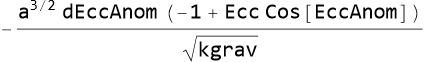

In [48]:
Simplify[TrigReduce[x], Assumptions-> {Sin[EccAnom]>0, Ecc>0}]

This result, along with the LHS of Eq. (1), yields:

$$
{\mathrm{d}}t = {a^{3/2}\over\sqrt{k_{\mathrm{grav}}}} (1 - e \cos E)\, {\mathrm{d}}E\, . 
$$

We shall integrate this now elementary expression between the time of passage at periapsis $t_p$ and the final time, $t$: 

$$
\int_{t_p}^t {\mathrm{d}}t' = t - t_p = {a^{3/2}\over\sqrt{k_{\mathrm{grav}}}} \int_0^E (1 - e \cos E') = {a^{3/2}\over\sqrt{k_{\mathrm{grav}}}}  \, (E - e \sin E)\, .\tag{3}
$$

The final step is to recognize, from Kepler's 3rd law, that:

$$
T = 2\pi  {a^{3/2}\over\sqrt{k_{\mathrm{grav}}}}\, .
$$

is the period of revolution. In analogy with the harmonic oscillator solution, we can write:

$$
T = {2\pi\over\omega} \implies \omega = {2\pi\over T} = \Bigl({a^{3/2}\over\sqrt{k_{\mathrm{grav}}}}\Bigr)^{-1}
$$
so that Eq. (3) can be written as:

$$
\omega(t - t_p) = (E - e \sin E)\, .\tag{3}
$$

Traditionally, $\omega$, referred to as the *mean motion*, is indicated by the symbol $n$, and $\omega t$ (if we take $t_p=0$), referred to as the *mean anomaly*, is indicated by the symbol $M$ (again, this must not be confused with the mass). Therefore, you will often see Kepler's equation written like (Bate (1971), Eq. 4.2-6):

$$\boxed{
M = n(t - t_p) = (E - e \sin E)\, .}\tag{4}
$$

In general, to find the position of an object along its orbit at time $t$, one must first solve this equation for $E$. This yields $r$ from Eq. (2). 

The true anomaly, $\theta$ can be found by comparing the orbit equation with Eq. (2):

$$
r= {a(1-e^2)\over 1 + e \cos \theta}= a(1-e \cos E) \implies 1 + e \cos \theta = {1-e^2\over (1-e \cos E)}
$$

Let us again use Mathematica for a useful simplification after setting $y \equiv \cos\theta$:

Ecc - Cos[EccAnom]
---------------------
-1 + Ecc Cos[EccAnom]
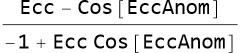

In [73]:
Simplify[Solve[1+ Ecc y == (1-Ecc^2)/(1-Ecc Cos[EccAnom]), y][[1,1,2]]]

That is:

$$\boxed{
\cos\theta = {\cos E - e\over 1 - e \cos E}\, .}\tag{5}
$$

A different form of the relationship between $E$ and $\theta$ can be found by trigonometric manipulation. First, subtract the above solution from 1:

Ecc - Cos[EccAnom]
1 - ---------------------
    -1 + Ecc Cos[EccAnom]
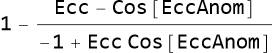

In [82]:
1 - Simplify[Solve[1+ Ecc y == (1-Ecc^2)/(1-Ecc Cos[EccAnom]), y][[1,1,2]]]

The add the same above solution to 1: 

Ecc - Cos[EccAnom]
1 + ---------------------
    -1 + Ecc Cos[EccAnom]
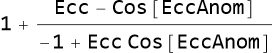

In [87]:
1 + Simplify[Solve[1+ Ecc y == (1-Ecc^2)/(1-Ecc Cos[EccAnom]), y][[1,1,2]]]

Now take the ratio of the two results and simplify:

EccAnom 2
(1 + Ecc) Tan[-------]
                 2
-----------------------
       -1 + Ecc
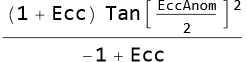

In [92]:
Simplify[TrigReduce[((-1 + Simplify[Solve[1+ Ecc y == (1-Ecc^2)/(1-Ecc Cos[EccAnom]), y][[1,1,2]]])/
(+1 + Simplify[Solve[1+ Ecc y == (1-Ecc^2)/(1-Ecc Cos[EccAnom]), y][[1,1,2]]]))]]

Similarly, by using the LHS of Eq. (5), we have:

Theta 2
Tan[-----]
      2
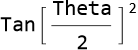

In [97]:
Simplify[TrigReduce[(1-Cos[Theta])/(1+Cos[Theta])]]

Therefore, by taking the square root of both sides of the equation, choosing the negative sign of the square root at RHS, we obtain:

$$\boxed{
\tan {\theta\over 2} =\sqrt{1+e\over 1- e}\tan {E\over 2}\, .}\tag{6}
$$

The work flow will therefore be:

$$
\boxed{{\mathrm{Choose}}\,\,\, t}\rightarrow \boxed{M = n(t - t_p)}\rightarrow \boxed{{\mathrm{Solve}}\,\,\,
M = n(t - t_p) = (E - e \sin E)} \rightarrow {\boxed{{\mathrm{Obtain\, both}}\,\,\,
r = a(1-e \cos E)}}{\mathrm{\, and}}\,\,\, 
\boxed{
\tan {\theta\over 2} =\sqrt{1+e\over 1- e}\tan {E\over 2}}  
$$

Obviously, if you want to solve the inverse problem of finding the time at which the object goes through give coordinates ($r$, $\theta$), you will have to calculate $E$, obtain $M$, and, from knowledge of $n$, readily find $(t - t_p)$.

## <a class="anchor" id="3._Application_of_Keplers_equation"></a> 3. Application of Kepler's equation: UM5-EOSat

[Back to Table of Contents](#Table_of_Contents)

In this Section, we apply Kepler's equation to determine the position of a spacecraft along its orbit. First read through the following Exercise till you understand all your goals. 

### <a class="anchor" id="3.1_Analytical_solution"></a> 3.1 Exercise: Analytical Solution

[Back to Table of Contents](#Table_of_Contents) 

*By using the data available from the current Two-Line Element file (TLE), determine the radius vector and the true anomaly of the satellite UM5-EOSat 60555 at a time equal to the time below following passage through periapsis.*

{Name -> {UM5-EOSAT               }, SatelliteID -> {60555}, Classification -> {U}, 
 
>   InternationalDesignator -> {24149CR}, LaunchYear -> {2024}, 
 
>   EpochDate -> {DateObject[{2025, 12, 20, 3, 59, 47}, Instant, Gregorian, 3.]}, 
 
>   MeanMotionChangeRate -> {0.00003432 revolutions per day squared}, 
 
>   BStar -> {28.039 reciprocal Earth equatorial radii}, EphemerisType -> {SGP4/SDP4}, 
 
>   ElementNumber -> {999}, Inclination -> {97.7043 degrees}, 
 
>   AscendingNodeRightAscension -> {69.8943 degrees}, Eccentricity -> {0.0007172}, 
 
>   ArgumentPeriapsis -> {357.861 degrees}, MeanAnomaly -> {2.2577 degrees}, 
 
>   MeanMotion -> {15.0004 revolutions per day}, RevolutionNumber -> {7336 revolutions}}
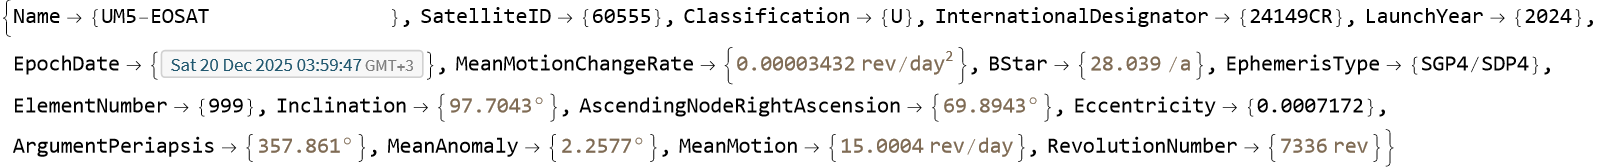

In [122]:
UM5EOSAT60555TLE = Import["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/60555.tle"]

Let us use the Mean Motion to recover the eccentricity and semimajor axis; the latter is obtained from the mean motion by first converting that from revolutions/day to radians/s:

In [127]:
UM5EOSAT60555TLEEcc = UM5EOSAT60555TLE[[13,2,1]]
UM5EOSAT60555TLEMeanMotion = (UM5EOSAT60555TLE[[16,2,1,1]]) (2 Pi / SiderealDay)

0.0007172
0.00109385

We have already seen that:

$$
n = {\sqrt{k_{\mathrm{grav}}}\over a^{3/2}} \implies a = \Bigl({\sqrt{k_{\mathrm{grav}}}\over n}\Bigr)^{2/3}
$$

In [133]:
UM5EOSAT60555TLESemiMajor = ((Sqrt[kEarth]/(UM5EOSAT60555TLEMeanMotion))^(2/3)) 
NumberForm[UM5EOSAT60555TLESemiMajor, 16]

6
6.93226 10
                      6
6.932261044771762 × 10

The periapsis and apoapsis are, therefore:

In [139]:
UM5EOSAT60555TLErp = UM5EOSAT60555TLESemiMajor (1 - UM5EOSAT60555TLEEcc)

UM5EOSAT60555TLEra = UM5EOSAT60555TLESemiMajor (1 + UM5EOSAT60555TLEEcc) 

6
6.92729 10
          6
6.93723 10

Although this is not strictly necessary to solve Kepler's equation, it is useful to obtain the periapsis and apoapsis altitude: 

In [145]:
UM5EOSAT60555TLEHp = UM5EOSAT60555TLErp - RadiusEarth 

UM5EOSAT60555TLEHa = UM5EOSAT60555TLEra - RadiusEarth 

556289.
566233.

In what follows, in order to retain the flexibility to arbitrarily assign periapsis and apoapsis, we shall define the semimajor axis and the eccentricity, which will of course lead us back to the quantities from the TLE:    

In [151]:
SemiMajor[ra_,rp_] =(1/2)(ra+rp);
Eccentricity[ra_,rp_]=(ra-rp)/(ra+rp);

In [153]:
SemiMajor[RadiusEarth + UM5EOSAT60555TLEHa, RadiusEarth + UM5EOSAT60555TLEHp]
Eccentricity[RadiusEarth + UM5EOSAT60555TLEHa, RadiusEarth + UM5EOSAT60555TLEHp] 

6
6.93226 10
0.0007172

7               -3
5.64695 10  Sqrt[(ra + rp)  ]
            -7
  1.11267 10
-----------------
              -3
Sqrt[(ra + rp)  ]
0.00109385
5744.12
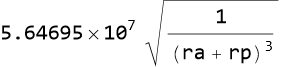
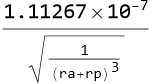

In [155]:
MeanMotion[rp_,ra_] = Sqrt[kEarth/((SemiMajor[ra,rp])^3)] 
PeriodSat[rp_,ra_] = 2 Pi/MeanMotion[rp,ra]

MeanMotion[RadiusEarth + UM5EOSAT60555TLEHa, RadiusEarth + UM5EOSAT60555TLEHp]
PeriodSat[RadiusEarth + UM5EOSAT60555TLEHa, RadiusEarth + UM5EOSAT60555TLEHp] 

**Generate a random time along the orbit**. Return to this point and use the random number you obtained as your value for $t-t_p$. In order to introduce an element of unpredictability, extract a random time by replacing the figures 12345 by the last $5$ digits of your cell phone number in `SeedRandom` below:

In this example (with `SeedRandom` set as $12345$), we shall use: 

In [163]:
(* This is your time following the epoch date of the TLE, in seconds *)

SeedRandom[71789]; TimeFinalTest =  RandomReal[{PeriodSat[RadiusEarth + UM5EOSAT60555TLEHa, RadiusEarth + UM5EOSAT60555TLEHp]}]

2010.34

It may be helpful to display this and the period of revolution in hh:mm:ss. as well:

In [169]:
UnitConvert[Quantity[PeriodSat[RadiusEarth + UM5EOSAT60555TLEHa, RadiusEarth + UM5EOSAT60555TLEHp], "Seconds"], MixedRadix["Hours", "Minutes", "Seconds"]]
UnitConvert[Quantity[TimeFinalTest, "Seconds"], MixedRadix["Hours", "Minutes", "Seconds"]]

1 hour 35 minutes 44.1179 seconds
0 hours 33 minutes 30.335 seconds

7               -3
5.64695 10  Sqrt[(ra + rp)  ] TimeFinal
2.199
125.993
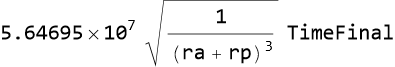

In [171]:
MeanAnomaly[rp_,ra_,TimeFinal_] = MeanMotion[rp,ra] TimeFinal 
MeanAnomaly[RadiusEarth + UM5EOSAT60555TLEHa, RadiusEarth + UM5EOSAT60555TLEHp,TimeFinalTest]
(*in degrees*)
MeanAnomaly[RadiusEarth + UM5EOSAT60555TLEHa, RadiusEarth + UM5EOSAT60555TLEHp,TimeFinalTest] (180/Pi)

Importantly, since the epoch date, $t_{\mathrm{epoch}}$, of the TLE is not that of passage through periapsis, we must first  solve Kepler's equation for the $M_0$ provided by the TLE, so as to establish the true anomaly at epoch, $\theta_{\mathrm{epoch}}$. For this purpose, we plot the value of $M_0$ (red) and of the RHS of Kepler's equation (black):

In [179]:
UM5EOSAT60555TLEMeanAnomaly = UM5EOSAT60555TLE[[15,2,1,1]] 
(* Convert to radians *)
UM5EOSAT60555TLEMeanAnomaly = UM5EOSAT60555TLE[[15,2,1,1]] Degree

2.2577
0.0394043

-Graphics-
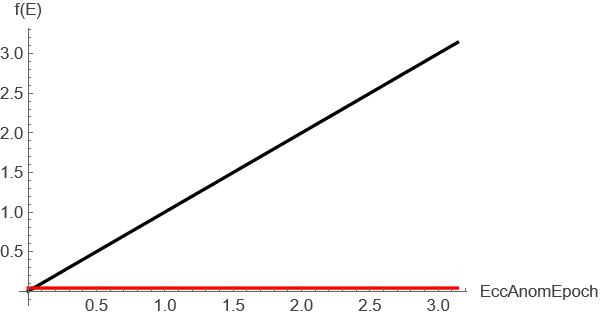

In [182]:
PLOT1Epoch = Plot[EccAnomEpoch - UM5EOSAT60555TLEEcc Sin[EccAnomEpoch], {EccAnomEpoch , 0, Pi}, AxesLabel->{"EccAnomEpoch","f(E)"}, PlotStyle->Black];
PLOT2Epoch = Plot[UM5EOSAT60555TLEMeanAnomaly, {EccAnomEpoch, 0, Pi}, PlotStyle->{Red,Thick}];
PLOTALLEpoch = Show[PLOT1Epoch,PLOT2Epoch]

We can ask Mathematica to solve Kepler's equation by using the `FindRoot` command (see Additional Readings for details):

In [189]:
EccAnomEpochTest = FindRoot[UM5EOSAT60555TLEMeanAnomaly == EccAnomEpoch - UM5EOSAT60555TLEEcc Sin[EccAnomEpoch],{EccAnomEpoch,2.0}][[1,2]] 
EccAnomEpochTest (180/Pi)

0.0394326
2.25932

 We are now ready to compute the initial radial coordinate of UM5EOSat 60555:

(ra - rp) Cos[EccAnom]
(ra + rp) (1 - ----------------------)
                      ra + rp
--------------------------------------
                  2
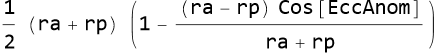

In [195]:
rSol[ra_,rp_,EccAnom_] = SemiMajor[ra,rp] (1 - Eccentricity[ra,rp] Cos[EccAnom])

The instruction `NumberForm` displays an arbitrary number of figures: 

In [200]:
rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp,EccAnomEpochTest]
NumberForm[rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp,EccAnomEpochTest],12]

6
6.92729 10
                  6
6.92729309206 × 10

The true anomaly of UM5EOSat 60555 at the epoch date is: 

ra - rp
              1 + -------
                  ra + rp      EccAnom
2 ArcTan[Sqrt[-----------] Tan[-------]]
                  ra - rp         2
              1 - -------
                  ra + rp
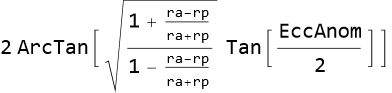

In [206]:
ThetaSol[ra_,rp_,EccAnom_]  = 2 ArcTan[Sqrt[(1+Eccentricity[ra,rp])/(1-Eccentricity[ra,rp])] Tan[EccAnom/2]]

In [207]:
ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest]
NumberForm[ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest],12]
ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest] (180/Pi)

0.0394609
0.039460856085
2.26094

We can double check his result by means of the equation:

$$
\cos\theta = {\cos E - e\over 1 - e \cos E}\, .
$$

ra - rp
       -(-------) + Cos[EccAnom]
         ra + rp
ArcCos[--------------------------]
           (ra - rp) Cos[EccAnom]
       1 - ----------------------
                  ra + rp
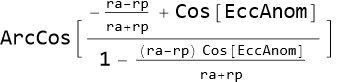

In [214]:
ThetaSol2[ra_,rp_,EccAnom_]  = ArcCos[(Cos[EccAnom] - Eccentricity[ra,rp]) / (1 - Eccentricity[ra,rp] Cos[EccAnom])]


In [215]:
ThetaSol2[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp,EccAnomEpochTest]

0.0394609

We can draw the orbit by calculating the semilatus rectum and by using the analytical solution:

2
               (ra - rp)
(ra + rp) (1 - ----------)
                        2
               (ra + rp)
--------------------------
            2
                         2
                (ra - rp)
 (ra + rp) (1 - ----------)
                         2
                (ra + rp)
----------------------------
       (ra - rp) Cos[Theta]
2 (1 + --------------------)
             ra + rp
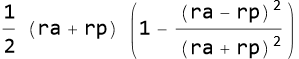
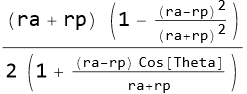

In [220]:
SemiLatus[ra_,rp_] =SemiMajor[ra,rp](1-(Eccentricity[ra,rp])^2)
rAnalyt[ra_,rp_,Theta_] = SemiLatus[ra,rp]/(1 + Eccentricity[ra,rp]Cos[Theta])

In [222]:
rAnalyt[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest]]

6
6.92729 10

-Graphics-
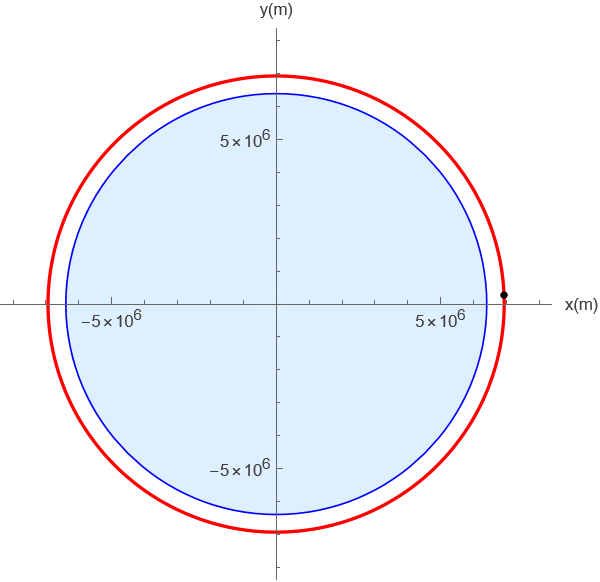

In [223]:
PLOTEarthEdge = Graphics[{Blue,Thick,Circle[{0,0},RadiusEarth]} ,Axes->True];
PLOTEarthDisk = Graphics[{LightBlue,Disk[{0,0},RadiusEarth]} ];
PLOTEarth = Show[PLOTEarthEdge,PLOTEarthDisk];

PLOTUM5EOSAT = PolarPlot[rAnalyt[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, Theta],{Theta,0,2 Pi},PlotRange->{{-RadiusEarth - 2000. 10^3,RadiusEarth + 2000. 10^3},{-RadiusEarth - 2000. 10^3,RadiusEarth + 2000. 10^3}},PlotStyle->{Red,Thick}];
PLOTUM5EOSATEpoch = ListPolarPlot[{{ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest],rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp,EccAnomEpochTest]}},PlotRange->{{-RadiusEarth - 2000. 10^3,RadiusEarth + 2000. 10^3},{-RadiusEarth - 2000. 10^3,RadiusEarth + 2000. 10^3}},PlotStyle->Black];
PLOTUM5EOSATEpochVector = ListPolarPlot[{{0,0},{ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest], rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLERp, EccAnomEpochTest]}},PlotRange->{{-RadiusEarth - 2000. 10^3,RadiusEarth + 2000. 10^3},{-RadiusEarth - 2000. 10^3,RadiusEarth + 2000. 10^3}},PlotMarkers->None,Joined->True,PlotStyle->Black];
PLOTUM5EOSATEpochAll = Show[PLOTUM5EOSAT,PLOTEarth,PLOTUM5EOSATEpoch,PLOTUM5EOSATEpochVector, AxesLabel->{"x(m)","y(m)"}]


We must now notice that since the treatment of Kepler's equation developed in [Sec. 2](#2._Kepler_equation) applies to the case in which $t_{\mathrm{epoch}} = t_p$, we must generalize Kepler's equation to the case in which $t_{\mathrm{epoch}}\neq t_p$. 

As illustrated in Fig. 4.2-4 of Bate et al. (1971), if the spacecraft does *not* go through periapsis in the time between $t$ and  $t_{\mathrm{epoch}}$, Kepler's equation must be rewritten as:

$$
n (t - t_{\mathrm{epoch}}) = (E - e \sin E) - M_0\, ,
$$

where $M_0 = E_0 -e\sin E_0$ is the mean anomaly at the epoch date, $M(t_{\mathrm{epoch}})$. On the other hand, if if the spacecraft does go through periapsis $k$ times in the time between $t$ and  $t_{\mathrm{epoch}}$, Kepler's equation must be rewritten as:

$$
n (t - t_{\mathrm{epoch}}) = 2k\pi + (E - e \sin E) - M_0\, .
$$ 

In the case of this Exercise, the time interval is randomly generated with the condition that $t- t_{\mathrm{epoch}} \leq T$. Therefore, the only two possibilities are $k= 0, 1$. In order to establish whether $k= 0$ or $k= 1$, we can check the sign of the solution of Kepler's equation. If the sign is negative, the spacecraft will go through periapsis and we must add $2\pi$ before solving Kepler's equation; if not, we can proceed as seen in [Sec. 2](#2._Kepler_equation). 

For the randomly extracted time interval, we find, for $n (t - t_{\mathrm{epoch}})$: 

In [234]:
(TimeFinalTest UM5EOSAT60555TLEMeanMotion) + UM5EOSAT60555TLEMeanAnomaly 

2.2384

-Graphics-
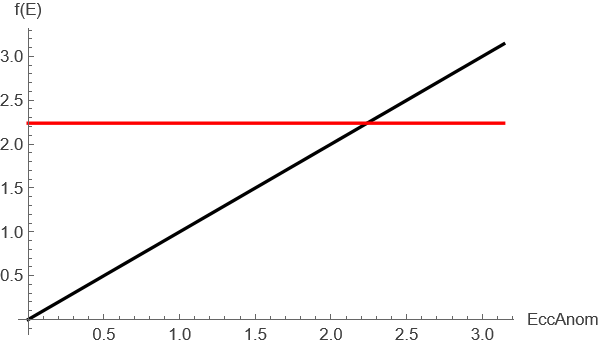

In [235]:
PLOT1 = Plot[EccAnom - UM5EOSAT60555TLEEcc Sin[EccAnom], {EccAnom , 0, Pi}, AxesLabel->{"EccAnom","f(E)"}, PlotStyle->Black];
PLOT2  = Plot[(TimeFinalTest UM5EOSAT60555TLEMeanMotion) + UM5EOSAT60555TLEMeanAnomaly , {EccAnom, 0, Pi}, PlotStyle->Red];
PLOTALL= Show[PLOT1,PLOT2]

We can ask Mathematica to solve Kepler's equation by using the `FindRoot` command (see Additional Readings for details):

In [242]:
EccAnomTest=FindRoot[(TimeFinalTest UM5EOSAT60555TLEMeanMotion) + UM5EOSAT60555TLEMeanAnomaly  == EccAnom - UM5EOSAT60555TLEEcc Sin[EccAnom], {EccAnom,1.4}][[1,2]]

2.23897

We are now ready to compute the radial coordinatE:

The instruction `NumberForm` displays an arbitrary number of figures: 

In [251]:
rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomTest]
NumberForm[rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomTest],12]

6
6.93534 10
                  6
6.93534133554 × 10

The true anomaly is: 

In [257]:
ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomTest]
NumberForm[ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomTest],12]

2.23953
2.23952876403

We can now draw the position of UM5-EOSat at the required time, $t$, shown below as a dashed vector:

-Graphics-
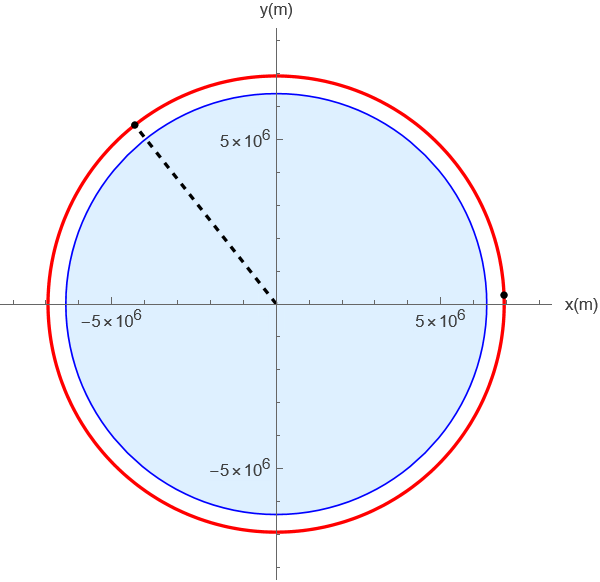

In [263]:
PLOTUM5EOSATTest = ListPolarPlot[{{ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomTest], rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomTest]}}, PlotRange->{{-RadiusEarth - 50000. 10^3, RadiusEarth + 50000. 10^3},{-RadiusEarth - 50000. 10^3, RadiusEarth + 50000. 10^3}}, PlotStyle->Black];
PLOTUM5EOSATTestVector = ListPolarPlot[{{0,0},{ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomTest],rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomTest]}}, PlotRange->{{-RadiusEarth - 50000. 10^3, RadiusEarth + 50000. 10^3},{-RadiusEarth - 50000. 10^3, RadiusEarth + 50000. 10^3}}, PlotMarkers->None,Joined->True, PlotStyle->{Dashed, Black}];

PLOTUM5EOSATTest = Show[PLOTUM5EOSATTest, PLOTUM5EOSATTestVector];

PLOTUM5EOSATAll = Show[PLOTUM5EOSATEpochAll, PLOTUM5EOSATTest]

### <a class="anchor" id="3.2_Numerical_solution"></a> 3.2 Exercise: Numerical Solution

[Back to Table of Contents](#Table_of_Contents) 

Here we analyze the same problem by means of an entirely numerical approach based on the same syntax you used for Project-1. Once again, we assume a Newtonian $2$-body problem with a spherically symmetrical Earth and no other perturbations.  

Since we derive our known quantities and initial conditions from previous calculations, and because the geometry of this case is slightly different, there are some modifications with respect to the code used in Project 1.  

As usual, the specific angular momentum is:

In [271]:
SpecAngMomenIn [ra_,rp_]= Sqrt[kEarth SemiMajor[ra,rp] (1-(Eccentricity[ra,rp])^2) ];

With the data available from the TLE, we find: 

In [276]:
SpecAngMomenIn[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp] 

10
5.25662 10

Unlike in Project 1, however, the initial velocity is not perpendicular to the radius vector at peri- or apoapsis. Let us first find the tangential velocity, needed to calculate the radial velocity:  

2
          7                     (ra - rp)
2.82347 10  Sqrt[(ra + rp) (1 - ----------)]
                                         2
                                (ra + rp)
--------------------------------------------
                  (ra - rp) Cos[EccAnom]
   (ra + rp) (1 - ----------------------)
                         ra + rp
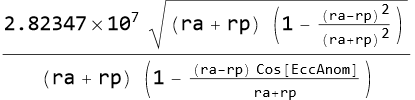

In [281]:
vt0In[ra_, rp_, EccAnom_] =(SpecAngMomenIn [ra,rp])/rSol[ra, rp, EccAnom]

In [282]:
vt0In[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest]

7588.27

The radial component of the velocity can now be found from the energy: 

$$
\cal E = \textstyle{1\over 2} (\dot{r}_0^2 + v_{t, 0}^2) - \displaystyle{k_\oplus\over  r} =  - \displaystyle{k_\oplus\over 2 a}
$$

$$
\dot{r} = \pm \sqrt{2 \Bigl[\Bigl(\displaystyle{k_\oplus\over  r} - \displaystyle{k_\oplus\over 2 a}\Bigr) - \textstyle{1\over 2}v_{t, 0}^2\Bigr]} = \pm \sqrt{2 \Bigl[\Bigl(\displaystyle{k_\oplus\over  r} +\cal E\Bigr) - \textstyle{1\over 2}v_{t, 0}^2\Bigr]}  \, .
$$


In [287]:
SpecEnergy [ra_, rp_] = - kEarth / (2 SemiMajor[ra,rp]);

SpecEnergy [UM5EOSAT60555TLEra, UM5EOSAT60555TLErp]  

7
-2.87497 10

The sign choice can be made by considering whether the spacecraft is moving from apoapsis to periapsis, or viceversa. As we can see from the plots above, in this case we are moving towards apoapsis and, therefore, $\dot{r} >0$:

2
                                         14      (ra - rp)
                                 3.986 10   (1 - ----------)
                      14                                  2
             -3.986 10                           (ra + rp)
Sqrt[2] Sqrt[----------- - --------------------------------------- + 
               ra + rp                    (ra - rp) Cos[EccAnom] 2
                           (ra + rp) (1 - ----------------------)
                                                 ra + rp
 
                             14
                   7.97201 10
>     --------------------------------------]
                     (ra - rp) Cos[EccAnom]
      (ra + rp) (1 - ----------------------)
                            ra + rp
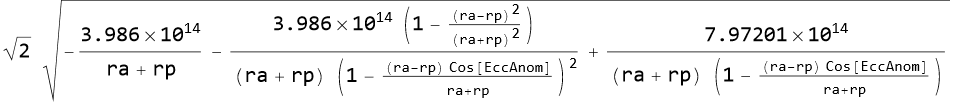

In [293]:
rdotEpoch [ra_, rp_, EccAnom_] = Sqrt[2 (((kEarth/rSol[ra, rp, EccAnom]) + SpecEnergy [ra, rp]) - ((1/2)(vt0In[ra, rp, EccAnom])^2))]

In [294]:
rdotEpoch [UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest]

0.214549

Let us verify that the total energy is equal to the value computed above:

In [299]:
(1/2)((rdotEpoch [UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest])^2 + (vt0In[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest])^2) - (kEarth/rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp,EccAnomEpochTest])

7
-2.87497 10

Let us set the initial radial coordinate as the value obtained from the TLE data:

In [304]:
r0 = rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp,EccAnomEpochTest]

6
6.92729 10

We set the final time of the integration as the time for which we solved Kepler's equation: 

In [309]:
tfin = TimeFinalTest

2010.34

We are now ready to numerically solve the equation of motion for the radial coordinate:

{3.32813, {{r -> InterpolatingFunction[{{0., 2010.34}}, <>]}}}
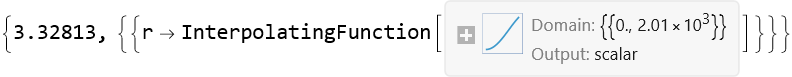

In [314]:
Clear[SolKeplerRad,r]

Timing[SolKeplerRad =NDSolve[{r''[t] == (SpecAngMomenIn[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp])^2 (1/(r[t])^3) - (kEarth/(r[t])^2) ,r[0]==r0,r'[0]==rdotEpoch [UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest]},r,{t,0,tfin},AccuracyGoal->16,PrecisionGoal->16,MaxSteps-> ∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

Now we can extract the needed information as usual (notice that we added a *Num* extension to the variable name to differentiate it from the name of the analytical variable above: 

In [320]:
rSolNum[t_] = Evaluate[r[t] /. SolKeplerRad][[1]];

rDotSolNum[t_] = Evaluate[r'[t] /. SolKeplerRad][[1]];

ThetaAngDotNum[t_] = (lSpecAngMom[r0,vt0])(1/(rSolNum[t])^2);
vtSolNum[t_] = ThetaAngDot[t]rSolNum[t]; 

VSolNum[t_] = Sqrt[((vtSolNum[t])^2)+((rDotSolNum[t])^2)];

The radial component of the position (i.e. the magnitude of the radius vector) is:

In [329]:
rSolNum[tfin]

6
6.93534 10

Let us now consider the equation of motion for the angular coordinate (see Kittel (1973), p. 281). In order to proceed, we need one initial condition:

In [334]:
ThetaAng0 = ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest] 

0.0394609

{{ThetaAng -> InterpolatingFunction[{{0., 2010.34}}, <>]}}
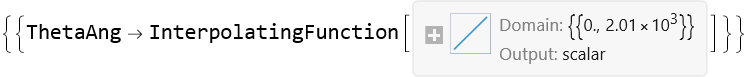

In [335]:
Clear[SolKeplerAng]

SolKeplerAng =NDSolve[{ThetaAng'[t] == (SpecAngMomenIn[UM5EOSAT60555TLEra,UM5EOSAT60555TLErp])(1/(rSolNum[t])^2) ,ThetaAng[0]==ThetaAng0},ThetaAng,{t,0,tfin},AccuracyGoal->15,PrecisionGoal->15,MaxSteps->∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]

InterpolatingFunction[{{0., 2010.34}}, <>][t]
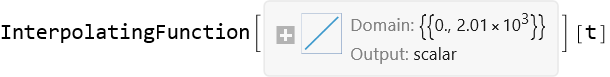

In [337]:
ThetaAngSolNum[t_] = Evaluate[ThetaAng[t] /. SolKeplerAng][[1]]

The angular component of the position (the polar coordinate of the radius vector), and its relative error, at the requested time are:

In [342]:
ThetaAngSolNum[tfin]

2.23953

### <a class="anchor" id="3.2.1_Error_Analysis"></a> 3.2.1 Error Analysis 

[Back to Table of Contents](#Table_of_Contents)  

Let us first carry out a visual comparison of the analytical and numerical trajectories:

Cos[InterpolatingFunction[{{0., 2010.34}}, <>][t]] 
 
>   InterpolatingFunction[{{0., 2010.34}}, <>][t]
Sin[InterpolatingFunction[{{0., 2010.34}}, <>][t]] 
 
>   InterpolatingFunction[{{0., 2010.34}}, <>][t]
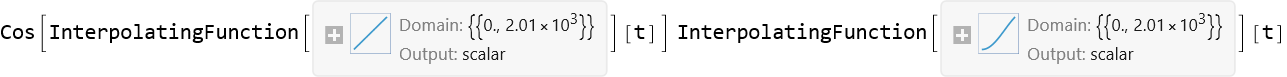
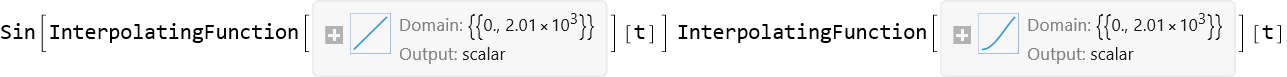

In [351]:
xSolNum[t_] = rSolNum[t] Cos[ThetaAngSolNum[t]]
ySolNum[t_] = rSolNum[t] Sin[ThetaAngSolNum[t]]

In [353]:
PLOTxSolNum = Plot[xSolNum[t],{t,0, tfin},PlotRange->All,PlotRange->All];
PLOTySolNum = Plot[ySolNum[t],{t,0, tfin},PlotRange->All,PlotRange->All];

-Graphics-
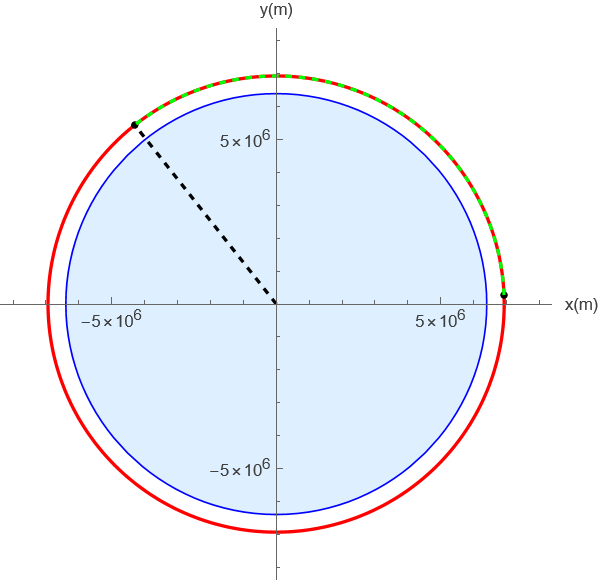

In [355]:
PLOTUM5EOSATTraj = ParametricPlot[{xSolNum[t], ySolNum[t]}, {t, 0, tfin}, Axes->True, AxesLabel->{x,y}, 
PlotStyle->{Dashed, Thick, Green}, 
PlotRange -> {{-RadiusEarth - 5000. 10^3, RadiusEarth + 5000. 10^3},{-RadiusEarth - 5000. 10^3, RadiusEarth + 5000. 10^3}}];

PlotUM5EOSATNumAll = Show[PLOTUM5EOSATAll, PLOTUM5EOSATTraj] 

Finally, let us analyze both the absolute and relative discrepancies in the radial and polar coordinates obtained from the analytical and numerical methods.

The discrepancies are defined as follows:

**Absolute radial error**
$$
\Delta r(t)=\big|r_{\mathrm{num}}(t)-r_{\mathrm{anal}}(t)\big|
$$

**Relative radial error**
$$
\varepsilon_r(t)=\frac{|r_{\mathrm{num}}(t)-r_{\mathrm{anal}}(t)|}{r_{\mathrm{anal}}(t)}
$$

**Absolute angular error**
$$
\Delta\theta(t)=\big|\theta_{\mathrm{num}}(t)-\theta_{\mathrm{anal}}(t)\big|
$$

**Relative angular error**
$$
\varepsilon_\theta(t)=\frac{|\theta_{\mathrm{num}}(t)-\theta_{\mathrm{anal}}(t)|}{|\theta_{\mathrm{anal}}(t)|}
$$

In [361]:
(* Analytical polar solution at time t *)
rAnal[t_] = rAnalyt[ UM5EOSAT60555TLEra, UM5EOSAT60555TLErp,ThetaAngSolNum[t]];

thetaAnal[t_] = ThetaSol[UM5EOSAT60555TLEra,UM5EOSAT60555TLErp, EccAnomTest];

(* Absolute radial error *)
AbsRadialError[t_] = Abs[rSolNum[t] - rAnal[t]];

(* Relative radial error *)
RelRadialError[t_] = AbsRadialError[t]/rAnal[t];

(* Absolute angular error *)
AbsAngularError[t_] = Abs[ThetaAngSolNum[t] - thetaAnal[t]];

(* Relative angular error *)
RelAngularError[t_] = AbsAngularError[t]/Abs[thetaAnal[t]];

-Graphics-
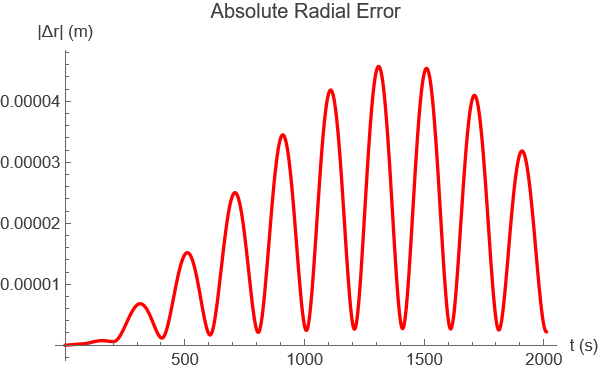

In [372]:
PLOTAbsRadialError =Plot[AbsRadialError[t],{t, 0, tfin},PlotStyle -> {Red, Thick},AxesLabel -> {"t (s)", "|Δr| (m)"},PlotLabel -> "Absolute Radial Error"]

-Graphics-
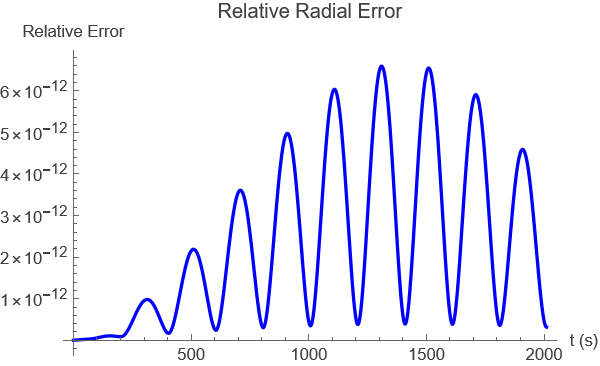

In [373]:
PLOTRelRadialError =Plot[RelRadialError[t],{t, 0, tfin},PlotStyle -> {Blue, Thick},AxesLabel -> {"t (s)", "Relative Error"},PlotLabel -> "Relative Radial Error"]

-Graphics-
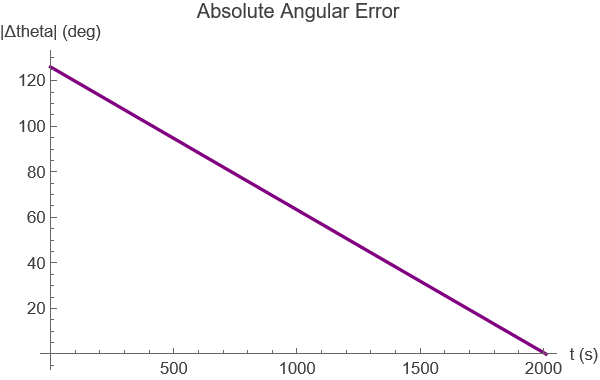

In [374]:
PLOTAbsAngularError =Plot[AbsAngularError[t]/Degree,{t, 0, tfin},PlotStyle -> {Purple, Thick},AxesLabel -> {"t (s)", "|Δtheta| (deg)"},PlotLabel -> "Absolute Angular Error"]

-Graphics-
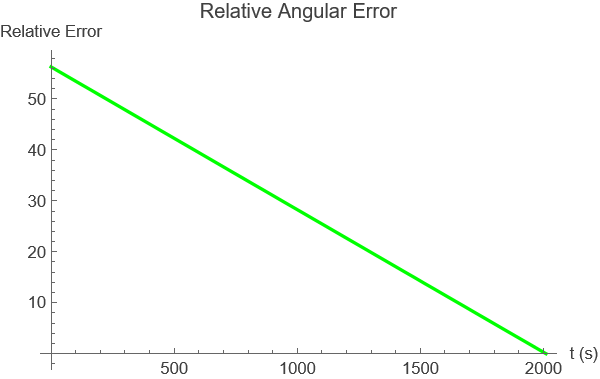

In [375]:
PLOTRelAngularError =Plot[RelAngularError[t]/Degree,{t, 0, tfin}, PlotStyle -> {Green, Thick}, AxesLabel -> {"t (s)", "Relative Error"},PlotLabel -> "Relative Angular Error"]

In [376]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-1a-errors.svg", PLOTAbsRadialError] 
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-1b-errors.svg", PLOTRelRadialError] 
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-1c-errors.svg", PLOTAbsAngularError] 
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-1d-errors.svg", PLOTRelAngularError] 

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-1a-\
 
>   errors.svg
C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-1b-\
 
>   errors.svg
C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-1c-\
 
>   errors.svg
C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-1d-\
 
>   errors.svg

### Discussion

The absolute radial discrepancy remains bounded and small throughout the
propagation interval, confirming the consistency between the analytical Kepler
solution and the numerical two–body integration.

The relative radial error stays several orders of magnitude below unity, indicating
that the observed discrepancies are dominated by numerical integration errors rather
than modeling inconsistencies.

The angular discrepancies grow slightly with time, which is expected since angular
errors accumulate more rapidly than radial errors in orbital motion.

Overall, the excellent agreement between the analytical and numerical solutions
validates:
- the correct implementation of Kepler’s equation,
- the consistency of the extracted TLE parameters,
- the accuracy of the numerical integrator for the selected tolerance levels.

These results justify the use of the analytical Kepler solution for short–term
propagation around the TLE epoch, while numerical integration remains necessary for
long–term or perturbed motion.


### 3.2.2 Dependence of the Discrepancies on Numerical Accuracy Parameters

In this section, the sensitivity of the analytical–numerical discrepancies to the
numerical tolerance parameters is investigated.

Two numerical steps are involved in the solution:
1. The numerical integration of the two–body equations using `NDSolve`
2. The numerical solution of Kepler’s equation using `FindRoot`

Both procedures depend on the parameters:
- `AccuracyGoal -> x`
- `PrecisionGoal -> x`

The value of $x$ is varied over integer values smaller than or equal to 16, and the
resulting discrepancies are analyzed.


NDSolve::ndtol: Tolerances requested by the AccuracyGoal and PrecisionGoal options could not be achieved at t == 0..

NDSolve::ndtol: Tolerances requested by the AccuracyGoal and PrecisionGoal options could not be achieved at t == 0..

NDSolve::ndtol: Tolerances requested by the AccuracyGoal and PrecisionGoal options could not be achieved at t == 0..

General::stop: Further output of NDSolve::ndtol will be suppressed during this calculation.

Accuracy   Max |Δr| (m)

2          37.928

3          1.95014

4          2.11882

5          0.243346

6          0.0254353

7          0.00301384

8          0.000672847

9          0.000152437

10         0.0000432413

11         0.0000457009

12         0.000045713

13         0.0000456581

                     -10
14         9.31323 10

                     -10
15         9.31323 10

                     -10
16         9.31323 10
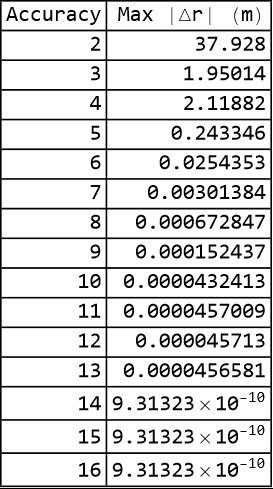

In [388]:
Clear[SolveRadialBase, RadialErrorMax]

SolveRadialBase[ag_?NumericQ, pg_?NumericQ] :=
 Module[{sol, rFun, tmin, tmax},
    sol = NDSolve[{r''[t] == (SpecAngMomenIn[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp])^2/r[t]^3 - kEarth/r[t]^2,
    r[0] == r0, r'[0] == rdotEpoch[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomEpochTest]},
    r, {t, 0, tfin},
    AccuracyGoal -> ag,
    PrecisionGoal -> pg][[1]];
  rFun = r /. sol;
  {tmin, tmax} = rFun["Domain"][[1]]; 
  {rFun, tmin, tmax}]

AccuracyList = Range[2, 16];

RadialErrorMax = Table[Module[{rFun, tmin, tmax, grid},
   {rFun, tmin, tmax} = SolveRadialBase[x, x];
   grid = Subdivide[tmin, tmax, 200];
   Max[Abs[rFun /@ grid - rAnal /@ grid]]],{x, AccuracyList}];

  
RadialErr= Grid[Prepend[Transpose[{AccuracyList, RadialErrorMax}], 
{"Accuracy", "Max |Δr| (m)"}],
Frame -> All, Alignment -> Right]

-Graphics-
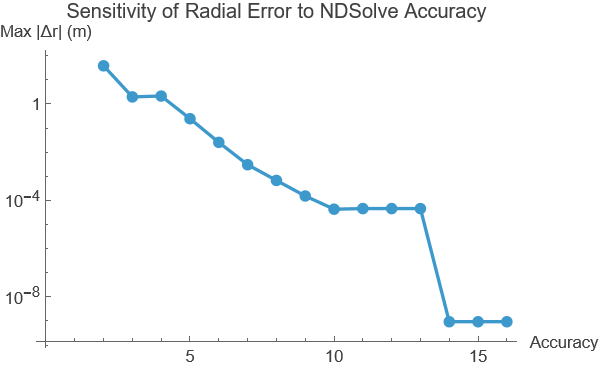

In [394]:
PLOTERRORACCURACY= ListLogPlot[Transpose[{AccuracyList, RadialErrorMax}], Joined -> True,
 PlotMarkers -> Automatic,
 AxesLabel -> {"Accuracy", "Max |Δr| (m)"},
 PlotLabel -> "Sensitivity of Radial Error to NDSolve Accuracy"]

In [395]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-2-Sensitivity-of-Radial-Error-to-NDSolve-Accuracy.svg", PLOTERRORACCURACY]
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-Sensitivity-of-Radial-Error.svg",RadiaErr]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-2-S\
 
>   ensitivity-of-Radial-Error-to-NDSolve-Accuracy.svg
C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-Sensiti\
 
>   vity-of-Radial-Error.svg

### Effect of `AccuracyGoal` and `PrecisionGoal` in `NDSolve`

As the accuracy parameters are increased, the maximum radial discrepancy decreases
monotonically.

For low values of $x$, the numerical truncation error dominates and the discrepancy
grows rapidly. Beyond $x \approx 13$, further improvement becomes marginal, indicating
that other sources of error (finite time step, Kepler solver accuracy) start to limit
the solution.

This behavior confirms that the numerical solution converges toward the analytical
Keplerian solution as expected for a well-posed two–body problem

*NB*: Reagarding the error in the output: Such warnings are common when solving orbital equations with inverse-power radial terms and do not invalidate the numerical results. It just means at the initial time step, the solver cannot satisfy the extremely tight (or inconsistent) accuracy and precision requirements given the numerical conditions.


Accuracy   |ΔE| (rad)

                                    -11
2          2.10890438541409457008 10

                    -27
3          6.2918 10

                    -27
4          6.2918 10

                    -27
5          6.2918 10

                    -27
6          6.2918 10

                    -27
7          6.2918 10

                    -27
8          6.2918 10

                    -27
9          6.2918 10

                    -27
10         6.2918 10

                -31
11         0. 10

                -31
12         0. 10

                -31
13         0. 10

                -31
14         0. 10

                -31
15         0. 10

                -31
16         0. 10
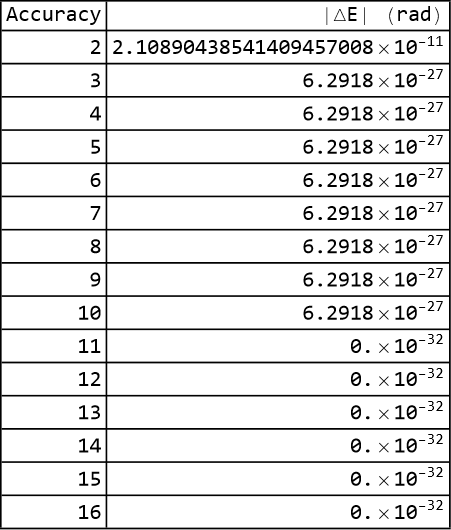

In [401]:
accuracyValues = Range[2, 16];

AccuracyListKepler = {};
KeplerError = {};
RadiusAbsError = {};
RadiusRelError = {};

Table[

  (* --- Kepler equation with reduced accuracy --- *)
EccAnomTestAcc = FindRoot[
  SetPrecision[UM5EOSAT60555TLEMeanAnomaly, 30] ==
    EccAnomEpoch - SetPrecision[UM5EOSAT60555TLEEcc, 30] Sin[EccAnomEpoch],
  {EccAnomEpoch, SetPrecision[2.0, 30]},
  WorkingPrecision -> 30,
  AccuracyGoal -> x,
  PrecisionGoal -> x
][[1, 2]];

EccAnomEpochTest = FindRoot[
  SetPrecision[UM5EOSAT60555TLEMeanAnomaly, 30] ==
    EccAnomEpoch - SetPrecision[UM5EOSAT60555TLEEcc, 30] Sin[EccAnomEpoch],
  {EccAnomEpoch, SetPrecision[2.0, 30]},
  WorkingPrecision -> 30,
  AccuracyGoal -> 16,
  PrecisionGoal -> 16
][[1, 2]];

  (* Store Kepler solver error *)
  AppendTo[AccuracyListKepler, x];
  AppendTo[KeplerError, Abs[EccAnomTestAcc - EccAnomEpochTest]];

  (* --- Numerical propagation with reduced accuracy --- *)
  solRadAcc = NDSolve[
    {
      r''[t] == (SpecAngMomenIn[SetPrecision[UM5EOSAT60555TLEra, 30], SetPrecision[UM5EOSAT60555TLErp, 30]])^2/r[t]^3 - kEarth/r[t]^2,
      r[0] == rSol[SetPrecision[UM5EOSAT60555TLEra, 30], SetPrecision[UM5EOSAT60555TLErp, 30], EccAnomTestAcc],
      r'[0] == rdotEpoch[SetPrecision[UM5EOSAT60555TLEra, 30], SetPrecision[UM5EOSAT60555TLErp, 30], EccAnomTestAcc]
    },
    r, {t, 0, tfin},
    AccuracyGoal -> x, PrecisionGoal -> x, MaxSteps -> ∞, Method -> {"StiffnessSwitching","NonstiffTest"->False}
  ];

  rNumAcc = (r[t] /. solRadAcc)[[1]][tfin];

  AppendTo[RadiusAbsError, Abs[rNumAcc - rAnalytical]];
  AppendTo[RadiusRelError, Abs[rNumAcc - rAnalytical]/rAnalytical];

, {x, accuracyValues}];
FindRootErr = Grid[Prepend[ Transpose[{AccuracyListKepler, KeplerError}], {"Accuracy", "|ΔE| (rad)"}],
  Frame -> All,
  Alignment -> Right]

-Graphics-
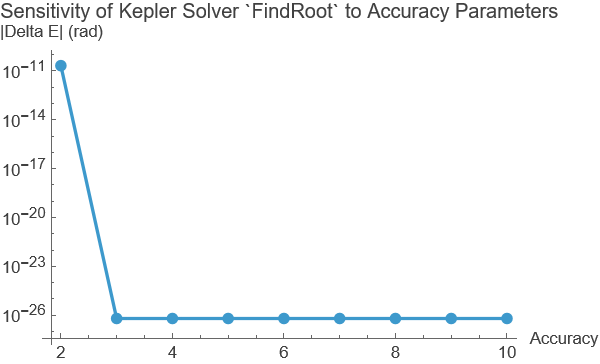

In [408]:
PLOTKEPLERERROR = ListLogPlot[Transpose[{AccuracyListKepler, KeplerError}],
  Joined -> True,
  PlotMarkers -> Automatic,
  AxesLabel -> {"Accuracy", "|Delta E| (rad)"},
  PlotLabel -> "Sensitivity of Kepler Solver `FindRoot` to Accuracy Parameters"]

In [409]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-2-Sensitivity-of-Kepler-Solver-to-Accuracy.svg", PLOTKEPLERERROR]
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-Sensitivity-of-Findroot-Error.svg",FindRootErr]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-2-S\
 
>   ensitivity-of-Kepler-Solver-to-Accuracy.svg
C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-Sensiti\
 
>   vity-of-Findroot-Error.svg

### Effect of Reducing Accuracy in `FindRoot`

When investigating the sensitivity of the Kepler equation solver to reduced values of `AccuracyGoal` and `PrecisionGoal`, the absolute discrepancy in the eccentric anomaly initially appeared to be identically zero for all tested accuracy values.

This behavior is not due to the numerical solutions being exactly identical, but rather a consequence of machine-precision arithmetic. The FindRoot function operates using machine real numbers by default (approximately 16 digits of precision). For the present problem, which involves a smooth scalar nonlinear equation with low eccentricity and a well-chosen initial guess, FindRoot converges to the full machine precision solution even when relatively low values of `AccuracyGoal` and `PrecisionGoal` are specified. As a result, the difference between the reduced-accuracy solution and the reference solution remains below machine precision ($\approx 10^{-27} rad$) and is therefore displayed as zero.

To verify that small discrepancies do in fact exist, the solver was rerun using increased `WorkingPrecision`, while keeping the `AccuracyGoal` and `PrecisionGoal` intentionally low. Under these conditions, nonzero differences in the eccentric anomaly became observable, confirming that the Kepler solver does exhibit sensitivity to the specified accuracy parameters, but that this sensitivity is masked when machine-precision arithmetic is used.

This demonstrates that for well-conditioned orbital problems, numerical errors in the Kepler equation solution may remain below machine precision and therefore do not significantly contribute to the overall discrepancy between analytical and numerical orbit propagation.

### Conclusion

The observed discrepancies become relevant only when the solver is forced away from machine-precision convergence by explicitly increasing the working precision.


### <a class="anchor" id="3.3_TLEvsosculating"></a> 3.3 NORAD TLE orbital elements versus osculating elements 

[Back to Table of Contents](#Table_of_Contents) 

In the two sections above, we have assumed that the NORAD TLE orbital elements are in fact the osculating elements of a satellite and they can be used for propagation of the orbit according to the usual methods of orbital mechanics. As you well know from Project-1, this is *not* correct. In fact, the connection between the NORAD TLE elements and the osculating elements is a subject of research and much attention must be paid to the mathematical methods used and to the interprepation of all quantities involved. For this reason, we must consider the activities above as simply a useful introductory exercise. For exhaustive treatments, see, for example, Lee (2002) and Vallado et al. (2006), and References therein. 

*QUESTION:* In light of the experience gained in Project-1, how would you modify the above application of Kepler's equation by means of a correct use of the TLE elements? 




$$
\boxed{\text{Extract TLE at epoch } t_0}
\;\rightarrow\;
\boxed{\text{Reconstruct }(\mathbf r_0,\mathbf v_0)}
\;\rightarrow\;
\boxed{\text{Compute osculating }(a,e)}
$$

$$
\;\rightarrow\;
\boxed{\text{Choose } t \ge t_0}
\rightarrow\;
\boxed{n=\sqrt{\frac{k_{\text{Earth}}}{a^3}}}
\;\rightarrow\;
\boxed{M(t)=M_0+n(t-t_0)}
\;\rightarrow\;
\boxed{M=E-e\sin E}
$$

$$
\rightarrow\;
\boxed{r=a(1-e\cos E)}
\;\text{and}\;
\boxed{
\tan\frac{\theta}{2}
=
\sqrt{\frac{1+e}{1-e}}
\tan\frac{E}{2}
}
$$


In [423]:
(* CORRECT USE OF TLE ELEMENTS*)

Clear[EOsc0, eOsc, aOsc, nOsc, M0Osc, MOsc,EOsc, rOsc, thetaOsc,xOsc, yOsc]

(* 1. Osculating elements at the TLE epoch *)

EOsc0 = EccAnomEpochTest;
eOsc  = UM5EOSAT60555TLEEcc;

aOsc =rSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EOsc0]/(1 - eOsc Cos[EOsc0]);

rpOsc = aOsc (1 - eOsc);
raOsc = aOsc (1 + eOsc);

nOsc = Sqrt[kEarth/aOsc^3];

M0Osc = UM5EOSAT60555TLEMeanAnomaly;

(* 2. Correct Kepler propagation (time-dependent) *)

MOsc[t_] := M0Osc + nOsc t;

EOsc[t_?NumericQ] := Module[{E}, E /. FindRoot[MOsc[t] == E - eOsc Sin[E], {E, EOsc0}]];

rOsc[t_?NumericQ] := aOsc (1 - eOsc Cos[EOsc[t]]);

thetaOsc[t_?NumericQ] := 2 ArcTan[Sqrt[(1 + eOsc)/(1 - eOsc)] Tan[EOsc[t]/2]];

xOsc[t_?NumericQ] := rOsc[t] Cos[thetaOsc[t]];
yOsc[t_?NumericQ] := rOsc[t] Sin[thetaOsc[t]];

-Graphics-
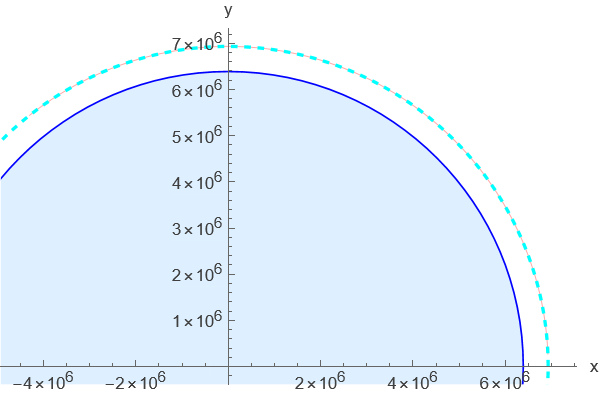

In [440]:
(* 4. Trajectory comparison *)

PLOTOscTraj = ParametricPlot[{xOsc[t], yOsc[t]}, {t, 0, tfin}, PlotStyle -> {Red, Thin}];

PLOTpreviousTraj = PolarPlot[rAnalyt[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, Theta],{Theta, 0, 2 Pi}, PlotStyle -> {Cyan, Dashed}];

PLOTKeplerComparison = Show[PLOTOscTraj,PLOTpreviousTraj,PLOTEarth,
  PlotLegends -> {"Osculating Kepler propagation (Correct)","Direct TLE geometry (Incorrect)"}, AxesLabel -> {"x", "y"}]
  

-Graphics-
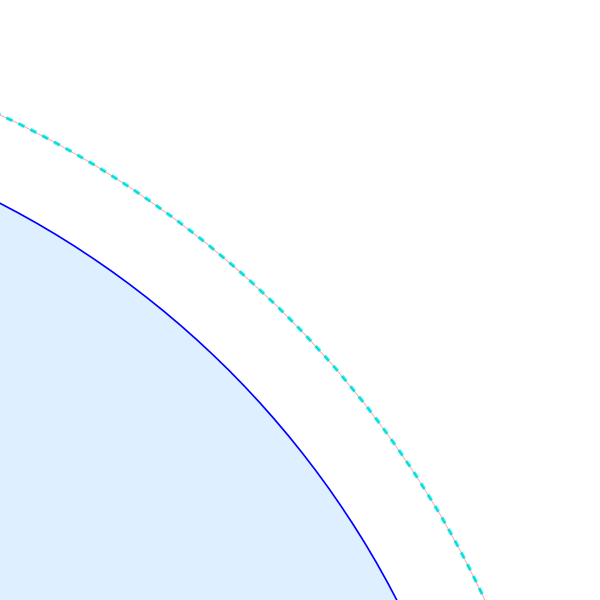

In [445]:
(* 5. Zoomed-in comparison *)

PLOTKeplerZoom = Show[PLOTpreviousTraj,PLOTOscTraj,PLOTEarth,
  PlotRange -> {{3 10^6, 7 10^6}, {3 10^6, 7 10^6}},
  PlotLegends -> {"Incorrect use","Correct osculating Kepler"},
  AxesLabel -> {"x", "y"}]

-Graphics-
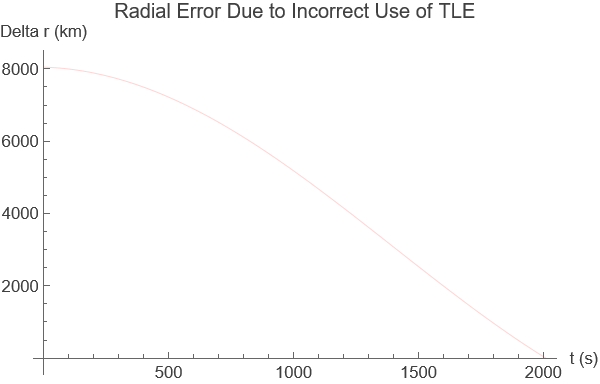

In [447]:
(* 6. Radial error vs time    *)

rprevious[t_] =
 rAnalyt[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp,
  ThetaSol[UM5EOSAT60555TLEra, UM5EOSAT60555TLErp, EccAnomTest]];

RadialError[t_] = (rprevious[t] - rOsc[t]);

PLOTRadialError =
 Plot[(RadialError[t]),{t, 0, tfin}, PlotStyle -> {Pink, Thin},
  AxesLabel -> {"t (s)", "Delta r (km)"},
  PlotLabel -> "Radial Error Due to Incorrect Use of TLE"]
  

In [452]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-4-err-rad.svg",PLOTRadialError]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-4-e\
 
>   rr-rad.svg

-Graphics-
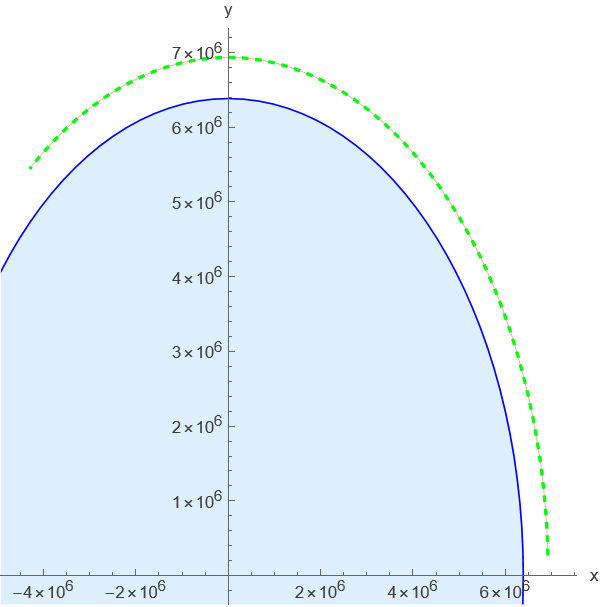

In [453]:
(* 7. Comparison with numerical 2-body solution  *)

PLOTFinalAll = Show[PLOTOscTraj,PLOTUM5EOSATTraj,PLOTEarth,
  PlotLegends -> {"Kepler (Correct use of TLE)", "Numerical 2-Body Integration"}, AspectRatio -> 1, AxesLabel -> {"x", "y"}]

In [455]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-4-Kepler-Numerical-Integration.svg", PLOTKeplerComparison]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-4-K\
 
>   epler-Numerical-Integration.svg

## <a class="anchor" id="4._Earth-Moon_spacecraft"></a> 4. Application of Kepler's equation: Hohmann transfer

[Back to Table of Contents](#Table_of_Contents) 

In this second application, we explore the trajectory of a spacecraft departing a parking low earth orbit (LEO) to hit the surface of the Moon. A very general treatment of the trajectories to travel from the Earth to the Moon is in Biesbroek and G. Janin (2000). 

In order to reduce the complexity of the full problem, we consider the trajectory in two dimensions ($2$D) and assume the orbit of the Moon to be in a circular orbit. This is a useful starting point to obtain values of important parameters that one could use in the full $3$D problem, for instance, using NASA GMAT. 

To provide the opportunity for personal study, a *small* fraction of the inital height of the parking LEO orbit is randomized. However, it may be useful to go through the entire exercise with the numerical values provided below *before* altering them as indicated by the randomly generated initial height below and again going through this Section.  

Extract a random initial parking orbit height by replacing the figures 1234 by the last $5$ (not $4$) digits of your cell phone number in `SeedRandom`:

In [464]:
SeedRandom[76452]; MyH0 = (185 + 10 RandomReal[{-0.5,0.5}]) 10^3

183830.

### <a class="anchor" id="4.1_Hohmann_transfer_Analytical_approach"></a> 4.1 Hohmann transfer: Analytical approach

[Back to Table of Contents](#Table_of_Contents) 

A spacecraft is in a circular orbit around the Earth at an initial altitude $H_{\mathrm{in}}$. Calculate:

**1.1** The $\Delta v$ needed for a Hohmann transfer from that orbit from the Earth to the mean distance of the Moon, $r_M = 384,400$ km. Use Mathematica so as to obtain the solution as a function of all important parameters and not just a numerical value. Go through the cells below *without* entering any numerical values, including the constants, so as to obtain algebraic solutions. Return to the top of the Notebook only later to obtain specific numerical values and graphs. Assume that the impulsive approximation is valid. This solution is referred to as th *minimum energy trajectory* (Bate, p 345 PDF).

In [469]:
kEarth = 3.986004418 10^(14);
RadiusEarth = 6.371 10^6;
gEarth = 9.8066 ;

RadiusMoon = 1.7374 10^6;
SMAMoon = 384400 10^3;

In [474]:
SemiMajor[ra_,rp_] =(1/2)(ra+rp);
Eccentricity[ra_,rp_]=(ra-rp)/(ra+rp);

SemiLatus[ra_,rp_] =SemiMajor[ra,rp](1-(Eccentricity[ra,rp])^2);

In [477]:
SemiMajor[384400 10^3,RadiusEarth + MyH0]
Eccentricity[384400 10^3,RadiusEarth + MyH0]

8
1.95477 10
0.966468

**Analytical trajectory**

The analytical translunar injection trajectory (TOI), assuming a burn at perigee for $\theta = -\pi$, going towards $\theta=0$, is:

2
                (ra - rp)
 (ra + rp) (1 - ----------)
                         2
                (ra + rp)
----------------------------
       (ra - rp) Cos[Theta]
2 (1 - --------------------)
             ra + rp
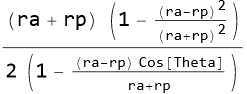

In [483]:
rAnalyt[ra_,rp_,Theta_] = SemiLatus[ra,rp]/(1 + Eccentricity[ra,rp]Cos[Theta - Pi ])

In [484]:
rAnalyt[SMAMoon,RadiusEarth + MyH0, 0]

8
3.844 10

-Graphics-
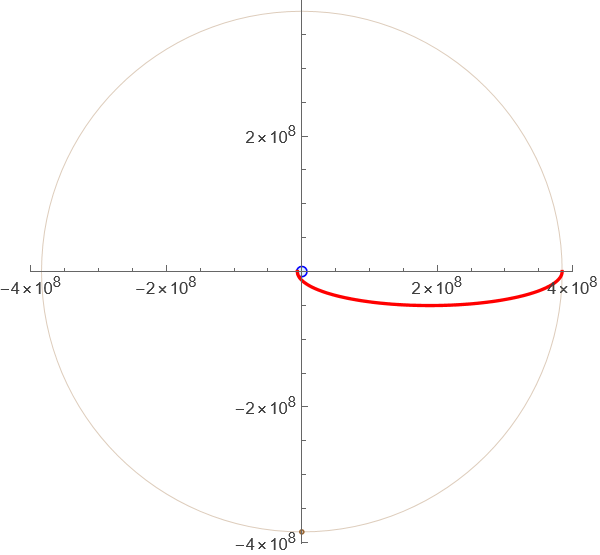

In [485]:
PLOTEarthEdge = Graphics[{Blue,Thick,Circle[{0,0},RadiusEarth]} ,Axes->True];
PLOTEarthDisk = Graphics[{LightBlue,Disk[{0,0},RadiusEarth]} ];
PLOTEarth = Show[PLOTEarthEdge,PLOTEarthDisk];

ThetaMoon = (3/2) Pi;
xMoon = SMAMoon Cos[ThetaMoon];
yMoon = SMAMoon Sin[ThetaMoon];
PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{xMoon,yMoon},RadiusMoon]} ,Axes->True];
PLOTMoonDisk = Graphics[{LightBrown,Disk[{xMoon,yMoon},RadiusMoon]} ];
PLOTMoon = Show[PLOTMoonEdge,PLOTMoonDisk];


PLOTMoonOrbit = Graphics[{Brown,Thin,Circle[{0,0},SMAMoon]} ,Axes->True];

PLOTTranslunar = PolarPlot[rAnalyt[SMAMoon,RadiusEarth + MyH0,Theta],{Theta, -Pi ,0},PlotRange->{{-4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}},PlotStyle->{Red,Thick}];
Show[PLOTMoon,PLOTEarth,PLOTMoonOrbit,PLOTTranslunar]

The above results allow us to calculate the specific angular momentum:

2
          7                     (ra - rp)
1.41174 10  Sqrt[(ra + rp) (1 - ----------)]
                                         2
                                (ra + rp)
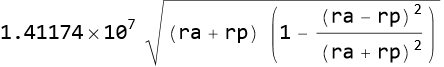

In [501]:
SpecAngMom[ra_,rp_]= Sqrt[kEarth SemiMajor[ra,rp] (1-((Eccentricity[ra,rp])^2))]

In [502]:
SpecAngMom[384400 10^3,RadiusEarth + MyH0]

10
7.16792 10

We can now divide the specific angular momentum by the perigee distance to obtain the perigee speed needed for translunar orbit injection (TOI). 

In [507]:
vpAfter[ra_,rp_]= SpecAngMom[ra,rp] / rp ;

In [508]:
vpAfter[384400 10^3,RadiusEarth + MyH0]

10935.3

7      1
1.9965 10  Sqrt[--]
                rp
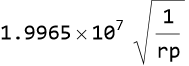

In [509]:
vcirc [rp_] = Sqrt[kEarth /rp ]

In [510]:
vcirc [RadiusEarth + MyH0]

7798.09

2
                                 7                     (ra - rp)
                       1.41174 10  Sqrt[(ra + rp) (1 - ----------)]
                                                                2
          7      1                                     (ra + rp)
-1.9965 10  Sqrt[--] + --------------------------------------------
                 rp                         rp
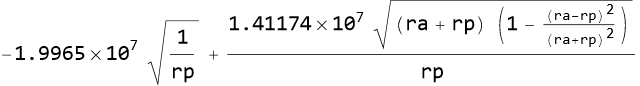

In [511]:
Deltav [ra_,rp_]= vpAfter[ra,rp] - vcirc [rp]

In [512]:
(*Another example*)

Deltav [384400 10^3,RadiusEarth + 320 10^3]

3103.26

Check your numerical values with the first estimates provided in Bate (pp. 330-331).

-Graphics-
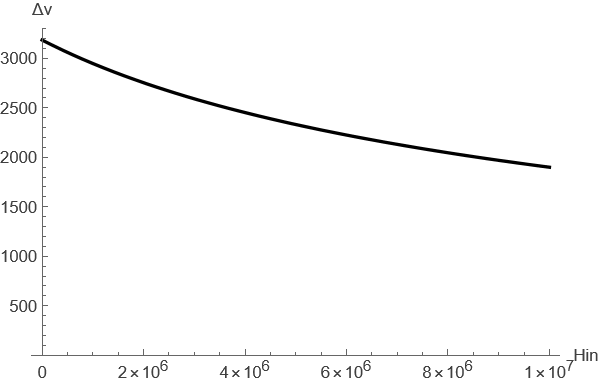

In [518]:
PLOTDeltav = Plot[Deltav [384400 10^3,RadiusEarth + Hin],{Hin,0,10000 10^3},PlotRange->{0,3.3 10^3},PlotStyle->Black,AxesLabel->{"Hin", "Δv"}]

### <a class="anchor" id="4.1_1_The_rocket_equation"></a> 4.1.1. The rocket equation

[Back to Table of Contents](#Table_of_Contents) 

We shall now use the rocket equation to determine the amount of fuel needed to achieve translunar injection, $\Delta M$. Assume that the quantities given are the specific impulse, $I_s$, and the total (wet) initial mass, $M_{\mathrm{in}}$ (Kittel 1973, Sutton 2017)
. 

In [523]:
vexh [Is_] = Is gEarth 

9.8066 Is

In [524]:
vexh [311]

3049.85

In [525]:
DeltaM [ra_,rp_,Is_,Min_] = Min( 1 - Exp[-(Deltav [ra,rp]/vexh [Is])]);

In [526]:
DeltaM [SMAMoon,RadiusEarth + MyH0, 311, 10 10^3]

6425.11

-Graphics-
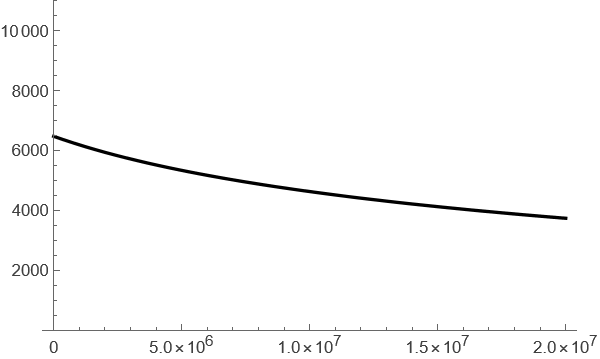

In [527]:
PLOTDeltaM = Plot[DeltaM [SMAMoon,RadiusEarth + Hin, 311, 10 10^3], {Hin,0,20000 10^3},PlotRange->{0,11000},PlotStyle->Black]

The plot marks in red a realistic range of engine performance.

-Graphics-
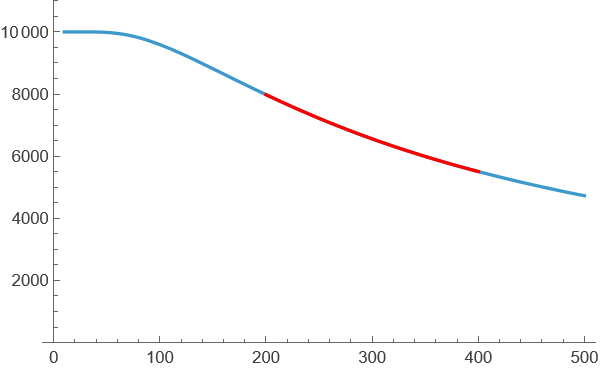

In [532]:
PLOTDeltaM1=Plot[DeltaM [384400 10^3,RadiusEarth + MyH0, Is, 10 10^3], {Is,10,500},PlotRange->{0,11000}];
PLOTDeltaM2=Plot[DeltaM [384400 10^3,RadiusEarth + MyH0, Is, 10 10^3], {Is,200,400},PlotRange->{0,11000},PlotStyle->{Red,Thick}];
PLOTDeltaMAll = Show[PLOTDeltaM1,PLOTDeltaM2]

### <a class="anchor" id="4.1_2_Burn_time"></a>  4.1.2 Burn time

[Back to Table of Contents](#Table_of_Contents) 


Using the definition of specific impulse, find the mass flow rate, $\dot{m}$, and, from that value, the time 
$\Delta t_{\mathrm{burn}}$ needed to complete the burn.



MassFlowRate[Is_,FThrust_] = FThrust/(Is gEarth)

In [543]:
MassFlowRate[311,100 10^3]

MassFlowRate[311, 100000]

By diving the total $\Delta v$ by the mass flow rate, $\dot{m}$, we find the burn duration $\Delta t_{\mathrm{burn}}$:

In [548]:
DeltatBurn[ra_, rp_, Is_, Min_, FThrust_] = DeltaM [ra,rp,Is,Min]/MassFlowRate[Is,FThrust];

6425.11
-------------------------
MassFlowRate[311, 100000]
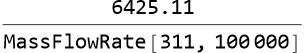

In [549]:
DeltatBurn[384400 10^3,RadiusEarth + MyH0, 311, 10 10^3, 100 10^3]

Since the period of revolution in the transfer orbit is:

In [554]:
TPerSC [ra_,rp_] = (2 Pi / Sqrt[kEarth]) ((SemiMajor[ra,rp])^(3/2)) 

TPerSC [SMAMoon,RadiusEarth + MyH0]

-7          3/2
1.11267 10   (ra + rp)
860114.

that is, $\Delta t_{\mathrm{burn}} \ll T$, the validity of the impulsive approximation in this case is confirmed.

### <a class="anchor" id="4.1_3_Travel_time"></a> 4.1.3. Travel time

[Back to Table of Contents](#Table_of_Contents) 


Let us calculate the travel time from the impulsive burn to arrival to the Moon along a Hohmann transfer:

$$
t_{\mathrm{Hoh}} = \textstyle{1\over 2} T_{\mathrm{Per,\, Hoh}}\, , 
$$

where $T_{\mathrm{Per,\, Hoh}}$ is the period of revolution of the spacecraft in the full Hohmann orbit (if it returned to Earth without interacting with the Moon). 

In [564]:
Tti [ra_,rp_] = (1/2) TPerSC [ra,rp] 

-8          3/2
5.56334 10   (ra + rp)

In [565]:
Tti [384400 10^3,RadiusEarth + MyH0]
Tti [384400 10^3,RadiusEarth + MyH0]/86400 

430057.
4.97751

Notice that, for instance:

In [571]:
Tti [384400 10^3,RadiusEarth + 10000 10^3]

446355.

More in general:

-Graphics-
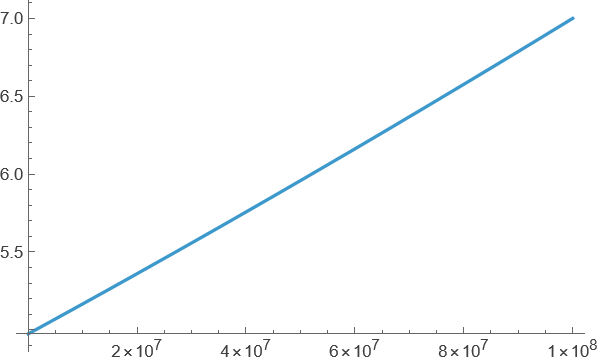

In [576]:
Plot[Tti [384400 10^3,RadiusEarth + Hin]/86400,{Hin,0,100000 10^3}]

### <a class="anchor" id="4.2_Position_along_the_Hohmann"></a>  4.2 Position along the Hohmann transfer as a function of time

[Back to Table of Contents](#Table_of_Contents) 


Use the above information for a translunar trajectory with perigee altitude, $H_p$ and apogee $r_a$:

$$
H_{p} =  {\mathrm{your\, randomly\, extracted\, value}} \, ;\,\,\, r_{a} =  r_{\mathrm{Moon}} = 3.84400\times 10^8\,\, {\mathrm{m}}
$$

Calculate and display the position the spacecraft every 24 hours by means of Kepler's equation till the 5th day included. When you choose the roots of the various equations involved, remember that we assume the spececraft is orbiting the Earth counter-clockwise (CCW) so that the angular momentum with respect to the center of the Earth is oriented outside the page.  

Carefully notice that, in this case, although the problem starts from the spacecraft at periapsis, the ellipse is oriented differently than in our previous examples, as it is not resting on the positive but on the *negative* $x$-axis. Hence the argument of the periapsis $\omega =\pi$ is added to the true anomaly after the solution is found.   

### <a class="anchor" id="4.2_1_Travel_time"></a> 4.2.1. Analytical approach: Kepler's equation

[Back to Table of Contents](#Table_of_Contents) 

In [585]:
SemiMajor[SMAMoon,RadiusEarth + MyH0]
Eccentricity[SMAMoon,RadiusEarth + MyH0]

8
1.95477 10
0.966468

In [587]:
MeanMotion[RadiusEarth + MyH0, SMAMoon]
PeriodSat[RadiusEarth + MyH0, SMAMoon]

MeanMotion[RadiusEarth + MyH0, SMAMoon] PeriodSat[RadiusEarth + MyH0, SMAMoon]

-6
7.30506 10
860114.
6.28319

**Day 1**

In [594]:
TimeFinalTest = 86400

86400

7               -3
5.64695 10  Sqrt[(ra + rp)  ] TimeFinal
0.631158
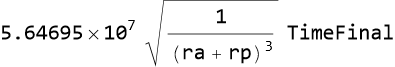

In [595]:
MeanAnomaly[rp_,ra_,TimeFinal_] = MeanMotion[rp,ra] TimeFinal 
MeanAnomaly[SMAMoon,RadiusEarth + MyH0, TimeFinalTest]

-Graphics-
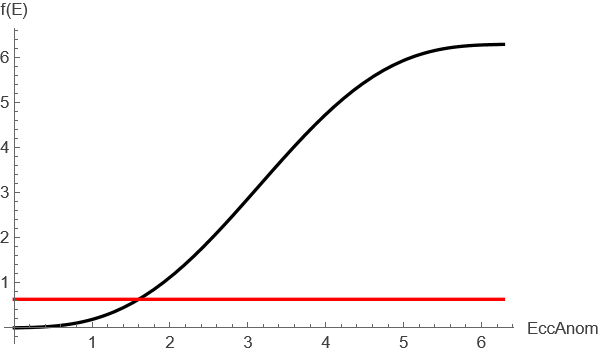

In [597]:
PLOT1B = Plot[EccAnom - Eccentricity[SMAMoon,RadiusEarth + MyH0] Sin[EccAnom],{EccAnom,0, 2 Pi},AxesLabel->{"EccAnom","f(E)"},PlotStyle->Black];
PLOT2B = Plot[MeanAnomaly[SMAMoon,RadiusEarth + MyH0, TimeFinalTest], {EccAnom,0,2 Pi},PlotStyle->Red];
PLOTALLB= Show[PLOT1B,PLOT2B]

In [600]:
EccAnomTestA = FindRoot[MeanAnomaly[SMAMoon,RadiusEarth + MyH0, TimeFinalTest] == EccAnom - Eccentricity[SMAMoon,RadiusEarth + MyH0] Sin[EccAnom],{EccAnom, 3}][[1,2]]

1.59729

In [601]:
rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestA]
NumberForm[rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA],12]

8
2.00481 10
                  8
2.00481330848 × 10

In [603]:
ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA]  + Pi
NumberForm[ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA] + Pi,12]    

ThetaSol2[SMAMoon, RadiusEarth + MyH0, EccAnomTestA]  + Pi 
NumberForm[ThetaSol2[SMAMoon, RadiusEarth + MyH0, EccAnomTestA] + Pi,12]  

6.0302
6.03020398943
6.0302
6.03020398943

-Graphics-
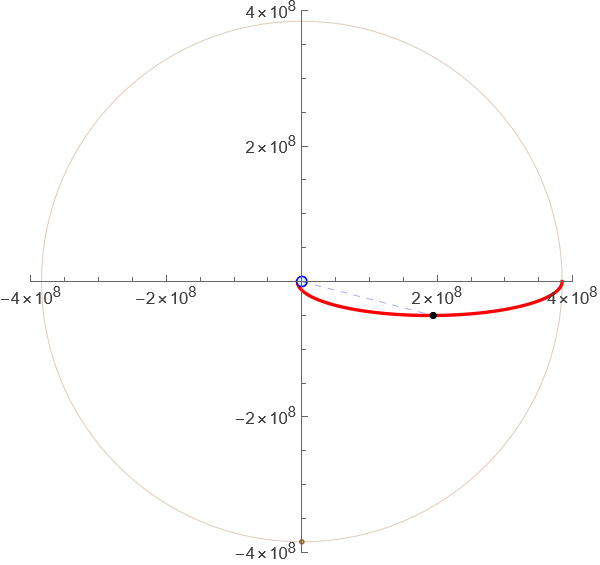

In [607]:
PLOTSCTest1 = ListPolarPlot[{{ThetaSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestA] + Pi, rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestA]}},PlotStyle->Black];
PLOTSCTestVector1 = ListPolarPlot[{{0,0},{ThetaSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestA] + Pi, rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestA]}},PlotMarkers->None,Joined->True,PlotStyle->{Blue,Thin,Dashed}];

PLOTAnalytAll = Show[PLOTTranslunar,PLOTMoon,PLOTEarth,PLOTMoonOrbit,PLOTSCTest1,PLOTSCTestVector1,PlotRange->{{- 4 10^8,4 10^8},{-4 10^8,4 10^8}}]

**Day 2**

172800
          7               -3
5.64695 10  Sqrt[(ra + rp)  ] TimeFinal
1.26232
-Graphics-
2.0977
          8
2.90479 10
                  8
2.90478787475 × 10
6.13326
6.13325644081
6.13326
6.13325644081
-Graphics-
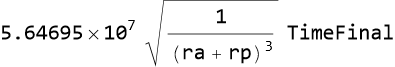
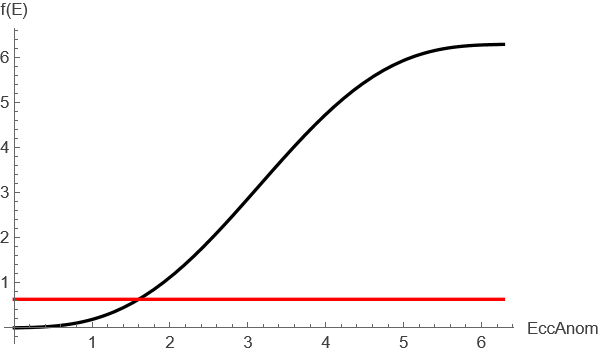
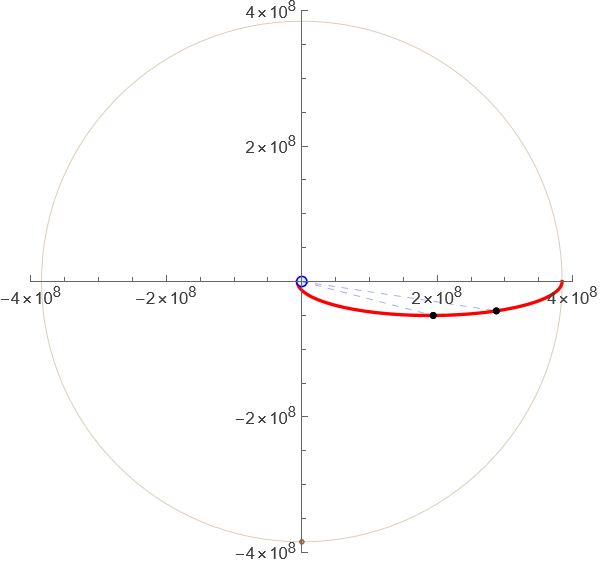

In [614]:
TimeFinalTest = 2 86400  

MeanAnomaly[rp_,ra_,TimeFinal_] = MeanMotion[rp,ra] TimeFinal 
MeanAnomaly[SMAMoon,RadiusEarth + MyH0, TimeFinalTest] 

PLOT1C = Plot[EccAnom - Eccentricity[SMAMoon,RadiusEarth + MyH0] Sin[EccAnom],{EccAnom,0, 2 Pi},AxesLabel->{"EccAnom","f(E)"},PlotStyle->Black];
PLOT2C = Plot[MeanAnomaly[SMAMoon,RadiusEarth + MyH0, TimeFinalTest], {EccAnom,0,2 Pi},PlotStyle->Red];
PLOTALLC= Show[PLOT1B, PLOT2B] 
(*do not change the letter "B" here*)
EccAnomTestB = FindRoot[MeanAnomaly[SMAMoon,RadiusEarth + MyH0, TimeFinalTest] == EccAnom - Eccentricity[SMAMoon,RadiusEarth + MyH0] Sin[EccAnom],{EccAnom, 3}][[1,2]] 

rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestB]
NumberForm[rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestB],12] 

ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestB] + Pi
NumberForm[ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestB] + Pi, 12] 

ThetaSol2[SMAMoon, RadiusEarth + MyH0, EccAnomTestB] + Pi
NumberForm[ThetaSol2[SMAMoon, RadiusEarth + MyH0, EccAnomTestB] + Pi, 12] 

PLOTSCTest2 = ListPolarPlot[{{ThetaSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestB] + Pi, rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestB]}},PlotStyle->Black];
PLOTSCTestVector2 = ListPolarPlot[{{0,0},{ThetaSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestB] + Pi, rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestB]}},PlotMarkers->None,Joined->True,PlotStyle->{Blue,Thin,Dashed}];

PLOTAnalytAll = Show[PLOTTranslunar, PLOTMoon, PLOTEarth, PLOTMoonOrbit, PLOTSCTest1, PLOTSCTestVector1, PLOTSCTest2, PLOTSCTestVector2, PlotRange->{{- 4 10^8,4 10^8},{-4 10^8,4 10^8}}]

**Day 3**


In [635]:
TimeFinalTest = 3 86400;

MeanAnomaly[SMAMoon, RadiusEarth + MyH0, TimeFinalTest]

EccAnomTestC =  FindRoot[ MeanAnomaly[SMAMoon, RadiusEarth + MyH0, TimeFinalTest] ==EccAnom - Eccentricity[SMAMoon, RadiusEarth + MyH0] Sin[EccAnom],{EccAnom, 3}][[1, 2]];

PLOTSCTest3 = ListPolarPlot[{{ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestC] + Pi,rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestC]}},PlotStyle -> Black];

PLOTSCTestVector3 = ListPolarPlot[{{0, 0},{ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestC] + Pi, rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestC]}},
Joined -> True,PlotStyle -> {Blue, Thin, Dashed}];

1.89347

**Day 4**

In [644]:
TimeFinalTest = 4 86400;

MeanAnomaly[SMAMoon, RadiusEarth + MyH0, TimeFinalTest]

EccAnomTestD = 
  FindRoot[MeanAnomaly[SMAMoon, RadiusEarth + MyH0, TimeFinalTest] ==EccAnom -  Eccentricity[SMAMoon, RadiusEarth + MyH0] Sin[EccAnom],{EccAnom, 3}][[1, 2]];

PLOTSCTest4 = ListPolarPlot[ {{ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestD] + Pi,   rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestD]}}, PlotStyle -> Black];

PLOTSCTestVector4 = ListPolarPlot[{{0, 0}, {ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestD] + Pi,  rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestD]}},
Joined -> True, PlotStyle -> {Blue, Thin, Dashed}];


2.52463

**Arrival at Apogee**

430057.
3.14159
-Graphics-
3.14159
        8
3.844 10
          8
3.844 × 10
6.28319
6.28318530718
6.28319
6.28318530718
-Graphics-
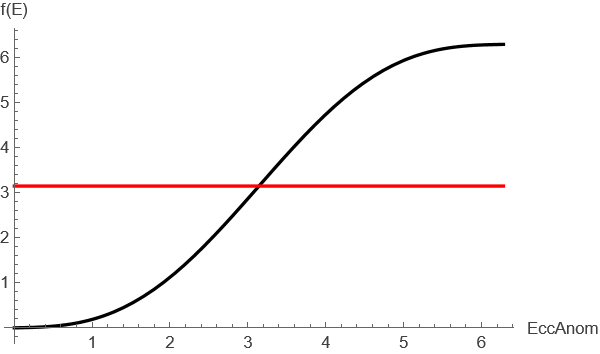
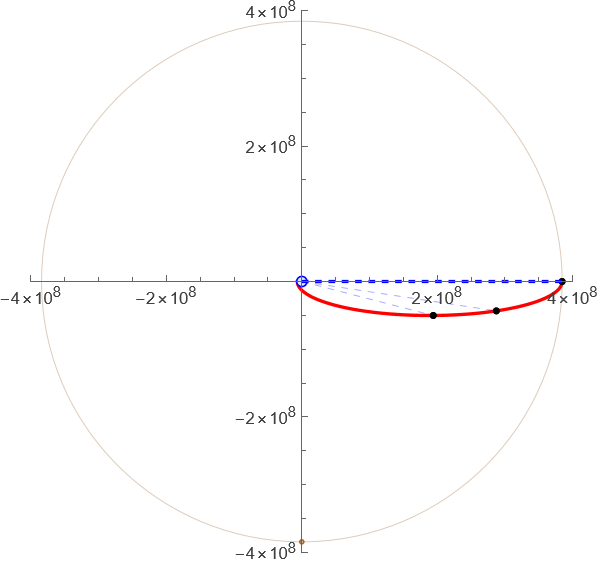

In [653]:
TimeFinalTest = Tti [384400 10^3,RadiusEarth + MyH0]

MeanAnomaly[SMAMoon,RadiusEarth + MyH0, TimeFinalTest] 

PLOT1F = Plot[EccAnom - Eccentricity[SMAMoon,RadiusEarth + MyH0] Sin[EccAnom],{EccAnom,0, 2 Pi},AxesLabel->{"EccAnom","f(E)"},PlotStyle->Black];
PLOT2F = Plot[MeanAnomaly[SMAMoon,RadiusEarth + MyH0, TimeFinalTest], {EccAnom,0,2 Pi},PlotStyle->Red];
PLOTALLF= Show[PLOT1F,PLOT2F] 

EccAnomTestF = FindRoot[MeanAnomaly[SMAMoon,RadiusEarth + MyH0, TimeFinalTest] == EccAnom - Eccentricity[SMAMoon,RadiusEarth + MyH0] Sin[EccAnom],{EccAnom, 3}][[1,2]] 

rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestF]
NumberForm[rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF],12] 

ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF] + Pi
NumberForm[ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF] + Pi,12] 

ThetaSol2[SMAMoon, RadiusEarth + MyH0, EccAnomTestF] + Pi
NumberForm[ThetaSol2[SMAMoon, RadiusEarth + MyH0, EccAnomTestF] + Pi,12] 

PLOTSCTestF = ListPolarPlot[{{ThetaSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestF] + Pi, rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestF]}},PlotStyle->Black];
PLOTSCTestVectorF = ListPolarPlot[{{0,0},{ThetaSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestF] + Pi, rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestF]}},PlotMarkers->None,Joined->True,PlotStyle->{Blue,Thick,Dashed}];

PLOTAnalytAll = Show[PLOTTranslunar, PLOTMoon, PLOTEarth, PLOTMoonOrbit, PLOTSCTest1, PLOTSCTestVector1, PLOTSCTest2, PLOTSCTestVector2, PLOTSCTestF, PLOTSCTestVectorF, PlotRange->{{- 4 10^8,4 10^8},{-4 10^8,4 10^8}}]

-Graphics-
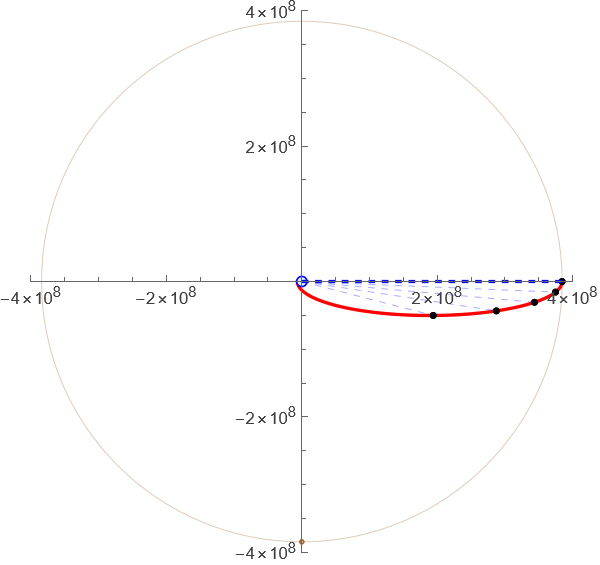

In [668]:
PLOTAnalytAll = Show[
  PLOTTranslunar,
  PLOTMoon,
  PLOTEarth,
  PLOTMoonOrbit,
  PLOTSCTest1, PLOTSCTestVector1,
  PLOTSCTest2, PLOTSCTestVector2,
  PLOTSCTest3, PLOTSCTestVector3,
  PLOTSCTest4, PLOTSCTestVector4,
  PLOTSCTestF, PLOTSCTestVectorF,
  PlotRange -> {{-4 10^8, 4 10^8}, {-4 10^8, 4 10^8}}]


In [669]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-5-Analytical-Approach.svg", PLOTAnalytAll]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-5-A\
 
>   nalytical-Approach.svg

### <a class="anchor" id="4.2_2_Travel_time"></a> 4.2.2. Numerical approach

[Back to Table of Contents](#Table_of_Contents) 


*HINT: Notice that we are executing the burn at perigee and this requires some minor syntax changes*

In [674]:
SpecAngMomenIn [ra_,rp_]= Sqrt[kEarth SemiMajor[ra,rp] (1-(Eccentricity[ra,rp])^2) ];
vt0In[ra_,rp_]=(SpecAngMomenIn [ra,rp])/rp; 

In [676]:
r0 = RadiusEarth + MyH0
vt0 = vt0In[SMAMoon,(RadiusEarth + MyH0)]

6
6.55483 10
10935.3

We shall immediately integrate all the way to apogee but we shall query the solution on the needed date.

In [682]:
LengthDay = 86400;

In [683]:
tfin = Tti [384400 10^3,RadiusEarth + MyH0]

430057.

{0., {{r -> InterpolatingFunction[{{0., 430057.}}, <>]}}}
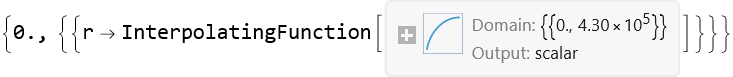

In [684]:
Clear[SolKeplerRad,r]

Timing[SolKeplerRad =NDSolve[{r''[t] == (SpecAngMomenIn [SMAMoon,(RadiusEarth + MyH0)])^2 (1/(r[t])^3) - (kEarth/(r[t])^2) ,r[0]==r0,r'[0]==+0.},r,{t,0,tfin},AccuracyGoal->16,PrecisionGoal->16,MaxSteps-> ∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

In [686]:
rSolNum[t_] = Evaluate[r[t] /. SolKeplerRad][[1]];

rDotSolNum[t_] = Evaluate[r'[t] /. SolKeplerRad][[1]];

ThetaAngDotNum[t_] = (lSpecAngMom[r0,vt0])(1/(rSolNum[t])^2);
vtSolNum[t_] = ThetaAngDot[t]rSolNum[t]; 

VSolNum[t_] = Sqrt[((vtSolNum[t])^2)+((rDotSolNum[t])^2)];

{{ThetaAng -> InterpolatingFunction[{{0., 430057.}}, <>]}}
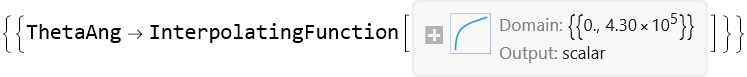

In [691]:
Clear[SolKeplerAng]

SolKeplerAng =NDSolve[{ThetaAng'[t] == (SpecAngMomenIn [SMAMoon,(RadiusEarth + MyH0)])(1/(rSolNum[t])^2) ,ThetaAng[0]==Pi},ThetaAng,{t,0,tfin},AccuracyGoal->15,PrecisionGoal->15,MaxSteps->∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]

InterpolatingFunction[{{0., 430057.}}, <>][t]
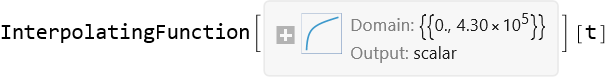

In [693]:
ThetaAngSolNum[t_] = Evaluate[ThetaAng[t] /. SolKeplerAng][[1]]

**Numerical Trajectory**

In [698]:
xSolNum[t_] = rSolNum[t] Cos[ThetaAngSolNum[t]];
ySolNum[t_] = rSolNum[t] Sin[ThetaAngSolNum[t]];

-Graphics-
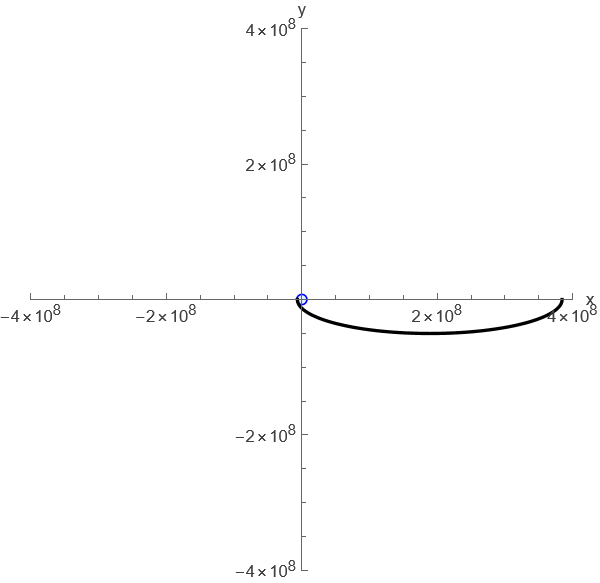

In [700]:
PLOTSatelliteTraj = ParametricPlot[{xSolNum[t],ySolNum[t]},{t,0,tfin},Axes->True,AxesLabel->{"x","y"},PlotStyle->{Black}];

PLOTEarthEdge = Graphics[{Blue,Thick,Circle[{0,0},RadiusEarth]} ,Axes->True,AxesLabel->{"x","y"}];
PLOTEarthDisk = Graphics[{LightBlue,Disk[{0,0},RadiusEarth]}];
PLOTEarth = Show[PLOTEarthEdge,PLOTEarthDisk];

PlotNumerAll  = Show[PLOTEarth,PLOTSatelliteTraj,PlotRange->{{-4 10^8,4 10^8},{-4 10^8,4 10^8}}]

**Day 1**

In [709]:
rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestA]

NumberForm[rSolNum[LengthDay],20]

RelErrNum2BPrSol = Abs[(rSolNum[LengthDay] - rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA])/rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA]]

8
2.00481 10
                      8
2.004813291280545 × 10
          -9
8.57747 10

In [712]:
NumberForm[ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA] + Pi,20] 
NumberForm[ThetaAngSolNum[LengthDay],20]


RelErrNum2BPThetaAngSol = Abs[(ThetaAngSolNum[LengthDay] - (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA] + Pi))/(ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA]+ Pi)]

6.030203989425603
6.030207517532299
          -7
5.85073 10

-Graphics-
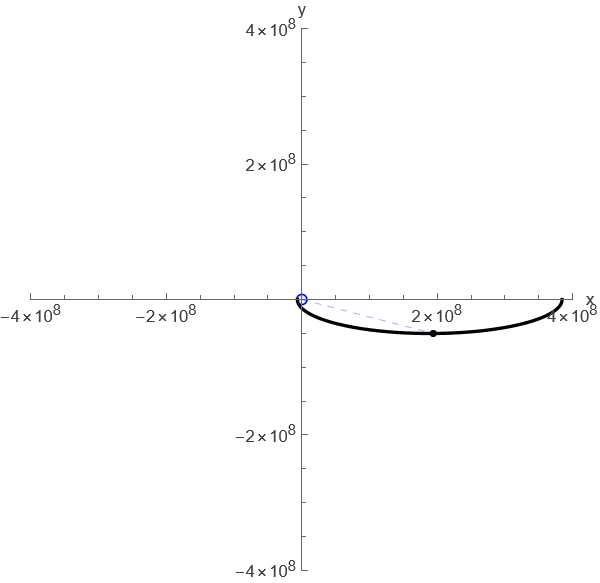

In [715]:
PLOTSCTestNum1 = ListPolarPlot[{{ThetaAngSolNum[LengthDay], rSolNum[LengthDay]}},PlotStyle->Black];
PLOTSCTestVectorNum1 = ListPolarPlot[{{0,0},{ThetaAngSolNum[LengthDay], rSolNum[LengthDay]}},PlotMarkers->None,Joined->True,PlotStyle->{Blue,Thin,Dashed}]; 

PlotNumerAll  =Show[PLOTEarth,PLOTSatelliteTraj, PLOTSCTestNum1, PLOTSCTestVectorNum1, PlotRange->{{- 4 10^8,4 10^8},{-4 10^8,4 10^8}}]

**Day 2** 

In [722]:
PLOTSCTestNum2 = ListPolarPlot[
  {{ThetaAngSolNum[2 LengthDay], rSolNum[2 LengthDay]}},
  PlotStyle -> Black];

PLOTSCTestVectorNum2 = ListPolarPlot[
  {{0, 0}, {ThetaAngSolNum[2 LengthDay], rSolNum[2 LengthDay]}},
  Joined -> True,
  PlotStyle -> {Blue, Thin, Dashed}];


**Day 3**

In [728]:
PLOTSCTestNum3 = ListPolarPlot[
  {{ThetaAngSolNum[3 LengthDay], rSolNum[3 LengthDay]}},
  PlotStyle -> Black];

PLOTSCTestVectorNum3 = ListPolarPlot[
  {{0, 0}, {ThetaAngSolNum[3 LengthDay], rSolNum[3 LengthDay]}},
  Joined -> True,
  PlotStyle -> {Blue, Thin, Dashed}];


**Day 4**

In [734]:
PLOTSCTestNum4 = ListPolarPlot[
  {{ThetaAngSolNum[4 LengthDay], rSolNum[4 LengthDay]}},
  PlotStyle -> Black];

PLOTSCTestVectorNum4 = ListPolarPlot[
  {{0, 0}, {ThetaAngSolNum[4 LengthDay], rSolNum[4 LengthDay]}},
  Joined -> True,
  PlotStyle -> {Blue, Thin, Dashed}];


**Arrival at Apogee**

In [740]:
rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestF]
NumberForm[rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF],12] 

NumberForm[rSolNum[tfin],20]

RelErrNum2BPrSol = Abs[(rSolNum[tfin] - rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestF])/rSol[SMAMoon,RadiusEarth + MyH0, EccAnomTestF]]

8
3.844 10
          8
3.844 × 10
                      8
3.844000000000585 × 10
          -13
1.52113 10

In [744]:
ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF] + Pi
NumberForm[ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF] + Pi,12] 

NumberForm[ThetaAngSolNum[tfin],20]

RelErrNum2BPThetaAngSol = Abs[(ThetaAngSolNum[tfin] - (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF] + Pi))/(ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF] + Pi)]

6.28319
6.28318530718
6.283185202821345
          -8
1.66091 10

-Graphics-
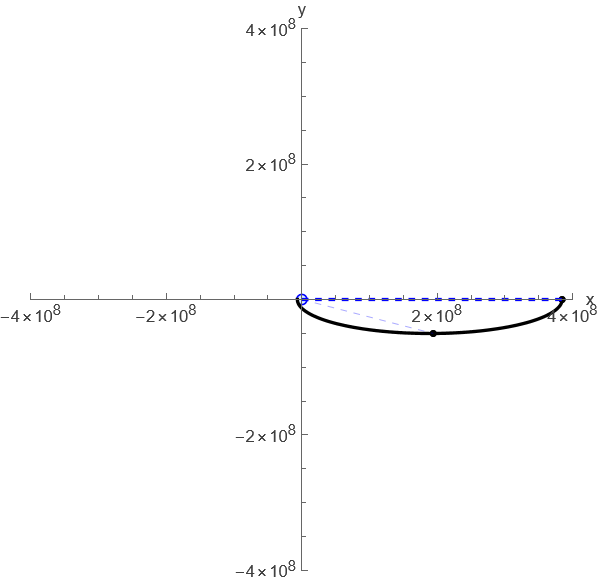

In [748]:
PLOTSCTestNum5 = ListPolarPlot[{{ThetaAngSolNum[tfin], rSolNum[tfin]}},PlotStyle->Black];
PLOTSCTestVectorNum5 = ListPolarPlot[{{0,0},{ThetaAngSolNum[tfin], rSolNum[tfin]}},PlotMarkers->None,Joined->True,PlotStyle->{Blue, Dashed}];

PlotNumerAll  =Show[PLOTEarth,PLOTSatelliteTraj, PLOTSCTestNum1, PLOTSCTestVectorNum1, PLOTSCTestNum5, PLOTSCTestVectorNum5, PlotRange->{{- 4 10^8,4 10^8},{-4 10^8,4 10^8}}]

-Graphics-
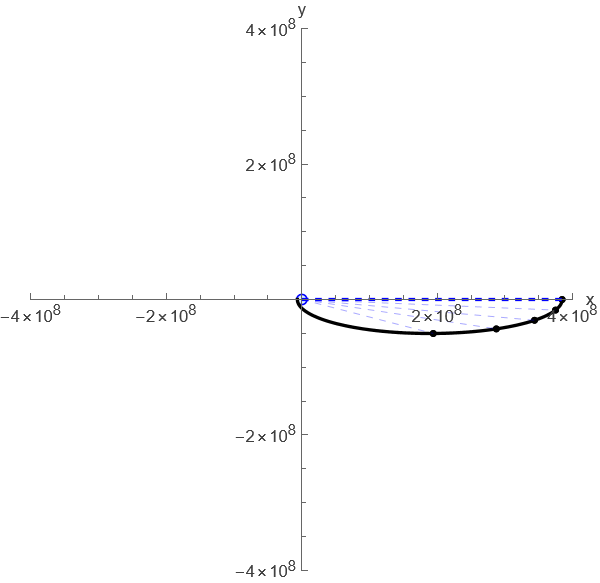

In [751]:
PlotNumerAll = Show[
  PLOTEarth,
  PLOTSatelliteTraj,
  PLOTSCTestNum1, PLOTSCTestVectorNum1,
  PLOTSCTestNum2, PLOTSCTestVectorNum2,
  PLOTSCTestNum3, PLOTSCTestVectorNum3,
  PLOTSCTestNum4, PLOTSCTestVectorNum4,
  PLOTSCTestNum5, PLOTSCTestVectorNum5,
  PlotRange -> {{-4 10^8, 4 10^8}, {-4 10^8, 4 10^8}}]


In [752]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-6-Numerical-Approach.svg", PlotNumerAll]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-6-N\
 
>   umerical-Approach.svg

**Answer of 11. Relative discrepancy between analytical and numerical solutions**Answer of 11. Relative discrepancy between analytical and numerical solutions****

The relative discrepancy between the **numerical two–body propagation** and the
**analytical Kepler solution** is evaluated at selected epochs
$ t_i = 1\,\mathrm{d}, 2\,\mathrm{d}, 3\,\mathrm{d}, 4\,\mathrm{d}, t_{\mathrm{Hoh}} $.


In [757]:
(*Day 1*)
RelErrNum2BPrSolDay1 =
 Abs[(rSolNum[LengthDay] -
   rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA])/
  rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA]]

RelErrNum2BPThetaAngSolDay1 =
 Abs[(ThetaAngSolNum[LengthDay] -
   (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA] + Pi))/
  (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestA] + Pi)]

(*Day 2*)
RelErrNum2BPrSolDay2 =
 Abs[(rSolNum[2 LengthDay] -
   rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestB])/
  rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestB]]

RelErrNum2BPThetaAngSolDay2 =
 Abs[(ThetaAngSolNum[2 LengthDay] -
   (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestB] + Pi))/
  (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestB] + Pi)]
  
(*Day 3*)
RelErrNum2BPrSolDay3 =
 Abs[(rSolNum[3 LengthDay] -
   rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestC])/
  rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestC]]

RelErrNum2BPThetaAngSolDay3 =
 Abs[(ThetaAngSolNum[3 LengthDay] -
   (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestC] + Pi))/
  (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestC] + Pi)]
  
(*Day 4*)
RelErrNum2BPrSolDay4 =
 Abs[(rSolNum[4 LengthDay] -
   rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestD])/
  rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestD]]

RelErrNum2BPThetaAngSolDay4 =
 Abs[(ThetaAngSolNum[4 LengthDay] -
   (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestD] + Pi))/
  (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestD] + Pi)]

(*Arrival at Apogee*)
RelErrNum2BPrSolFinal =
 Abs[(rSolNum[tfin] -
   rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF])/
  rSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF]]

RelErrNum2BPThetaAngSolFinal =
 Abs[(ThetaAngSolNum[tfin] -
   (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF] + Pi))/
  (ThetaSol[SMAMoon, RadiusEarth + MyH0, EccAnomTestF] + Pi)]

-9
8.57747 10
          -7
5.85073 10
          -9
5.99416 10
          -8
1.13689 10
          -11
8.82264 10
          -9
6.02123 10
          -10
4.02219 10
          -8
1.66519 10
          -13
1.52113 10
          -8
1.66091 10

-Graphics-
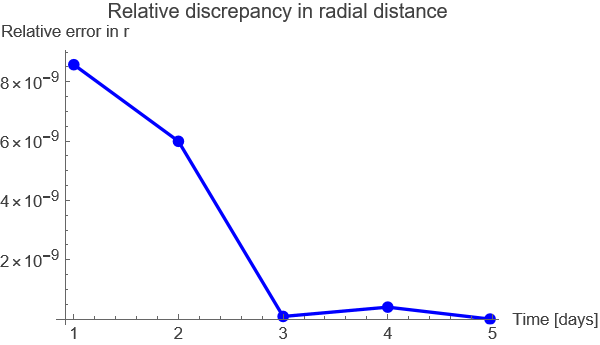

In [774]:
RadialRel = ListPlot[
 {{1, RelErrNum2BPrSolDay1},
  {2, RelErrNum2BPrSolDay2},
  {3, RelErrNum2BPrSolDay3},
  {4, RelErrNum2BPrSolDay4},
  {tfin/LengthDay, RelErrNum2BPrSolFinal} },
 Joined -> True,
 PlotMarkers -> Automatic,
 AxesLabel -> {"Time [days]", "Relative error in r"},
 PlotStyle -> Blue,
 PlotLabel -> "Relative discrepancy in radial distance"]

In [775]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-6-Radial-Discrepency.svg", RadialRel]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-6-R\
 
>   adial-Discrepency.svg

-Graphics-
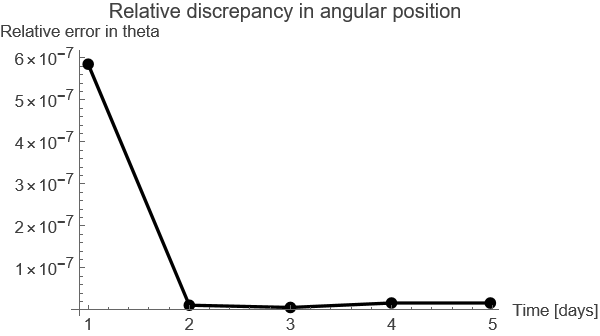

In [776]:
AngularRel= ListPlot[
 {{1, RelErrNum2BPThetaAngSolDay1},
  {2, RelErrNum2BPThetaAngSolDay2},
  {3, RelErrNum2BPThetaAngSolDay3},
  {4, RelErrNum2BPThetaAngSolDay4},
  {tfin/LengthDay, RelErrNum2BPThetaAngSolFinal}},
 Joined -> True,
 PlotMarkers -> Automatic,
 AxesLabel -> {"Time [days]", "Relative error in theta"},
 PlotStyle -> Black,
 PlotLabel -> "Relative discrepancy in angular position"]

In [777]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-7-Angular-Discrepency.svg", AngularRel]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-3-fig-7-A\
 
>   ngular-Discrepency.svg

## <a class="anchor" id="5._Patched_conic_approach"></a>  5. Patched conic approach

[Back to Table of Contents](#Table_of_Contents) 


In what follows, we follow the patched conic approach outlined by Bate (1971, Sec. 4).   

### <a class="anchor" id="5.1_Sphere_of_influence"></a>  5.1 Sphere of influence (SOI)

[Back to Table of Contents](#Table_of_Contents) 

The concept of the sphere of influence allows us to reduce a $3$-body problem to a sequence of $2$-body problems in which the effect of only one object on the spacecraft is considered at any given time. In this case, we shall divide the problem into two segments: the translunar orbit injection (TOI) phase, in which only the effect of the Earth is considered, and the terminal phase till impact with the Moon when the Earth is neglected.  

The criterion to determine whether a particular object must be considered the only one acting on the spacecraft is provided by the concept of *sphere of influence* (SOI), $R_S$ (sometimes this is referred to as the *activity sphere*). The theory of the sphere of influence is found in Danby (1988, Sec. 11.17), Prussing and Conway (1993, Sec. 7.2), Roy (2005, Sec. 7.4), and, in a broader context, by Araujo et al. (2008). Here we simply provide the expression that Bate et al. attribute to Laplace (Bate, Eq. 7.4-1), written in the case of the Moon:

$$
R_S = r_{\mathrm{Moon}}\Bigl( {M_{\mathrm{Moon}}\over M_\oplus}\Bigr)^{2/5}\, .
$$

The ratio of the masses can be found from the ratio of the standard gravitational parameters (Park et al. 2021).


In [790]:
SOIMoon = SMAMoon (kMoon/kEarth)^(2/5)

7
6.61829 10

We can now indicate the SOI of the Moon (yellow) at the Moon at a generic position:

-Graphics-
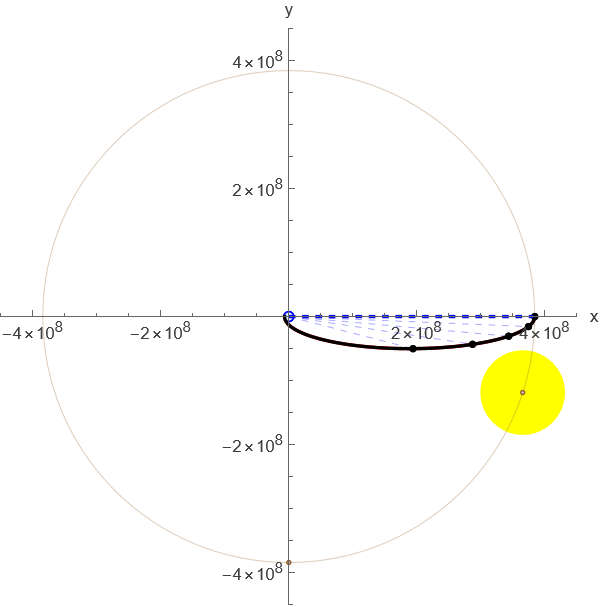

In [795]:
ThetaMoon = - 0.1 Pi;
xMoon = SMAMoon Cos[ThetaMoon];
yMoon = SMAMoon Sin[ThetaMoon];
PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{xMoon,yMoon},RadiusMoon]} ,Axes->True];
PLOTMoonDisk = Graphics[{LightBrown,Disk[{xMoon,yMoon},RadiusMoon]} ];
PLOTSOIMoon = Graphics[{Yellow,Disk[{xMoon,yMoon},SOIMoon]}];
PLOTMoon = Show[PLOTSOIMoon,PLOTMoonEdge,PLOTMoonDisk];

PlotNumerAll2  =Show[PLOTEarth,PLOTMoon,PLOTAnalytAll,PLOTSatelliteTraj,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}]

Notice that we shall define the quantities at translunar orbit injection (TOI) by a subscript "0", as ${\mathbf{r_0}}$, ${\mathbf{v_0}}$, $\phi_0$, and $\gamma_0$.

### <a class="anchor" id="5.2_Geocentric_departure"></a>  5.2 The geocentric departure orbit 

[Back to Table of Contents](#Table_of_Contents) 


As Bate (1971, Ch. 7) describes in some detail, the process of trajectory design for a lunar mission is by necessity iterative with a series of steps to be repeated till the solution converges to the desired properties. At that point, the data obtained from the patched conic approximation can be used as the starting point of a high-accuracy numerical solution. 

As Bate illustrates, one effective approach follows this plan:

$$
\boxed{{\mathrm{Choose}\,\,\, {\mathbf{r_0}},\,\, {\mathbf{v_0}},\,\, \phi_0\,\, ,\lambda_1  }}\rightarrow \boxed{{\mathrm{Find}\,\,\, {\mathbf{r_1}},\,\, {\mathbf{v_1}},\,\, \phi_1\,\, ,\gamma_1  }}\, ,  
$$

where all symbols are defined at Figs. 7.4-1 and 7.4-2 of Bate, with the subscript "1" referring to the properties of the spacecraft at the boundary of the lunary SOI: 

${\mathbf{r_0}}$: initial geocentric position <br>
${\mathbf{v_0}}$: initial geocentric velocity <br>
$\gamma_0$: phase angle at departure <br>
$\phi_0$: flight path angle at TOI, that is, the angle between ${\mathbf{r_0}}$ and ${\mathbf{v_0}}$ <br>

$\lambda_1$: angle between the selenocentric position vector of the Earth and the selenocentric position vector of the spacecraft at SOI entry.  <br>
$\phi_1$: flight path angle at SOI entry, that is, the angle between ${\mathbf{r_1}}$ and ${\mathbf{v_1}}$ <br>

Notice that in all examples you have seen so far all burns at periapsis or apoapsis were executed with a flight-path angle $\phi_0=0$. This is of course not necessarily always the case. 

The speed and flight path angle at entry into the lunar SOI are given from the conservation of energy and angular momentum during the translunar phase (here where appropriate the letters "SC" are added to indicate a spacecraft property), assuming a TOI at perigee, the specific energy and angular momentum at TOI are: 

$$
\cal E = \textstyle{1\over 2} v_0^2 - \displaystyle{{k_\oplus}\over r_0}\, ,
$$

$$
\ell = |{\mathbf{r_0}}\times {\mathbf{v_0}}| = r_0\, v_0 \cos\phi_0\, ,
$$ 

where, as usual, $|{\mathbf{r_0}}| = r_0$ and analogously for $v_0$. 

14       2
-3.986 10     vSC0
----------- + -----
    rp          2
rp vSC0 Cos[phiSC0]
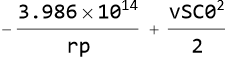

In [811]:
SpecEnergySC0 [rp_, vSC0_] = (((vSC0)^2)/2) - (kEarth/rp) 

SpecAngMomSC0 [rp_, vSC0_, phiSC0_] = rp vSC0 Cos[phiSC0]


Following Bate et al. (p. 335), we find for the distance from Earth $r_1$ at the SOI: 

In [817]:
rSC1[lambda1_] = Sqrt[((SMAMoon)^2) + ((SOIMoon)^2) - (2 SMAMoon SOIMoon)Cos[lambda1]]

17             16
Sqrt[1.52144 10   - 5.08814 10   Cos[lambda1]]

The speed $v_1$ is found by imposing the conservation of energy between TOI and SOI entry:

14       2                             14
             -3.986 10     vSC0                      3.986 10
Sqrt[2] Sqrt[----------- + ----- + ----------------------------------------------]
                 rp          2                    17             16
                                   Sqrt[1.52144 10   - 5.08814 10   Cos[lambda1]]
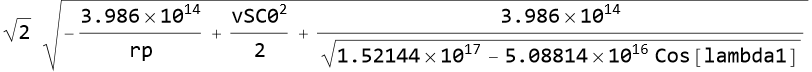

In [822]:
vSC1 [rp_, vSC0_,lambda1_] = Sqrt[2 (SpecEnergySC0[rp,vSC0] + (kEarth/rSC1[lambda1]))] 

The angle $\phi_1$ is found by imposing the conservation of angular momentum between TOI and SOI entry:

ArcCos[(rp vSC0 Cos[phiSC0]) / 
 
                            14       2                             14
                   -3.986 10     vSC0                      3.986 10
>    (Sqrt[2] Sqrt[----------- + ----- + ----------------------------------------------] 
                       rp          2                    17             16
                                         Sqrt[1.52144 10   - 5.08814 10   Cos[lambda1]]
 
                      17             16
>      Sqrt[1.52144 10   - 5.08814 10   Cos[lambda1]])]
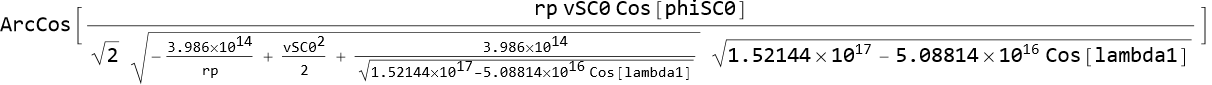

In [827]:
phiSC1[rp_, vSC0_, phiSC0_,lambda1_] = ArcCos[((SpecAngMomSC0 [rp, vSC0, phiSC0])/(rSC1[lambda1] vSC1 [rp, vSC0,lambda1]))]

The angle $\gamma_1$ is found from simple geometric considerations (Bate et al., Fig. 7.4-1) as a function of $\lambda_1$:

7
                  6.61829 10  Sin[lambda1]
ArcSin[----------------------------------------------]
                      17             16
       Sqrt[1.52144 10   - 5.08814 10   Cos[lambda1]]
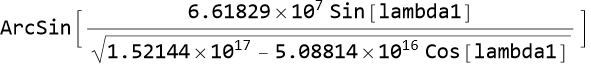

In [832]:
gammaSC1[lambda1_] = ArcSin[(SOIMoon/rSC1[lambda1])Sin[lambda1]]

### <a class="anchor" id="5.3_Conditions_at_patch_point"></a>  5.3 Conditions at patch point

[Back to Table of Contents](#Table_of_Contents) 

As we cross into the lunar SOI, only the mass of the Moon must be kept into consideration (Bate et al., Sec. 7.4.2). The distance from the Moon at that point is, of course, $r_2 = r_{\mathrm{SOI}}$. The velocity of the spacecraft relative to the Moon must be obtained from the vector difference between the velocity of the spacecraft in the geocentric reference frame and the velocity of the Moon in that same frame:

$$
{\mathbf{v_2}} = {\mathbf{v_1}} - {\mathbf{v_{Moon}}}\, .
$$

The speed of the Moon is found from the simplifying assumption that the Moon be moving in a circular orbit:

In [837]:
vMoon = Sqrt[kEarth/SMAMoon]

1018.3

The relative speed of the spacecraft, $v_2 = |{\mathbf{v_2}}|$, with respect to the Moon, is, from the law of cosines:

In [842]:
vSC2 [rp_, vSC0_, phiSC0_, lambda1_] = Sqrt[ ((vSC1 [rp, vSC0,lambda1])^2) + (vMoon^2) - 2 (vSC1 [rp, vSC0,lambda1]) vMoon Cos[(phiSC1[rp, vSC0, phiSC0,lambda1] - gammaSC1[lambda1])]];

Finally, notice that $\epsilon_2$ is the angle between the selenocentric position vector of the spacecraft and its selenocentric velocity. By projecting vectors ${\mathbf{v_2}}$, ${\mathbf{v_1}}$ and ${\mathbf{v_{Moon}}}$ onto the selenocentric position vector of the spacecraft, ${\mathbf{r_2}}$, we find: 

$$
v_2 \sin\epsilon_2 = v_{\mathrm{Moon}}\, \cos\lambda_1 - v_1\, \cos (\lambda_1 + \gamma_1 - \phi_1)\, ,
$$

which can be solved for $\epsilon_2$ to yield:  

In [847]:
EpsSC2 [rp_, vSC0_, phiSC0_,lambda1_] = ArcSin[(1/vSC2 [rp, vSC0, phiSC0, lambda1]) (vMoon Cos[lambda1] - vSC1 [rp, vSC0,lambda1] Cos[lambda1 + gammaSC1[lambda1] - phiSC1[rp, vSC0, phiSC0,lambda1]])];

$\epsilon_2$: initial selenocentric velocity direction relative to the Moon's center. 

Notice that, in our formulation, $\epsilon_2 = \epsilon_2(r_0=r_p, v_0, \phi_0, \lambda_1).$ 

### <a class="anchor" id="5.4_Selenocentric_arrival_orbit"></a>  5.4 Selenocentric arrival orbit

[Back to Table of Contents](#Table_of_Contents) 

We are now in the position of computing the selenocentric orbit elements. Since $\epsilon_2$ is the angle between the selenocentric position vector and the selenocentric velocity, it differs from the angle defining the angular momentum by $\pi/2$ so that the sine function must be used to calculate the angular momentum. Notice also that, to achieve a lunar impact, the most obvious condition is to require that:

$$
\epsilon_2 = 0\, .
$$. 

The specific energy and angular momentum at entry into the lunar SOI *in the selenocentric reference frame* are:

In [856]:
SpecEnergySC2 [rp_, vSC0_, phiSC0_, lambda1_] = (((vSC2 [rp, vSC0, phiSC0, lambda1])^2)/2) - (kMoon/SOIMoon); 

SpecAngMomSC2 [rp_, vSC0_, phiSC0_, lambda1_] = (vSC2 [rp, vSC0, phiSC0, lambda1]) (SOIMoon) Sin [EpsSC2 [rp, vSC0, phiSC0,lambda1]];

Once these quantities are known, the semilatus rectum and the eccentricity can be calculated as usual from the analytical solution for the trajectory of the $2$-body problem,: 

In [862]:
SemiLatus2 [rp_, vSC0_, phiSC0_, lambda1_] = ((SpecAngMomSC2 [rp, vSC0, phiSC0, lambda1])^2)/kMoon;

Eccentricity2 [rp_, vSC0_, phiSC0_, lambda1_] = Sqrt[1 + (2 SpecEnergySC2 [rp, vSC0, phiSC0, lambda1] (((SpecAngMomSC2 [rp, vSC0, phiSC0, lambda1])^2)/((kMoon)^2)))];

Finally we can find the perilune (also called *periselenium*), $r_{\mathrm{Perilune}}$, and the speed at perilune, $v_{\mathrm{Perilune}}$:

In [868]:
rPerilune [rp_, vSC0_, phiSC0_, lambda1_] = SemiLatus2 [rp, vSC0, phiSC0, lambda1]/ (1 + Eccentricity2 [rp, vSC0, phiSC0, lambda1]); 

vPerilune [rp_, vSC0_, phiSC0_, lambda1_] = Sqrt[2(SpecEnergySC2 [rp, vSC0, phiSC0, lambda1] + (kMoon/rPerilune [rp, vSC0, phiSC0, lambda1]))];

As discussed by Bate et al. (p 356 PDF), these final conditions must be assessed in light of the particular lunar mission being considered. Typically, these include:

1. Lunar impact;
2. Lunar orbit;
3. Circumlunar flight.

For instance, lunar impact will surely have been successfully achieved if $r_{\mathrm{Perilune}} \leq R_{\mathrm{Moon}}$. If the perilune conditions are unsatisfactory, it is necessary to iterate the above process till the trajectory fulfills the needed mission requirements. 

Finally, once a satisfactory trajectory has been identified, the time of travel from translunar injection (TLI) burn to lunar SOI, $\Delta t_{\mathrm{TLI}}$, can be calculated. In the case considered by Bate et al., this is done by means of Kepler's equation. However, we can also use the numerical solution of the $2$-body problem given by Mathematica. If the TLI burn is executed at perigee (see Bate et al., Ch. 7, Example 1) with perigee on the negative $x$-axis, then the true anomaly at that point is $\nu_0=\pi$. Therefore, the phase-angle at TLI is (Bate et al., Eq. (7.4-16)):

$$
\gamma_0 = \nu_1  - \pi -\gamma_1 - \omega_{\mathrm{Moon}}\Delta t_{\mathrm{TLI}}\, ,
$$

where $\nu_1$ is the true anomaly (that we usually indicate by $\theta$) at the entry into the SOI and $\Delta t_{\mathrm{TLI}} = t_{\mathrm{TLO}} - t_{\mathrm{SOI}}$, that is, the time from TLI burnout to SOI entry.  

*Note*: Sometimes, the burn to TLI is referred to as "departure" and the arrival to the lunar SOI as "arrival." 


### <a class="anchor" id="5.5_Example"></a>  5.5 Example

[Back to Table of Contents](#Table_of_Contents) 

Before analyzing the mission assigned to you by your `SeedRandom`, consider the following illustrative example of a spacecraft  designed to crash on the surface of the Moon, such as the very popular Ranger missions (see Additional Readings).

Assume an altitude provided by using `SeedRandom[1234]`: 

$H_0 = 188.766$ km, $e_0 =0$, $\phi_0 =0$.

For the first iteration, we shall assume:

$\lambda_1 = 30^0$. 

Therefore:

In [878]:
kEarth = 3.986004418 10^(14);
RadiusEarth = 6.371 10^6;

SOIMoon = SMAMoon (kMoon/kEarth)^(2/5);
kMoon = 4.902800118 10^(12); 
RadiusMoon = 1.7374 10^6;
SMAMoon = 384400 10^3;

The speed after the TLI burn can be found by executing the first few cells of Problem 1 above, leading to the expression (you can actually paste this equation where needed):

In [888]:
vpAfter[384400 10^3,RadiusEarth + MyH0]
MyH0

10935.3
183830.

The following sections parallel the sections outlined above for the corresponding steps:

### <a class="anchor" id="5.5.1_The_geocentric_departure_orbit"></a>  5.5.1 Example: The geocentric departure orbit 

[Back to Table of Contents](#Table_of_Contents) 

With the above assumptions, we find for $\cal E$, $\ell_0$, ${\mathbf{r_1}}$, ${\mathbf{v_1}}$, $\phi_1$ and $\gamma_1$ 
(all quantities are characterized by `SC` to indicate they refer to the spacecraft): 


In [898]:
SpecEnergySC0 [RadiusEarth + MyH0, vcirc [RadiusEarth + MyH0]] 
SpecAngMomSC0 [RadiusEarth + MyH0, vcirc [RadiusEarth + MyH0],0]

rSC1[30 (Pi/180)]
vSC1 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0],30 (Pi/180)]
phiSC1[RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0],0,30 (Pi/180)]
gammaSC1[30 (Pi/180)] 

7
-3.04051 10
          10
5.11151 10
          8
3.28754 10
621.133
1.21213
0.100828

We can now sketch the geometry (at this stage, $\theta_{\mathrm{Moon}} = -0.1 \pi$ rad is still arbitrary):

-Graphics-
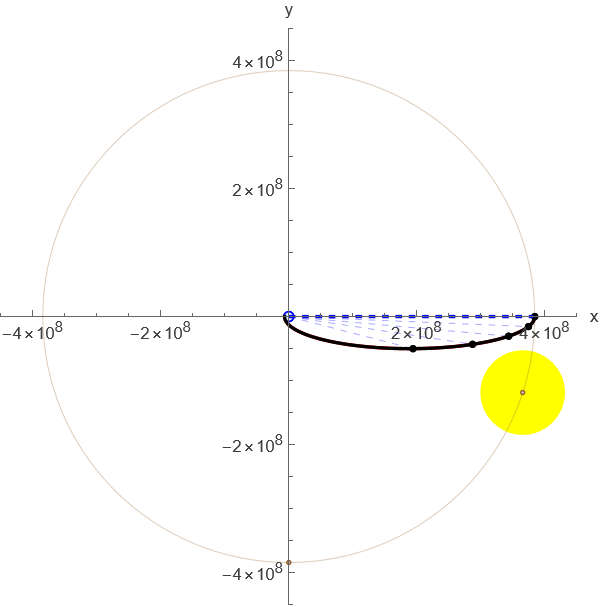

In [908]:
ThetaMoon = -0.1 Pi;

xMoon = SMAMoon Cos[ThetaMoon];
yMoon = SMAMoon Sin[ThetaMoon];
PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{xMoon,yMoon},RadiusMoon]} ,Axes->True];
PLOTMoonDisk = Graphics[{LightBrown,Disk[{xMoon,yMoon},RadiusMoon]} ];
PLOTSOIMoon = Graphics[{Yellow,Disk[{xMoon,yMoon},SOIMoon]}];
PLOTMoon = Show[PLOTSOIMoon,PLOTMoonEdge,PLOTMoonDisk];

PlotNumerAll2  =Show[PLOTEarth,PLOTMoon,PLOTAnalytAll,PLOTSatelliteTraj,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}]

We can now arbitrarily place the Moon at $\theta_{\mathrm{Moon}} = 0$ rad at SOI entry:

-Graphics-
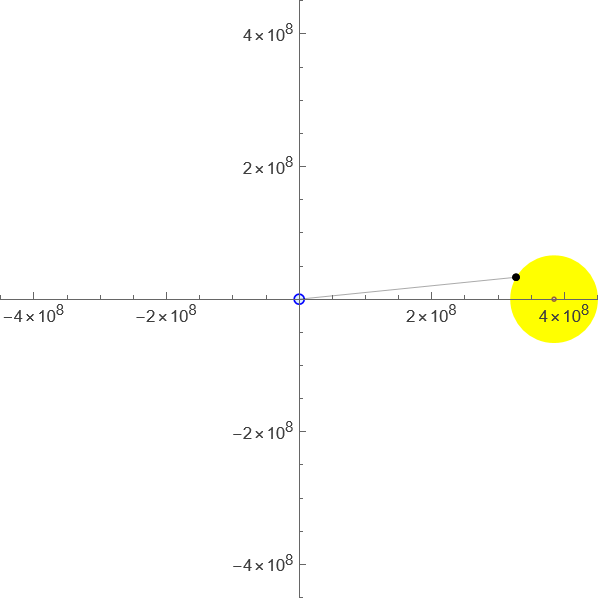

In [920]:
PLOTEarthEdge = Graphics[{Blue,Thick,Circle[{0,0},RadiusEarth]} ,Axes->True];
PLOTEarthDisk = Graphics[{LightBlue,Disk[{0,0},RadiusEarth]} ];
PLOTEarth = Show[PLOTEarthEdge,PLOTEarthDisk];

ThetaMoon = 0 Pi;
xMoon = SMAMoon Cos[ThetaMoon];
yMoon = SMAMoon Sin[ThetaMoon];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{xMoon,yMoon},RadiusMoon]} ,Axes->True];
PLOTMoonDisk = Graphics[{LightBrown,Disk[{xMoon,yMoon},RadiusMoon]} ];
PLOTSOIMoon = Graphics[{Yellow,Disk[{xMoon,yMoon},SOIMoon]}];
PLOTMoon = Show[PLOTSOIMoon,PLOTMoonEdge,PLOTMoonDisk];

PlotEarthMoon1 = Show[PLOTEarth,PLOTMoon,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}];

PLOTSOIrSC1Point = ListPolarPlot[{{gammaSC1[30 (Pi/180)],rSC1[30 (Pi/180)]}},PlotStyle->Black,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}];
PLOTSOIrSC1 = ListPolarPlot[{{0,0},{gammaSC1[30 (Pi/180)],rSC1[30 (Pi/180)]}},PlotStyle->{Black,Thin},Joined->True,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}];

PLOTAll1 =  Show[PlotEarthMoon1,PLOTSOIrSC1Point,PLOTSOIrSC1,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}]

### <a class="anchor" id="5.5.2_The_geocentric_departure_orbit"></a>  5.5.2 Example: Conditions at patch point

[Back to Table of Contents](#Table_of_Contents) 

At SOI entry, we have for the speed of the Moon and the selenocentric spacecraft speed:

In [938]:
vMoon
vSC2 [RadiusEarth + MyH0, vpAfter[384400 10^3, RadiusEarth + MyH0], 0, 30 (Pi/180)]

1018.3
928.292

We are now ready to compute the initial selenocentric velocity direction relative to the Moon's center, $\epsilon_2$: 

In [944]:
EpsSC2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0],0,30 (Pi/180)]

0.404057

Clearly, we will **not** obtain a head-on collision since that requires $\epsilon_2=0$. A strategy to identify possible solutions is to choose $\phi_0$ and only act on the parameter $\lambda_1$ by plotting $\epsilon_2=\epsilon_2(\lambda_1)$. The following plot (in degrees) is found with some trial and error: 

Clearly, we will **not** obtain a head-on collision since that requires $\epsilon_2=0$. A strategy, not used by Bate et al. due to the computational demand but easily handled by Mathematica, to identify possible solutions by only acting on the parameter $\phi_0$ is to plot $\epsilon_2=\epsilon_2(\phi_0)$. The following plot (in degrees) is quickly found: 

-Graphics-
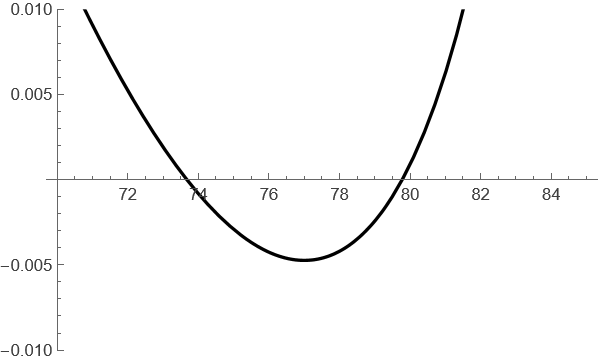

In [953]:
PLOTEpsSC21=Plot[EpsSC2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0], 0, lambda1 (Pi/180)],{lambda1, 70, 85},PlotRange->{-0.01,0.01},PlotStyle->Black]

Visually, we can try:

In [958]:
EpsSC2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0], 0, 73.7 (Pi/180)]

-0.0000656441

The function `FindRoot` yields a very accurate solution:

In [963]:
FindRoot[EpsSC2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0], 0, lambda1Sol (Pi/180)] == 0, {lambda1Sol, 72}]
lambda1Sol1 = FindRoot[EpsSC2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0], 0, lambda1Sol (Pi/180)] == 0, {lambda1Sol, 72}] [[1,2]]

{lambda1Sol -> 73.675}
73.675

Therefore $\lambda_1 \simeq 73.7^0$ is a far better choice than out initial $30^0$ and we can iterate:

In [969]:
vMoon
vSC2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0], 0, lambda1Sol1 (Pi/180)]
EpsSC2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0], 0, lambda1Sol1 (Pi/180)]

1018.3
815.428
          -16
-1.3942 10

We can now recalculate $\gamma_1$: 

In [976]:
gammaSC1[lambda1Sol1 (Pi/180)](180/Pi)

9.85026

### <a class="anchor" id="5.5.3_Selenocentric_arrival_orbit"></a>  5.5.3 Example: Selenocentric arrival orbit

[Back to Table of Contents](#Table_of_Contents) 

We can now verify the trajectory in the selenocentric reference frame:  

In [981]:
SpecEnergySC2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0],0,73.7 (Pi/180)] 

SpecAngMomSC2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0],0,73.7 (Pi/180)]

SemiLatus2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0],0,73.7 (Pi/180)]

Eccentricity2 [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0],0,73.7 (Pi/180)]

rPerilune [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0],0,73.7 (Pi/180)]  

vPerilune [RadiusEarth + MyH0, vpAfter[384400 10^3,RadiusEarth + MyH0],0,73.7 (Pi/180)]

258364.
           6
-3.54255 10
2.55969
1.
1.27985
          6
2.76795 10

Since $r_{\mathrm{Perilune}} \simeq 1.5\, {\mathrm{m}}\ll R_M$, we now have a collision.

The revised geometry becomes, by placing the two side-by-side diagrams for a better comparison between the initial guess and the final result:

-Graphics-
-Graphics-
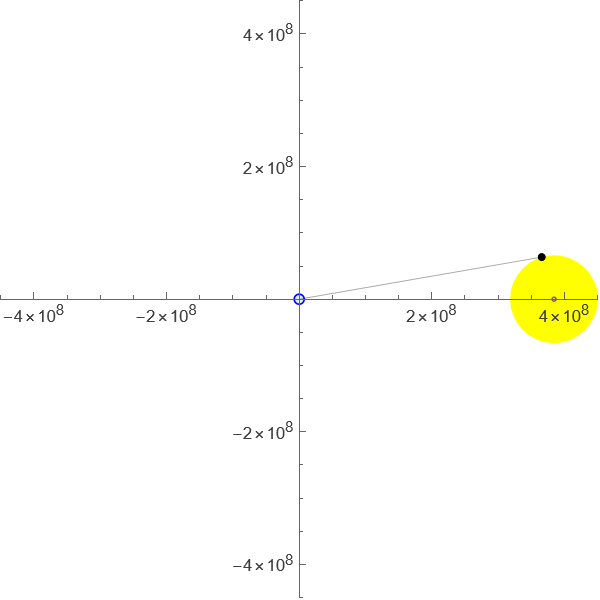
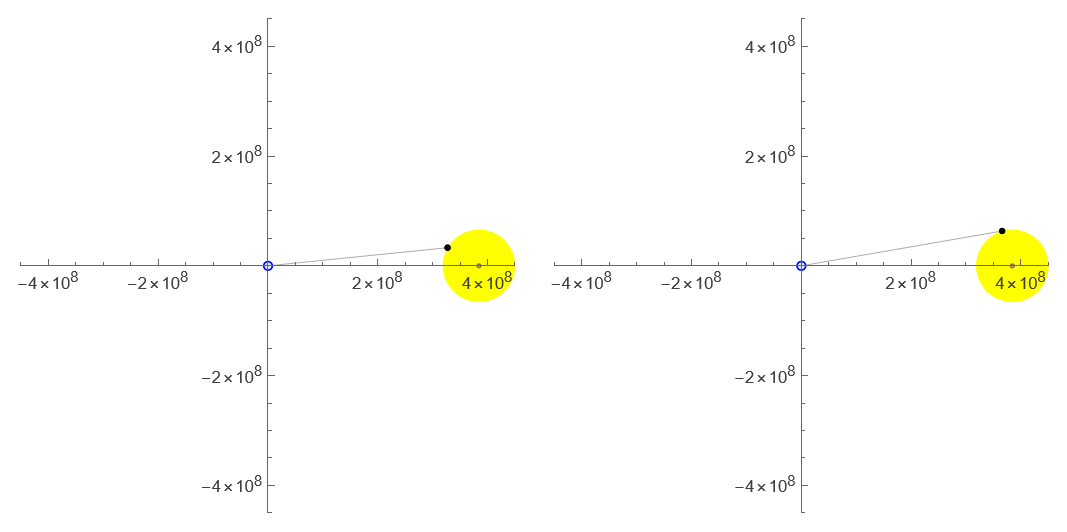

In [995]:
PLOTEarthEdge = Graphics[{Blue,Thick,Circle[{0,0},RadiusEarth]} ,Axes->True];
PLOTEarthDisk = Graphics[{LightBlue,Disk[{0,0},RadiusEarth]} ];
PLOTEarth = Show[PLOTEarthEdge,PLOTEarthDisk];

ThetaMoon = 0 Pi;
xMoon = SMAMoon Cos[ThetaMoon];
yMoon = SMAMoon Sin[ThetaMoon];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{xMoon,yMoon},RadiusMoon]} ,Axes->True];
PLOTMoonDisk = Graphics[{LightBrown,Disk[{xMoon,yMoon},RadiusMoon]} ];
PLOTSOIMoon = Graphics[{Yellow,Disk[{xMoon,yMoon},SOIMoon]}];
PLOTMoon = Show[PLOTSOIMoon,PLOTMoonEdge,PLOTMoonDisk];

PlotEarthMoon1 = Show[PLOTEarth,PLOTMoon,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}];

PLOTSOIrSC1Point = ListPolarPlot[{{gammaSC1[lambda1Sol1 (Pi/180)],rSC1[lambda1Sol1 (Pi/180)]}},PlotStyle->Black,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}];
PLOTSOIrSC1 = ListPolarPlot[{{0,0},{gammaSC1[lambda1Sol1 (Pi/180)],rSC1[lambda1Sol1 (Pi/180)]}},PlotStyle->{Black,Thin},Joined->True,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}];

PLOTAll2 = Show[PlotEarthMoon1,PLOTSOIrSC1Point,PLOTSOIrSC1,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}]

GraphicsRow[{PLOTAll1,PLOTAll2}]

### <a class="anchor" id="5.5.4_Time_from_TLI_burn_to_SOI"></a>  5.5.4 Example: Time from TLI burn to SOI

[Back to Table of Contents](#Table_of_Contents) 


As we have repeatedly seen, the flight time between two generic points along the orbit can be computed either directly, by numerical integration of the differential equations of motion, or analytically, by solving - also numerically - Kepler's transcendental equation. In this case, let us use the the purely numerical integration method by setting up syntax already seen in the first part of this document and using the initial perigee orbit altitude of the example above:

In [1014]:
SpecAngMomenIn [ra_,rp_]= Sqrt[kEarth SemiMajor[ra,rp] (1-(Eccentricity[ra,rp])^2) ];
vt0In[ra_,rp_]=(SpecAngMomenIn [ra,rp])/rp; 

In [1016]:
r0 = RadiusEarth + MyH0
vt0 = vt0In[SMAMoon,(RadiusEarth + MyH0)]

6
6.55483 10
10935.3

The final time coud be found by defining a function with a stopping condition but her we shall simply solve by trial and error by finding the time for which `rSolNum` becomes equal to $r_1$. That time clearly precedes $t_{\mathrm{fin}} = 4\, {\mathrm{d}}$, so integrate to that time and query the solution for earlier times: 

In [1022]:
tfin = 4 86400

345600

{0., {{r -> InterpolatingFunction[{{0., 345600.}}, <>]}}}
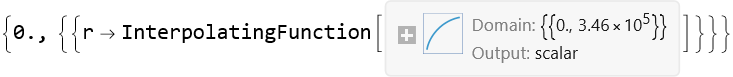

In [1023]:
Clear[SolKeplerRad,r]

Timing[SolKeplerRad =NDSolve[{r''[t] == (SpecAngMomenIn [SMAMoon,(RadiusEarth + MyH0)])^2 (1/(r[t])^3) - (kEarth/(r[t])^2) ,r[0]==r0,r'[0]==+0.},r,{t,0,tfin},AccuracyGoal->15,PrecisionGoal->15,MaxSteps-> ∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

In [1025]:
rSolNum[t_] = Evaluate[r[t] /. SolKeplerRad][[1]];

rDotSolNum[t_] = Evaluate[r'[t] /. SolKeplerRad][[1]];

ThetaAngDotNum[t_] = (SpecAngMomenIn [SMAMoon,(RadiusEarth + 185. 10^3)])(1/(rSolNum[t])^2);
vtSolNum[t_] = ThetaAngDot[t]rSolNum[t]; 

VSolNum[t_] = Sqrt[((vtSolNum[t])^2)+((rDotSolNum[t])^2)];

By trial and error, we find:

In [1034]:
DeltatTLI = 3.82245 86400
rSolNum[DeltatTLI]

330260.
         8
3.7127 10

In [1036]:
rSC1[lambda1Sol1 (Pi/180)]

8
3.7127 10

To within the first six significant digits, we find that $\Delta t_{\mathrm{TLI}} \simeq 3.82245\times 86400$ s = $3.30260 \times 10^5$ s. 

Now we can calculate the total angle swept by the radius vector of the spacecraft while traveling along the TLO, sometimes referred to as the *geocentric sweep angle*, $\psi$:

{{ThetaAng -> InterpolatingFunction[{{0., 345600.}}, <>]}}
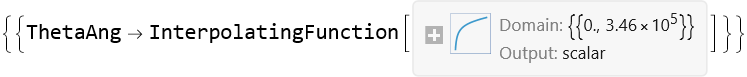

In [1041]:
Clear[SolKeplerAng]

SolKeplerAng =NDSolve[{ThetaAng'[t] == (SpecAngMomenIn [SMAMoon,(RadiusEarth + MyH0)])(1/(rSolNum[t])^2) ,ThetaAng[0]==Pi},ThetaAng,{t,0,tfin},AccuracyGoal->15,PrecisionGoal->15,MaxSteps->∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]

The true anomaly of the spacecraft at SOI is:

InterpolatingFunction[{{0., 345600.}}, <>][t]
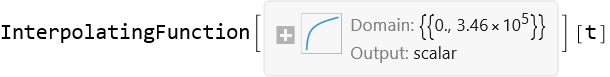

In [1047]:
ThetaAngSolNum[t_] = Evaluate[ThetaAng[t] /. SolKeplerAng][[1]]

Thus the difference in the true anomaly of the spacecraft between burn to TOI and arrival at SOI (what Bate et al. refer to as $\nu_1-\nu_0$) is:

In [1052]:
(*this is the true anomaly at SOI entry*)
ThetaAngSolNum[DeltatTLI]

6.23364

We now subtract the initial true anomaly, $\nu_0 = \pi$, to find them sweep angle $\psi$:

In [1058]:
(*this is the difference, $\nu_1-\nu_0$*)
ThetaAngSolNum[DeltatTLI] - Pi

3.09205

The mean motion of the Moon, $\omega_{\mathrm{Moon}}$, during the spacecraft motion along the TLO is, from our simplifying assumptions regarding the motion of the Moon:

In [1064]:
OmegaMoon = Sqrt[kEarth/((SMAMoon)^3)] 

-6
2.64907 10

So that the mean anomaly of the Moon, is (here we indicate this as $\Delta\theta_{\mathrm{Moon}}$ to avoid confusion with the lunar mass):

$$
\Delta\theta_{\mathrm{Moon}} = \omega_{\mathrm{Moon}} \Delta t_{\mathrm{TLI}}\, .
$$

In [1069]:
MeanAnomalyMoon = OmegaMoon DeltatTLI

0.874882

Therefore, from Bate et al., Eq. (7.4-16), the phase angle at departure is:

In [1074]:
gamma0 = (ThetaAngSolNum[DeltatTLI] - Pi) - MeanAnomalyMoon - gammaSC1[lambda1Sol1 (Pi/180)]

2.04525

Summarizing the final geometry:

In [1079]:
ThetaAngSolNum[DeltatTLI]
gammaSC1[lambda1Sol1 (Pi/180)]

6.23364
0.171919

Now we can plot the position of the Moon at TLI and at SOI. Notice the following points:

**1.** The true anomaly of the Moon at TLI, $\theta_{M, 0}$ (indicated by `PhaseMoon0`), is:

$$
\theta_{M, 0} = \nu_1 - \gamma_1 - \Delta\theta_{\mathrm{Moon}}\, .
$$

**2.** The true anomaly of the Moon at SOI, $\theta_{M, 1}$ (indicated by `ThetaMoon2` below), is:

$$
\theta_{M, 1} = \theta_{M, 0} + \Delta\theta_{\mathrm{Moon}} = \nu_1 - \gamma_1\, .
$$

5.18684
-Graphics-
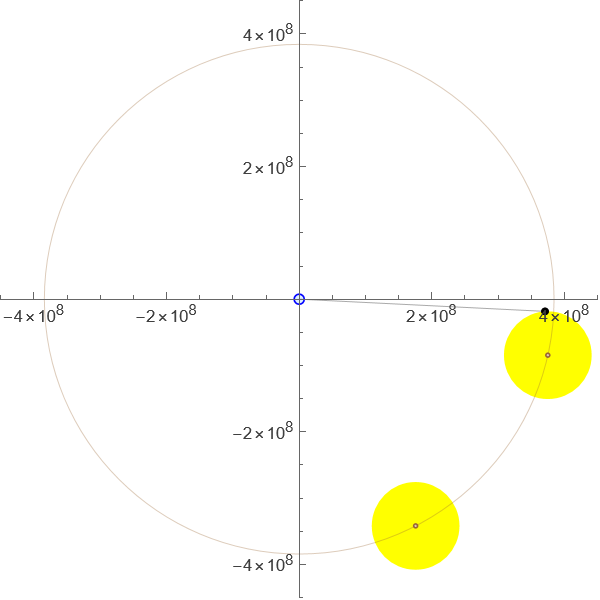

In [1085]:
PLOTEarthEdge = Graphics[{Blue,Thick,Circle[{0,0},RadiusEarth]} ,Axes->True];
PLOTEarthDisk = Graphics[{LightBlue,Disk[{0,0},RadiusEarth]} ];
PLOTEarth = Show[PLOTEarthEdge,PLOTEarthDisk];

(*initial position of the Moon at TLI for a burn with $\nu_0 = \pi$*) 
PhaseMoon0 = ThetaAngSolNum[DeltatTLI] - gammaSC1[lambda1Sol1 (Pi/180)] - MeanAnomalyMoon
xMoon1 = SMAMoon Cos[PhaseMoon0];
yMoon1 = SMAMoon Sin[PhaseMoon0];

PLOTMoonEdge1 = Graphics[{Brown,Thick,Circle[{xMoon1,yMoon1},RadiusMoon]} ,Axes->True];
PLOTMoonDisk1 = Graphics[{LightBrown,Disk[{xMoon1,yMoon1},RadiusMoon]} ];
PLOTSOIMoon1 = Graphics[{Yellow,Disk[{xMoon1,yMoon1},SOIMoon]}];
PLOTMoon1 = Show[PLOTSOIMoon1,PLOTMoonEdge1,PLOTMoonDisk1];

PlotEarthMoon1 = Show[PLOTEarth,PLOTMoon1,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}];

(*position of the Moon at SOI: PhaseMoon0 + MeanAnomalyMoon*)
ThetaMoon2 = -(gammaSC1[lambda1Sol1 (Pi/180)] - ThetaAngSolNum[DeltatTLI]);
xMoon2 = SMAMoon Cos[ThetaMoon2];
yMoon2 = SMAMoon Sin[ThetaMoon2];
PLOTMoonEdge2 = Graphics[{Brown,Thick,Circle[{xMoon2,yMoon2},RadiusMoon]} ,Axes->True];
PLOTMoonDisk2 = Graphics[{LightBrown,Disk[{xMoon2,yMoon2},RadiusMoon]} ];
PLOTSOIMoon2 = Graphics[{Yellow,Disk[{xMoon2,yMoon2},SOIMoon]}];
PLOTMoon2 = Show[PLOTSOIMoon2,PLOTMoonEdge2,PLOTMoonDisk2,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}];


PLOTSOIrSC1Point = ListPolarPlot[{{ThetaAngSolNum[DeltatTLI],rSC1[lambda1Sol1 (Pi/180)]}},PlotStyle->Black,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}];
PLOTSOIrSC1 = ListPolarPlot[{{0,0},{ThetaAngSolNum[DeltatTLI],rSC1[lambda1Sol1 (Pi/180)]}},PlotStyle->{Black,Thin},Joined->True,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}}];

PLOTMoonOrbit = Graphics[{Brown,Thin,Circle[{0,0},SMAMoon]} ,Axes->True];

PLOTAll2 = Show[PLOTMoon2,PlotEarthMoon1,PLOTSOIrSC1Point,PLOTSOIrSC1,PLOTMoonOrbit,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}},Axes->True]



### <a class="anchor" id="5.5.5_Geocentric_2B_solution"></a>  5.5.5 Example: Geocentric $2$-body solution 

[Back to Table of Contents](#Table_of_Contents)  

We can now plot the numerical solution of the $2$-body problem obtained in the patch conic approximation. Notice that this numerical solution is not the full $3$-body solution and it could be equally obtained analytically:

In [1117]:
xSolNum[t_] = rSolNum[t] Cos[ThetaAngSolNum[t]];
ySolNum[t_] = rSolNum[t] Sin[ThetaAngSolNum[t]];

-Graphics-
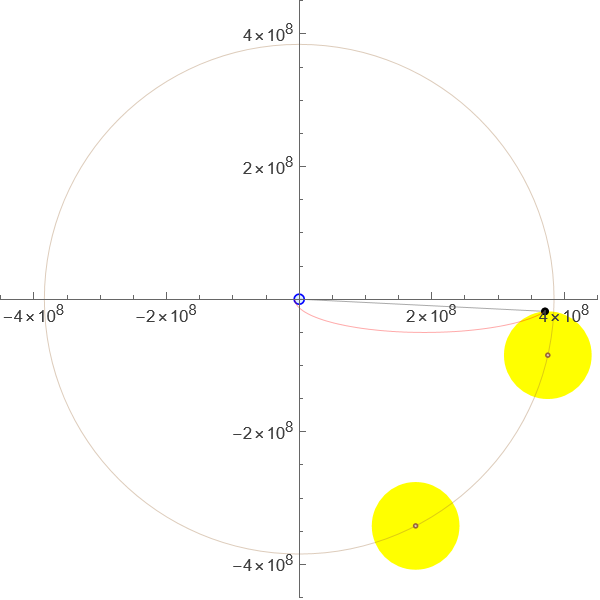

In [1119]:
PLOTSatelliteTraj = ParametricPlot[{xSolNum[t],ySolNum[t]},{t,0, DeltatTLI},Axes->True,AxesLabel->{x,y},PlotStyle->{Red,Thin}];

PLOTAll2 = Show[PLOTMoon2,PlotEarthMoon1,PLOTSOIrSC1Point,PLOTSOIrSC1,PLOTMoonOrbit,PLOTSatelliteTraj,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}},Axes->True]

### <a class="anchor" id="5.5.6_Selenocentric_trajectory"></a>  5.5.6 Example: Selenocentric trajectory

[Back to Table of Contents](#Table_of_Contents)  

Let us define the position of the Moon as a function of time starting from its initial position found above:

In [1125]:
PhaseMoon0 = ThetaAngSolNum[DeltatTLI] - gammaSC1[lambda1Sol1 (Pi/180)] - MeanAnomalyMoon

5.18684

Let us create a table of such positions at equidistant time intervals of $1$d: 

In [1130]:
xMoonTraj[t_] = SMAMoon Cos[(OmegaMoon t) + PhaseMoon0 ];
yMoonTraj[t_] = SMAMoon Sin[(OmegaMoon t) + PhaseMoon0 ];

MoonTrajList = Table[{xMoonTraj[i 86400],yMoonTraj[i 86400]}, {i, -1, 6}];

Such positions are marked as small brown points, commencing one day before TLI and continuing to one day after. Notice that the SOI of the Moon is only indicated at TLI and at SOI:

-Graphics-
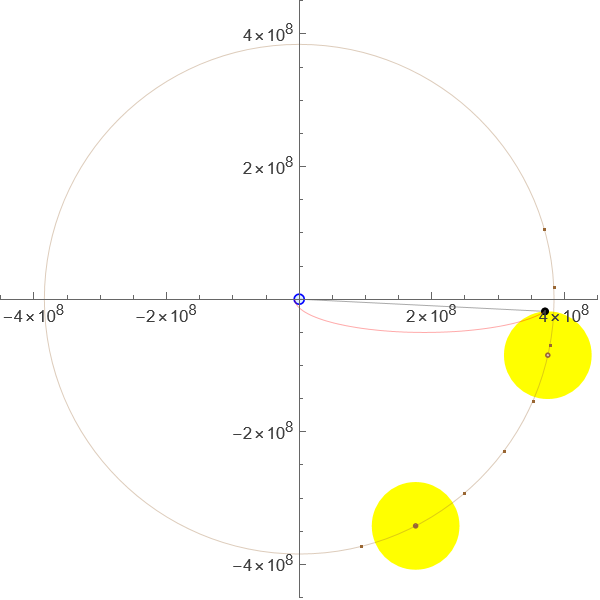

In [1137]:
PLOTMoonTraj = ListPlot[MoonTrajList,Axes->True,PlotMarkers->None, Joined->False,PlotStyle->{Brown,PointSize[Small]},PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}},AspectRatio->1];

PLOTAll2 = Show[PLOTMoon2,PlotEarthMoon1,PLOTSOIrSC1Point,PLOTSOIrSC1,PLOTMoonOrbit,PLOTSatelliteTraj,PLOTMoonTraj,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}},Axes->True]

Let us calculate the position of the spacecraft in the selenocentric reference frame. In what follows, we are not considering any fictitious forces due expected in a rotating reference frame and we consider the position of the spacecraft in an instantaneously inertial reference frame located at the position of the Moon: 

In [1143]:
DeltatTLI

330260.

In [1144]:
xSolNumSel[t_] = xSolNum[t] - xMoonTraj[t];
ySolNumSel[t_] = ySolNum[t] - yMoonTraj[t];

-Graphics-
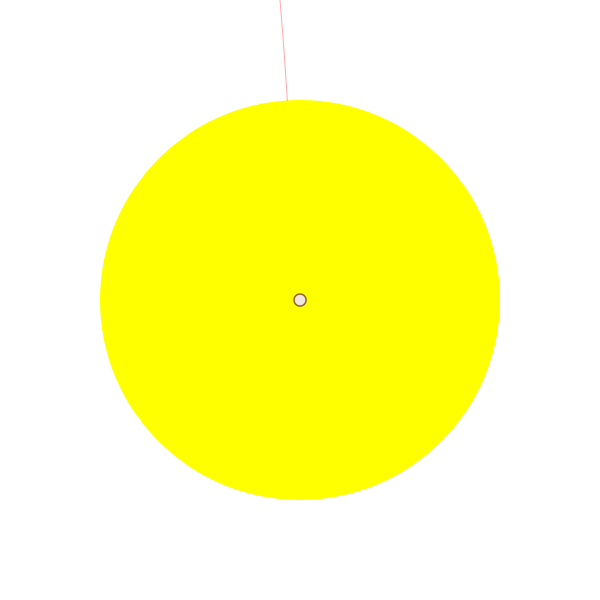

In [1146]:
PLOTMoonEdge3 = Graphics[{Brown,Thick,Circle[{0,0},RadiusMoon]} ,Axes->True];
PLOTMoonDisk3 = Graphics[{LightBrown,Disk[{0,0},RadiusMoon]} ];
PLOTSOIMoon3 = Graphics[{Yellow,Disk[{0,0},SOIMoon]}];
PLOTMoon3 = Show[PLOTSOIMoon3,PLOTMoonEdge3,PLOTMoonDisk3,PlotRange->{{- 1.5 SOIMoon, 1.5 SOIMoon},{- 1.5 SOIMoon,1.5 SOIMoon}}];

PLOTSatelliteTraj = ParametricPlot[{xSolNumSel[t],ySolNumSel[t]},{t,0, DeltatTLI},Axes->True,AxesLabel->{x,y},PlotStyle->{Red,Thin},PlotRange->{{- 1.5 SOIMoon, 1.5 SOIMoon},{- 1.5 SOIMoon,1.5 SOIMoon}},AspectRatio->1];

PLOTAll4 = Show[PLOTMoon3,PLOTSatelliteTraj]

The selenocentric coordinates of the spacecraft at SOI entry are:

In [1156]:
xSOISel = xSolNum[DeltatTLI]  - xMoonTraj[DeltatTLI]
ySOISel = ySolNum[DeltatTLI]  - yMoonTraj[DeltatTLI]

6
-4.19736 10
          7
6.60497 10

-Graphics-
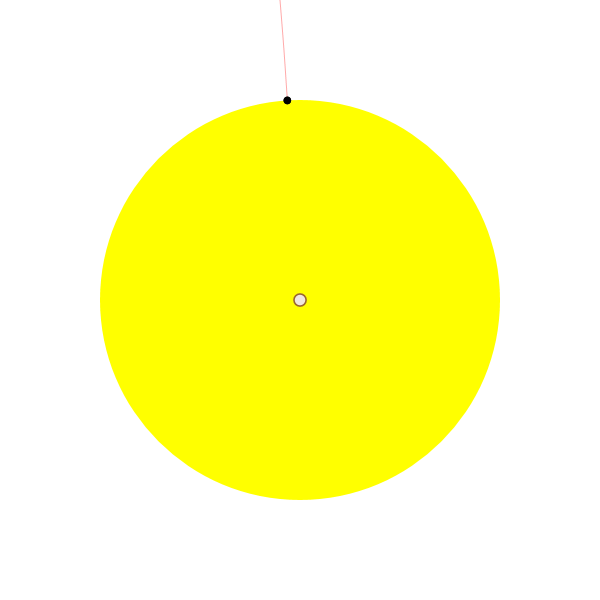

In [1158]:
PLOTSOISel = ListPlot[{{xSOISel,ySOISel}},PlotStyle->Black,PlotRange->{{- 1.5 SOIMoon, 1.5 SOIMoon},{- 1.5 SOIMoon,1.5 SOIMoon}}];

PLOTAll5 = Show[PLOTMoon3,PLOTSatelliteTraj,PLOTSOISel]

It is obvious from this image but especially from the estimate of the perilune above that a "head-on" collision is predicted by the patched-conic approximation. 

### <a class="anchor" id="5.5.7_Restricted_3B-problem"></a>  5.5.7 Example: The restricted $3$-body problem

[Back to Table of Contents](#Table_of_Contents)  

This section is devoted to analyzing the same problem above by solving the *restricted $3$-body problem* so that you can appreciate the accuracy of the patched-conic approximation in this particular case. In this type of problem, the gravitational force of *both* the Earth *and* the Moon upon the spacecraft are considered, although the spacecraft has no effect on the motion of either major bodies. This problem cannot, in general, be solved analytically so we treat numerically. Since we have no longer any useful symmetry, we shall use Cartesian coordinates. 

The code below stops when either of two conditions are satisfied: 

**Condition 1.** A maximum time `tint` is reached. 

**Condition 2.** The spacecraft collides anywhere with the Moon. 

If Condition 2 is satisfied, the code prints out the time elapsed from TLI to the instant of collision. 

We shall no dwell on the details of the Mathematica syntax in this more complex case but details about the instructions below are available in the Wolfram Documentation.  

{{xs -> InterpolatingFunction[{{0., 386320.}}, <>], 
 
>    ys -> InterpolatingFunction[{{0., 386320.}}, <>]}}
{InterpolatingFunction[{{0., 386320.}}, <>][t], 
 
>   InterpolatingFunction[{{0., 386320.}}, <>][t]}
386320.
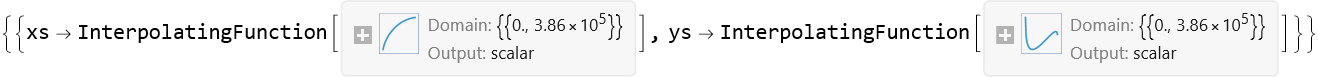
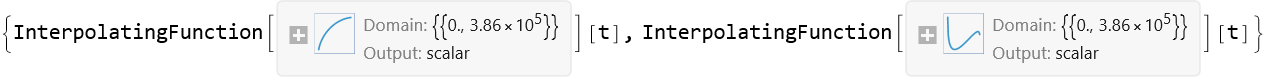

In [1168]:
(* redefine variables  *)

Clear[tend]

tInt = 800000;

rEarthSC[xs_, ys_, t_] = Sqrt[(xs[t])^2 + (ys[t])^2];
rMoonSC[xs_, ys_, t_] = Sqrt[(xs[t] - xMoonTraj[t])^2 + (ys[t]- yMoonTraj[t])^2];
S=NDSolve[{xs''[t] == - (kEarth/(rEarthSC[xs, ys, t])^3) (xs[t]) - (kMoon/(rMoonSC[xs, ys, t])^3) (xs[t] - xMoonTraj[t]), 
     ys''[t] == - (kEarth/(rEarthSC[xs, ys, t])^3) (ys[t]) - (kMoon/(rMoonSC[xs, ys, t])^3) (ys[t]- yMoonTraj[t]), 
     xs[0] == -r0, ys[0] == 0, xs'[0] == 0, ys'[0] == -vt0}, {xs, ys}, {t, tInt }, 
     Method -> {"EventLocator", 
      "Event" :> Abs[Sqrt[(xs[t] - xMoonTraj[t])^2 + (ys[t]- yMoonTraj[t])^2]] - RadiusMoon, 
      "Direction" -> -1, 
      "EventLocationMethod" -> "LinearInterpolation", 
      "EventAction" :> Throw[tend = t, "StopIntegration"]}]
Sol1 = {xs[t], ys[t]} /. First[S]
tend

The geocentric solution is:

-Graphics-
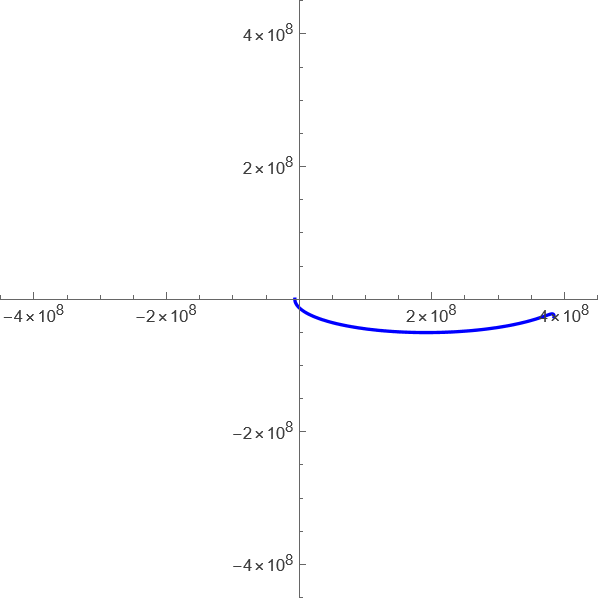

In [1180]:
PLOTSC3BP1 = 
  ParametricPlot[{Sol1[[1]], Sol1[[2]]}, {t, 0, tend }, 
   DisplayFunction -> Identity, PlotStyle -> {Thick, Blue},PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}},AspectRatio->1] 

Let us show this result along with the patched-conic approximation and the numerical integration of the $2$-body problem from TLI to lunar SOI. 

-Graphics-
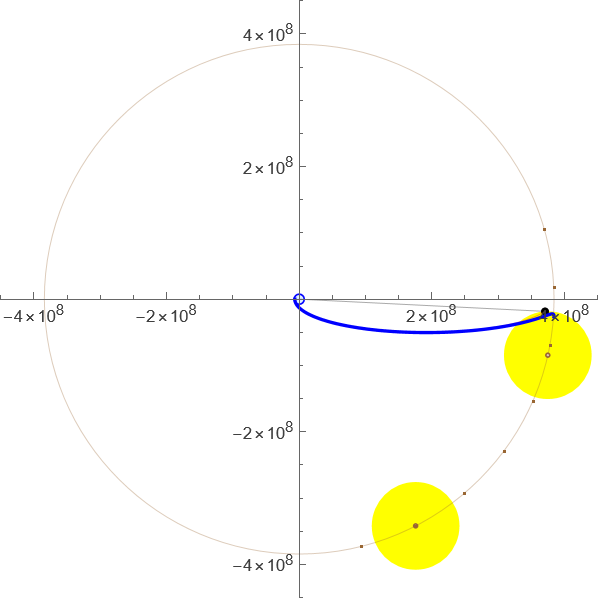

In [1185]:
PLOTAll3 = Show[PLOTAll2,PLOTSC3BP1,PlotRange->{{- 4.5 10^8,4.5 10^8},{-4.5 10^8,4.5 10^8}},Axes->True]

Notice, at least at the qualitative level, that the accurate numerical solution closely follows the patched-conic approximation over the entire trajectory with a minor discrepancy only as the SOI of the Moon is approached, as expected. Let us now transform the numerical result to selenocentric coordinates:

In [1190]:
xSol3BP[t_] = Sol1[[1]];
ySol3BP[t_] = Sol1[[2]];

In [1192]:
xSol3BPSel[t_] = xSol3BP[t] - xMoonTraj[t];
ySol3BPSel[t_] = ySol3BP[t] - yMoonTraj[t];

-Graphics-
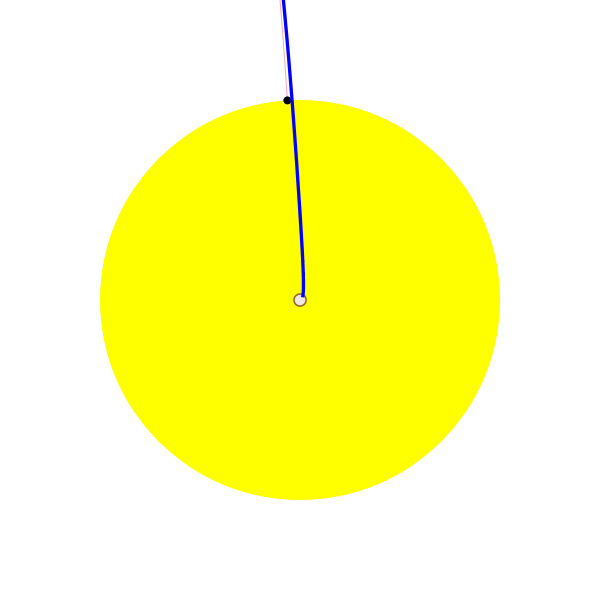

In [1194]:
PLOT3BPSCSel = ParametricPlot[{xSol3BPSel[t],ySol3BPSel[t]},{t,0, tend},Axes->True,AxesLabel->{x,y},PlotStyle->{Blue,Thick},PlotRange->{{- 1.5 SOIMoon, 1.5 SOIMoon},{- 1.5 SOIMoon,1.5 SOIMoon}},AspectRatio->1];

PLOTAll6 = Show[PLOTAll5,PLOT3BPSCSel]

Let us zoom in to analyze the impact in detail:

-Graphics-
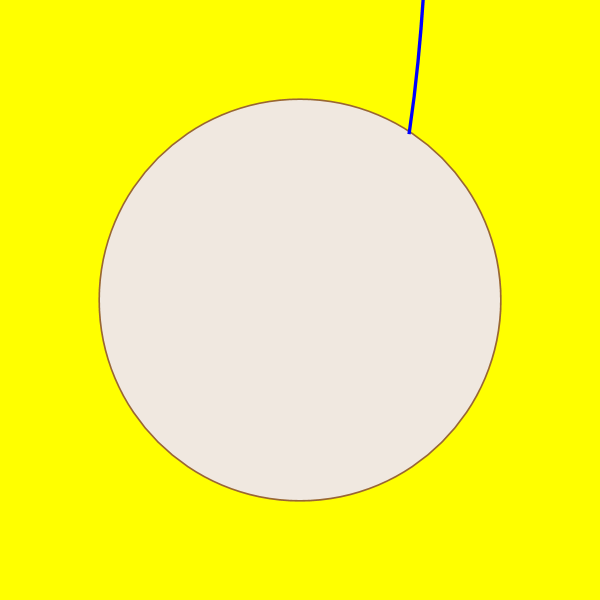

In [1200]:
PLOTAll6B = Show[PLOTAll5,PLOT3BPSCSel,PlotRange->{{- 1.5 RadiusMoon, 1.5 RadiusMoon},{- 1.5 RadiusMoon,1.5 RadiusMoon}},AspectRatio->1]

Although the accurate numerical solution of the $3$-body problem shows that we do not have a "head-on" collision, we can still see that the patched-conic approximation correctly predicted a collision with the parameters given. Therefore, the patched conic approximation is a valid approach to restrict the parameters to be used for a more refined numerical solution.  

-Graphics-
-Graphics-
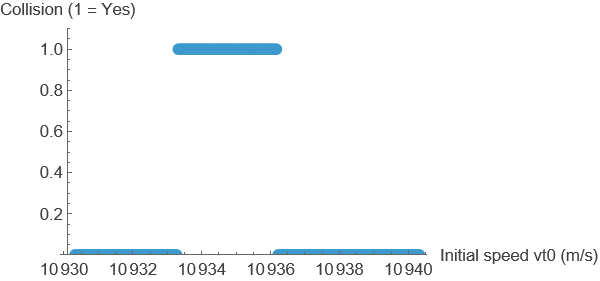
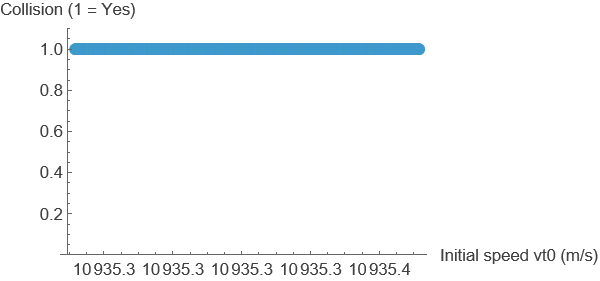

In [1205]:
Clear[solveSCEvent, collisionQ]

solveSCEvent[vt0_?NumericQ] :=
 Module[{collision = False},Quiet[NDSolve[
 {xs''[t] == -(kEarth/(Sqrt[xs[t]^2 + ys[t]^2])^3) xs[t]-(kMoon/(Sqrt[(xs[t] - xMoonTraj[t])^2 +   (ys[t] - yMoonTraj[t])^2])^3)(xs[t] - xMoonTraj[t]),
ys''[t] ==-(kEarth/(Sqrt[xs[t]^2 + ys[t]^2])^3) ys[t] -(kMoon/(Sqrt[(xs[t] - xMoonTraj[t])^2 + (ys[t] - yMoonTraj[t])^2])^3)(ys[t] - yMoonTraj[t]),
 xs[0] == -r0, ys[0] == 0, xs'[0] == 0,  ys'[0] == -vt0},{xs, ys}, {t, 0, tInt},
    Method -> {"EventLocator","Event" :>(Sqrt[(xs[t] - xMoonTraj[t])^2 + (ys[t] - yMoonTraj[t])^2] - RadiusMoon),
      "Direction" -> -1, "EventAction" :> (collision = True; "StopIntegration")},
    MaxStepSize -> 50,AccuracyGoal -> 8, PrecisionGoal -> 8],{NDSolve::evcvmit}]; collision]

collisionQ[vt0_?NumericQ] := solveSCEvent[vt0]
vt0Nominal = vt0;
vt0Range = vt0Nominal + Range[-5, 5, 0.05];

collisionResults =Table[{vtest, collisionQ[vtest]}, {vtest, vt0Range}];

CollisionPlot = ListPlot[collisionResults /. {v_, True} -> {v, 1} /. {v_, False} -> {v, 0},
  AxesLabel -> {"Initial speed vt0 (m/s)", "Collision (1 = Yes)"},PlotRange -> {0, 1.1},PlotMarkers -> Automatic]

vt0RangeFine = vt0Nominal + Range[-0.05, 0.05, 0.0001];

collisionResultsFine =Table[{vtest, collisionQ[vtest]}, {vtest, vt0RangeFine}];

ListPlot[ collisionResultsFine /. {v_, True} -> {v, 1} /. {v_, False} -> {v, 0}, AxesLabel -> {"Initial speed vt0 (m/s)", "Collision (1 = Yes)"},
  PlotRange -> {0, 1.1}, PlotMarkers -> Automatic]

In [1215]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-5-fig-9-cOLLISION.svg",CollisionPlot]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/kaoutar-ammara-report-section-5-fig-9-c\
 
>   OLLISION.svg

In [1216]:
collisionVelocities =Select[collisionResults, #[[2]] === True &][[All, 1]];
If[collisionVelocities =!= {},
  {vmin, vmax} = {Min[collisionVelocities], Max[collisionVelocities]};
  Print["Collision window: ", vmin, " < vt0 < ", vmax],
  Print["No collision detected in scanned velocity range."]]

Collision window: 10933.3 < vt0 < 10936.2


Near the boundary between collision and non-collision trajectories, the numerical event locator issues convergence warnings. These occur when the spacecraft trajectory becomes nearly tangent to the lunar surface, causing the event function to have a very small slope at the zero crossing. Such warnings are therefore expected and physically meaningful, indicating extreme sensitivity of the collision condition to initial velocity.

### <a class="anchor" id="5.6_Your_case"></a>  5.6 Your case

[Back to Table of Contents](#Table_of_Contents) 

At this point, you can return to [Sec. 4](#4._Earth-Moon_spacecraft), enter your number into `SeedRandom`, and obtain your value of $H_0$. Run through all cells and collect the information needed to answer the questions below. It may be useful to monitor changes with respect to the "nominal" case we analyzed to ensure that no errors are being made.    

## <a class="anchor" id="6._Questions"></a> 6. Questions  

[Back to Table of Contents](#Table_of_Contents)  

Create a space below every question and answer them. If you need to open code cells, do so. 

**Regarding the application to UM5-EOSAT ([Sec. 3](#3._Application_of_Keplers_equation)):**

**1.** Prepare a table illustrating important facts about UM5-EOSAT, including its launch and its primary mission. 

| Parameter | Description |
|---------|-------------|
| Satellite Name | UM5-EOSAT |
| Launch Date | August 16, 2024 |
| Launch Vehicle | Falcon 9 (Transporter-11) |
| Launch Site | AIR FORCE WESTERN TEST RANGE (AFWTR) |
| Primary Mission | Earth observation / Remote sensing |
| Orbit Type | Low Earth Orbit (LEO) |
| Operator | Mohammed V University (UM5) |


**2.** Display the latest available orbital elements. 

{Epoch -> DateObject[{2025, 12, 20, 3, 59, 47}, Instant, Gregorian, 3.], 
 
                                     6
>   Semi-major axis (m) -> 6.93226 10 , Eccentricity -> 0.0007172, 
 
>   Inclination (deg) -> 97.7043 degrees, RAAN (deg) -> 69.8943 degrees, 
 
>   Argument of perigee (deg) -> 357.861 degrees, Mean anomaly (deg) -> 2.2577}
   Parameter
    
   >    Value
   Epoch                       DateObject[{2025, 12, 20, 3, 59, 47}, Instant, Gregorian, 
    
   >    3.]


   Semi-major axis (m)
    
                  6
   >    6.93226 10

   Eccentricity
    
   >    0.0007172

   Inclination (deg)
    
   >    97.7043 degrees

   RAAN (deg)
    
   >    69.8943 degrees

   Argument of perigee (deg)
    
   >    357.861 degrees

   Mean anomaly (deg)
    
   >    2.2577
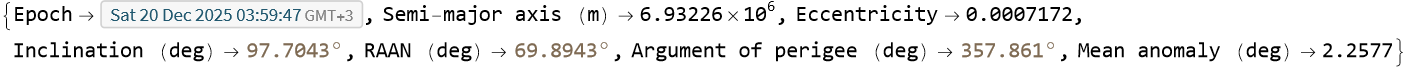
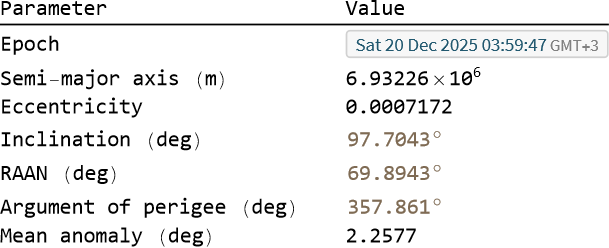

In [1230]:
(* Epoch *)
UM5EOSAT60555TLEEpoch =UM5EOSAT60555TLE[[6, 2, 1]];

(* Inclination (deg) *)
UM5EOSAT60555TLEInc = UM5EOSAT60555TLE[[11, 2, 1]];

(* RAAN (deg) *)
UM5EOSAT60555TLERAAN = UM5EOSAT60555TLE[[12, 2, 1]];

(* Argument of Perigee (deg) *)
UM5EOSAT60555TLEArgPer = UM5EOSAT60555TLE[[14, 2, 1]];

OrbParams= {"Epoch" -> UM5EOSAT60555TLEEpoch,
 "Semi-major axis (m)" -> UM5EOSAT60555TLESemiMajor,
 "Eccentricity" -> UM5EOSAT60555TLEEcc,
 "Inclination (deg)" -> UM5EOSAT60555TLEInc,
 "RAAN (deg)" -> UM5EOSAT60555TLERAAN,
 "Argument of perigee (deg)" -> UM5EOSAT60555TLEArgPer,
 "Mean anomaly (deg)" -> UM5EOSAT60555TLEMeanAnomaly 180/Pi}

OrbParamsTable = TableForm[OrbParams /. Rule -> List, TableHeadings -> {None, {"Parameter", "Value"}}]



In [1240]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/UM5EOSAT-OrbitParameters.svg",OrbParamsTable]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/UM5EOSAT-OrbitParameters.svg

**3.** Display the orbit in its plane by using the Mathematica `Export` instruction you already used in Project 1.  

In [1245]:
Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/UM5EOSAT-OrbitPlane.svg",PLOTUM5EOSATEpochAll]

C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/UM5EOSAT-OrbitPlane.svg

**4.** Display the path of the satellite from the initial epoch date to the time randomly assigned by `SeedRandom`. 

-Graphics-
C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/OrbitPlane.svg
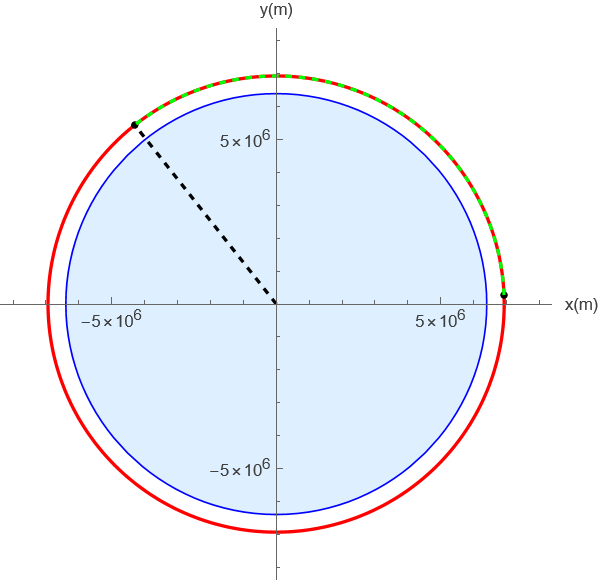

In [2236]:
Show[PlotUM5EOSATNumAll]

Export["C:/Users/akaou/OneDrive/Desktop/AE-311/Project-2/OrbitPlane.svg",PlotUM5EOSATNumAll]

**5.** Compute and show the absolute and relative discrepancies between the analytical and numerical methods and draw your conclusions in  Sec. [3.2.1](#3.2.1_Error_Analysis). Add both Markdown cells and Code cells where indicated as needed at the bottom of that Section.

Answered in corresponding section

**6.** Investigate the dependence of the above discrepancies on your choices of $x$ for `AccuracyGoal->x`, `PrecisionGoal->x` in the `NDSolve` function of the numerical approach. Do not try $x>16$ but try lower, integer values. What happens if you also decrease `AccuracyGoal->x`, `PrecisionGoal->x` in `FindRoot` when you solve Kepler's equation numerically? You can try to change those two cells as: 

`FindRoot[UM5EOSAT60555MeanAnomaly == EccAnomEpoch - UM5EOSAT60555Ecc Sin[EccAnomEpoch],{EccAnomEpoch,2.0}, AccuracyGoal->x, PrecisionGoal->x ][[1,2]]`

This was answer in section 3.2.2

**Regarding the application to the Hohmann transfer to lunar orbit ([Sec. 4](#4._Earth-Moon_spacecraft)):** 

*It may be useful to review Bate 1971 (Ch. 7, Secs. 1-3, included).*

**7.** Why does the Hohmann transfer travel time, perhaps counterintuitively, increase as a function of initial altitude?

The Hohmann transfer time is given by

$$
t_{\mathrm{Hoh}} = \frac{1}{2} T = \pi \sqrt{\frac{a^3}{k_{\oplus}}}
$$

where the semi-major axis of the transfer orbit is

$$
a = \frac{r_p + r_a}{2}
$$

As the initial altitude increases, the perigee radius \( r_p \) increases, which directly increases the semi-major axis \( a \). Since the period scales as \( a^{3/2} \), even moderate increases in \( r_p \) lead to a longer orbital period.

Physically, starting from a higher orbit reduces the orbital energy difference between Earth orbit and the translunar trajectory. The spacecraft therefore follows a larger, slower ellipse, spending more time reaching the Moon. Hence, although the spacecraft starts “closer” to the Moon, it moves more slowly along the transfer, resulting in a longer travel time.

**8.** Use all the above information to study a translunar trajectory departing from a geostationary orbit instead of a LEO. 

Determine $\Delta v$, $\Delta M$, $\dot{m}$, and $\Delta t_{\mathrm{burn}}$. 

In [1264]:
rGEO = 42164*10^3;          
raMoon = 384400*10^3;      (* Moon orbital radius *)
Is = 311;
M0 = 10*10^3;
FThrust = 100*10^3;

1053.08
2919.83
MassFlowRate[311, 100000]
         2919.83
-------------------------
MassFlowRate[311, 100000]
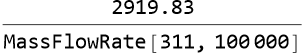

In [1269]:
DeltaVGEO = Deltav[raMoon, rGEO]
DeltaMGEO = DeltaM[raMoon, rGEO, Is, M0]
mdotGEO = MassFlowRate[Is, FThrust]
DeltatBurnGEO = DeltatBurn[raMoon, rGEO, Is, M0, FThrust]

**9.** By using the *analytical Kepler's equation approach*, compute the position of the spacecraft as a position of time for the remaining days left blank. 

Answered in the corresponding section

**10.** By using the *numerical approach*, compute the position of the spacecraft as a position of time for the remaining days left blank.

Answered in the corresponding section

**11.** What is the relative discrepancy between the analytical and numerical computations for ($r(t_i)$, $\theta (t_i)$) for $t_i = 1\, {\mathrm{d}}, 2\, {\mathrm{d}}, \dots t_{\mathrm{Hoh}}$?

Also answered after 9 and 10

**Regarding the patched conic approach ([Sec. 5](#5._Patched_conics_approach)):** 

*It may be useful to review Bate 1971 (Ch. 7, Sec. 4).*

**12.** What is the exact definition of the *free-flight geocentric sweep angle*, $\psi$? What is its value in your case?</span>

**Definition (Bate, Mueller & White, Ch. 7):**  
The *free-flight geocentric sweep angle* $\psi$ is the angular displacement of the spacecraft radius vector about the Earth during the Earth-centered (two-body) free-flight phase, measured from the translunar injection point to the point where the spacecraft exits the Earth’s sphere of influence.

Mathematically, $\psi$  is the change in the geocentric true anomaly during Earth-centered motion:
$$\psi = \theta(t_{\text{SOI}}) - \theta(t_0)$$

**Value in this case:**  
Computed numerically from the two-body Earth-centered solution as:

In [1285]:
ThetaAngSolNum[DeltatTLI]
psi = ThetaAngSolNum[DeltatTLI] - Pi
psi 180/Pi

6.23364
3.09205
177.161

**13.** What is the *flight-path angle*, $\phi$? What is its value at the translunar injection burn in your case?</span>

Definition:
The *flight-path angle* $\phi$ is the angle between the spacecraft velocity vector and the local horizontal (perpendicular to the radius vector), measured positive outward.
$$\tan \phi = \frac{v_r}{v_\theta}$$

**Value at translunar injection (TLI):**  
Evaluated at the injection time $t_{0}$:


In [1292]:
e0 = 0
phiLTI0 = 0
(*purely tangential burn at perigee*)

0
0

**14.** What is the relationship between $\psi$ and $\phi$? (*Hint: See Bate, p 346 PDF* )</span> 
  
For a Keplerian Earth-centered trajectory, the free-flight sweep angle $\psi$ is related to the flight-path angle $\phi$ by orbital geometry through the true anomaly evolution:

$$\tan \phi = \frac{e \sin \theta}{1 + e \cos \theta}$$

Thus, $\psi$ determines $\phi$ implicitly through the true anomaly change along the transfer orbit.

**Key insight:**  
$\psi$ controls *where* the spacecraft exits Earth’s SOI, while $\phi$ controls *how* it crosses the SOI boundary.

**15.** What is the meaning of the sphere of influence? What is its value for the Moon? </span> 
 
The sphere of influence is the region around a celestial body within which its gravitational attraction dominates over that of the primary body, allowing a two-body approximation.

**SOI radius (Laplace approximation):**
$$
r_{\text{SOI}} = a \left( \frac{m}{M} \right)^{2/5}
$$

Value for the Moon:

In [1299]:
SOIMoon = SMAMoon (kMoon/kEarth)^(2/5)

7
6.61829 10

**16.** What is the *phase angle at departure*, $\gamma_0$? What is its value in your case? </span> 

The *phase angle at departure* $\gamma_0$ is the angular separation between the Moon and the spacecraft radius vector at translunar injection, measured in the Earth-centered inertial frame.

$$
\gamma_0 = \theta_{\text{Moon}}(t_0) - \theta_{\text{SC}}(t_0)
$$

Value in this case:

In [1304]:
gamma0 = (ThetaAngSolNum[DeltatTLI] - Pi) - MeanAnomalyMoon - gammaSC1[lambda1Sol1 (Pi/180)]
gamma0 180/Pi

2.04525
117.184

**17.** After what time does the collision occur in your case? </span> 

The collision time is the time elapsed from translunar injection until the spacecraft radial distance equals the lunar radius.

Value in this case:

From Section 5.5.7, the numerical 3-body solver stops when:
$$|r_{SC}− r_{Moon}| = R_{Moon}$$

Which corresponds to:

In [1310]:
tend
DeltatTLI
tend /SiderealDay
DeltatTLI /SiderealDay

386320.
330260.
4.48354
3.83292

**18.** Use the numerical code of [Sec. 5.5.7](#5.5.7_Restricted_3B-problem) to study the dependence of the collision condition on initial speed. Apply *extremely small* changes to the initial velocity. For what range of initial speeds do you get a collision? What do you learn from this result? </span> 

See sec5.5.7

**19.** What would you do to calculate the impact speed and impact angle? (*No coding is required and a descriptive answer in pseudocode will suffice*) </span> 

Once a collision with the Moon has been detected using the restricted three-body numerical propagation, the impact speed and impact angle can be computed directly from the spacecraft state at the impact time. No additional numerical integration is required.

**Impact time definition**

The impact time, denoted by $t_{\text{impact}}$, is defined as the instant when the spacecraft first reaches the lunar surface:

$$\left| \mathbf{r}_{SC}(t_{\text{impact}}) - \mathbf{r}_{Moon}(t_{\text{impact}}) \right|
= R_{Moon}$$

At this time, the spacecraft position and velocity are extracted from the numerical solution.

**Relative position at impact**

The spacecraft position relative to the Moon is given by:

$$\mathbf{r}_{rel} =
\begin{bmatrix}
x_{SC}(t_{\text{impact}}) - x_{Moon}(t_{\text{impact}}) \\
y_{SC}(t_{\text{impact}}) - y_{Moon}(t_{\text{impact}})
\end{bmatrix}$$

**Relative velocity at impact**

The spacecraft velocity relative to the Moon is:

$$\mathbf{v}_{rel} =
\begin{bmatrix}
\dot{x}_{SC}(t_{\text{impact}}) - \dot{x}_{Moon}(t_{\text{impact}}) \\
\dot{y}_{SC}(t_{\text{impact}}) - \dot{y}_{Moon}(t_{\text{impact}})
\end{bmatrix}$$

**Impact speed**

The impact speed is defined as the magnitude of the relative velocity vector:

$$v_{\text{impact}} = \left\| \mathbf{v}_{rel} \right\|$$

**Surface normal at the impact point**

The outward normal to the lunar surface at the impact point is obtained by normalizing the relative position vector:

$$\hat{\mathbf{n}} =\frac{\mathbf{r}_{rel}}{R_{Moon}}$$

**Impact angle**

The impact angle is defined as the angle between the relative velocity vector and the local surface normal:

$$\alpha =\cos^{-1}\left(\frac{\mathbf{v}_{rel} \cdot \hat{\mathbf{n}}}{\left\| \mathbf{v}_{rel} \right\|}\right)$$

**Physical interpretation**

- A small impact angle ($\alpha \approx 0^\circ$) corresponds to a nearly radial, head-on impact.
- A large impact angle ($\alpha \approx 90^\circ$) corresponds to a grazing impact.
- These quantities fully characterize the impact conditions at the lunar surface and are essential for physical interpretation of the collision dynamics.


## <a class="anchor" id="References"></a> References 

[Back to Table of Contents](#Table_of_Contents) 


R. A. N. Araujo, O. C. Winter, A. F. B. A. Prado, and R. V. 
Martins, "Sphere of influence and gravitational capture radius: a dynamical approach," *MNRAS*, **391**, 675-684 (2008). <br> 
https://academic.oup.com/mnras/article/391/2/675/1746757

R. R. Bate, D. D. Mueller, and J. E. White, *Fundamentals of Astrodynamics* (Dover Publications, New York, 1971). <br> 
https://archive.org/details/BateMuellerAndWhiteFundamentalsOfAstrodynamics/

R. Biesbroek and G. Janin, "Ways to the Moon?," *esa bulletin*, **103**, 92-99 (2000). <br>
https://www.esa.int/esapub/bulletin/bullet103/biesbroek103.pdf

J. M. A. Danby, *Fundamentals of Celestial Mechanics* (Willmann-Bell Inc, Richmond, VA. 1988). <br>
**Borrow only** <br>
https://archive.org/details/fundamentalsofce0000unse 

H. Goldstein, C. Poole, and J. Safko, *Classical Mechanics* (Addison-Wesley, San Frnacisco, 2002). 
https://archive.org/details/HerbertGoldsteinCharlesPooleJohnSafkoClassicalMechanics3rdEd

C. Kittel, W. D. Knight, and M. A. Ruderman, *Berkeley Physics Course Vol. 1 (Mechanics)* (McGraw Hill Book Company, New York, 1973). <br>
https://archive.org/details/BerkeleyPhysicsCourse 

B.-s. Lee, "NORAD TLE Conversion from Osculating Orbital Element," *J. Astron. Space Sci.*, **19**, 395-402 (2002). <br> 
https://www.researchgate.net/publication/241235890_NORAD_TLE_Conversion_from_Osculating_Orbital_Element   

S. R. Park, W. M. Folkner, J. G. Williams, and D. H. Boggs, "The JPL Planetary and Lunar Ephemerides DE440 and DE441," *Astron. J.*, **161**, 105 (2021). <br> 
https://iopscience.iop.org/article/10.3847/1538-3881/abd414

F. Pinto, "Numerical solution of the 2-body problem," (25 December 2022).  <br>
Open Science Framework: https://osf.io/n5gkz/ 

J. A. Prussing and B. A. Conway, *Orbital Mechanics* (Oxford Univ. Press, Oxford, 1993). <br>
**Borrow only** <br> 
https://archive.org/details/orbitalmechanics00prus

A. E. Roy, *Orbital Motion* (IOP, Bristol, 2005). <br>
https://kupdf.net/download/a-e-roy-orbital-motion_58ea8549dc0d602371da97eb_pdf 

G. P. Sutton and O. Biblarz, *Rocket Propulsion Elements*, 9th ed.  (John Wiley & Sons, Joboken, NJ, 2017). <br> 
https://ftp.idu.ac.id/wp-content/uploads/ebook/tdg/DESIGN%20SISTEM%20DAYA%20GERAK/Rocket%20Propulsion%20Elements.pdf  

D. A. Vallado et al., "Revisiting Spacetrack Report #3: Rev. 2," in *AIAA/AAS Astrodynamics Specialist Conference and Exhibit* (AIAA, 2006). <br>
https://celestrak.org/publications/AIAA/2006-6753/AIAA-2006-6753-Rev2.pdf








## <a class="anchor" id="Additional_readings"></a> Additional readings 

[Back to Table of Contents](#Table_of_Contents) 

TLE file `Import` in Mathematica: 

https://reference.wolfram.com/language/ref/format/TLE.html

Use of `FindRoot`:

https://reference.wolfram.com/language/ref/FindRoot.html 

Cosmos 2518 (always check, crosscheck, and verify any information found online):

https://in-the-sky.org/spacecraft.php?id=42719 

https://isstracker.pl/en/satelity/42719 

https://spaceflightnow.com/2017/05/25/russia-sends-military-satellite-into-orbit-for-missile-warnings/ 

https://www.satview.org/?versao=classica&lang=us&sat_id=42719U 

https://russianforces.org/blog/2017/05/launch_of_the_second_satellite.shtml 

https://space.skyrocket.de/doc_sdat/tundra.htm 

https://www.thespacereview.com/article/4121/1 

Ranger missions (consider also References therein):

https://en.wikipedia.org/wiki/Ranger_program 

https://en.wikipedia.org/wiki/Ranger_9 



## <a class="anchor" id="ChangeLog"></a> ChangeLog

[Back to Table of Contents](#Table_of_Contents) 

### v. 1.1.1 

2024-12-08&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* In Sec. [3.3](#3.3_TLEvsosculating), the discussion was updated including mentioning the experience gained in treating TLE elements as different than osculatory elements. 


### v. 1.1 

2022-12-29&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com 

* In Sec. [5.5.4](#5.5.4_Time_from_TLI_burn_to_SOI), the cell `ThetaAngSolNum[t_] = - Pi + Evaluate[ThetaAng[t] /. SolKeplerAng][[1]]` was eliminated. This overwrote the previous correct cell without the term `-Pi` and introduced an error by that amount in the true anomaly.  

### v. 1.0

2021-12-15&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* File created. 

<div class="alert alert-block alert-info">
<span style='color:black'>  "Kepler's equation and its application to the patched conic approximation" by Fabrizio Pinto is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.</span> <br> 
    
https://creativecommons.org/licenses/by/4.0/   </div> 

<div class="alert alert-block alert-info"> <span style='color:black'>
${\mathbf{Attribution}}$ — You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the licensor endorses you or your use. </div> 